In [1]:
import kaggle

kaggle.api.dataset_download_files(
    'mdabbert/ultimate-ufc-dataset',
    path='./data',
    unzip=True
)
print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/mdabbert/ultimate-ufc-dataset
Dataset downloaded!


In [2]:
import pandas as pd 

df = pd.read_csv('./data/ufc-master.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (7177, 118)


,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,...,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Punch,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Rear Naked Choke,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Knee,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0


In [3]:
for col in df.columns:
    print(col)

R_fighter
B_fighter
R_odds
B_odds
R_ev
B_ev
date
location
country
Winner
title_bout
weight_class
gender
no_of_rounds
B_current_lose_streak
B_current_win_streak
B_draw
B_avg_SIG_STR_landed
B_avg_SIG_STR_pct
B_avg_SUB_ATT
B_avg_TD_landed
B_avg_TD_pct
B_longest_win_streak
B_losses
B_total_rounds_fought
B_total_title_bouts
B_win_by_Decision_Majority
B_win_by_Decision_Split
B_win_by_Decision_Unanimous
B_win_by_KO/TKO
B_win_by_Submission
B_win_by_TKO_Doctor_Stoppage
B_wins
B_Stance
B_Height_cms
B_Reach_cms
B_Weight_lbs
R_current_lose_streak
R_current_win_streak
R_draw
R_avg_SIG_STR_landed
R_avg_SIG_STR_pct
R_avg_SUB_ATT
R_avg_TD_landed
R_avg_TD_pct
R_longest_win_streak
R_losses
R_total_rounds_fought
R_total_title_bouts
R_win_by_Decision_Majority
R_win_by_Decision_Split
R_win_by_Decision_Unanimous
R_win_by_KO/TKO
R_win_by_Submission
R_win_by_TKO_Doctor_Stoppage
R_wins
R_Stance
R_Height_cms
R_Reach_cms
R_Weight_lbs
R_age
B_age
lose_streak_dif
win_streak_dif
longest_win_streak_dif
win_dif
loss_

In [4]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

B_Women's Featherweight_rank    7176
R_Women's Featherweight_rank    7168
B_Pound-for-Pound_rank          7096
B_Women's Flyweight_rank        7092
R_Women's Flyweight_rank        7066
B_Women's Strawweight_rank      7063
B_Women's Bantamweight_rank     7057
B_Welterweight_rank             7046
B_Light Heavyweight_rank        7044
B_Featherweight_rank            7043
B_Lightweight_rank              7042
B_Bantamweight_rank             7042
B_Flyweight_rank                7034
B_Middleweight_rank             7026
B_Heavyweight_rank              7018
R_Women's Strawweight_rank      7013
R_Women's Bantamweight_rank     7009
R_Featherweight_rank            6979
R_Lightweight_rank              6975
R_Heavyweight_rank              6974
R_Bantamweight_rank             6974
R_Middleweight_rank             6974
R_Light Heavyweight_rank        6974
R_Welterweight_rank             6968
R_Flyweight_rank                6967
R_Pound-for-Pound_rank          6888
B_match_weightclass_rank        5845
R

In [5]:
# What are we predicting?
print(df['Winner'].value_counts())
print(f"\nDraw/No contest: {df['Winner'].isna().sum()}")

Winner
Red           4145
Blue          3024
Draw             5
No Contest       3
Name: count, dtype: int64

Draw/No contest: 0


In [6]:
# These 'dif' columns are gold - show their stats
dif_cols = [col for col in df.columns if 'dif' in col]
print(dif_cols)
df[dif_cols].describe()

['lose_streak_dif', 'win_streak_dif', 'longest_win_streak_dif', 'win_dif', 'loss_dif', 'total_round_dif', 'total_title_bout_dif', 'ko_dif', 'sub_dif', 'height_dif', 'reach_dif', 'age_dif', 'sig_str_dif', 'avg_sub_att_dif', 'avg_td_dif']


,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif
count,7177.000000,7177.000000,7177.000000,7177.000000,7177.000000,7177.000000,7177.000000,7177.000000,7177.000000,7177.000000,7177.000000,7177.000000,7177.000000,7177.000000,7177.000000
mean,0.041104,-0.109795,-0.766337,-1.526822,-0.032604,-5.836979,-0.307928,-0.521248,-0.303609,-0.009260,-0.314324,0.019367,-2.440170,-0.066936,-0.166774
std,1.039418,1.930635,2.047824,4.212795,3.201570,18.281862,1.684471,2.168842,1.875272,6.720382,9.073746,5.239742,18.702816,0.909157,1.806400
min,-6.000000,-18.000000,-12.000000,-28.000000,-20.000000,-448.000000,-16.000000,-21.000000,-16.000000,-187.960000,-187.960000,-17.000000,-118.000000,-14.300000,-14.290000
25%,0.000000,-1.000000,-2.000000,-3.000000,-1.000000,-13.000000,0.000000,-1.000000,-1.000000,-5.080000,-5.080000,-3.000000,-5.250000,-0.444400,-1.060000
50%,0.000000,0.000000,-1.000000,-1.000000,0.000000,-3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.270000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,5.080000,5.080000,4.000000,1.920000,0.293700,0.740000
max,6.000000,10.000000,14.000000,23.000000,16.000000,87.000000,15.000000,14.000000,15.000000,30.480000,30.480000,17.000000,128.222200,7.800000,10.860000


In [7]:
# Drop draws and no contests
df = df[df['Winner'].isin(['Red', 'Blue'])]

# Convert winner to binary (1 = Red wins, 0 = Blue wins)
df['target'] = (df['Winner'] == 'Red').astype(int)

print(f"Remaining fights: {len(df)}")
print(f"Red win rate: {df['target'].mean():.2%}")

# Drop columns with too much missing data (ranking cols)
threshold = 0.5  # drop if more than 50% missing
missing_pct = df.isnull().sum() / len(df)
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
print(f"\nDropping {len(cols_to_drop)} columns with >50% missing data:")
print(cols_to_drop)
df = df.drop(columns=cols_to_drop)
print(f"\nRemaining columns: {df.shape[1]}")

Remaining fights: 7169
Red win rate: 57.82%

Dropping 29 columns with >50% missing data:
['B_match_weightclass_rank', 'R_match_weightclass_rank', "R_Women's Flyweight_rank", "R_Women's Featherweight_rank", "R_Women's Strawweight_rank", "R_Women's Bantamweight_rank", 'R_Heavyweight_rank', 'R_Light Heavyweight_rank', 'R_Middleweight_rank', 'R_Welterweight_rank', 'R_Lightweight_rank', 'R_Featherweight_rank', 'R_Bantamweight_rank', 'R_Flyweight_rank', 'R_Pound-for-Pound_rank', "B_Women's Flyweight_rank", "B_Women's Featherweight_rank", "B_Women's Strawweight_rank", "B_Women's Bantamweight_rank", 'B_Heavyweight_rank', 'B_Light Heavyweight_rank', 'B_Middleweight_rank', 'B_Welterweight_rank', 'B_Lightweight_rank', 'B_Featherweight_rank', 'B_Bantamweight_rank', 'B_Flyweight_rank', 'B_Pound-for-Pound_rank', 'finish_details']

Remaining columns: 90


In [8]:
# Add finish rate features
df['R_finish_rate'] = (df['R_win_by_KO/TKO'] + df['R_win_by_Submission']) / (df['R_wins'] + 1)
df['B_finish_rate'] = (df['B_win_by_KO/TKO'] + df['B_win_by_Submission']) / (df['B_wins'] + 1)
df['finish_rate_dif'] = df['R_finish_rate'] - df['B_finish_rate']

# Now drop the columns we don't need
drop_cols = [
    'R_fighter', 'B_fighter',
    'date', 'location', 'country',
    'Winner',
    'finish', 'finish_round', 'finish_round_time', 'total_fight_time_secs',
    'R_ev', 'B_ev',
]

df = df.drop(columns=drop_cols, errors='ignore')

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['R_Stance', 'B_Stance', 'weight_class', 'gender']:
    df[col] = df[col].fillna('Unknown')
    df[col] = le.fit_transform(df[col])

# Fill remaining missing numeric values with column median
df = df.fillna(df.median(numeric_only=True))

print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Final shape: {df.shape}")

Missing values remaining: 430
Final shape: (7169, 81)


In [9]:
# See which columns still have missing values
still_missing = df.isnull().sum()
still_missing = still_missing[still_missing > 0].sort_values(ascending=False)
print(still_missing)

better_rank    430
dtype: int64


In [10]:
# Check what better_rank looks like
print(df['better_rank'].value_counts())
print(df['better_rank'].dtype)

better_rank
neither    4695
Red        1944
Blue        100
Name: count, dtype: int64
object


In [11]:
# Encode better_rank
df['better_rank'] = df['better_rank'].fillna('neither')
df['better_rank'] = le.fit_transform(df['better_rank'])

# Verify we're clean
print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Final shape: {df.shape}")

Missing values remaining: 0
Final shape: (7169, 81)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split features and target
X = df.drop(columns=['target'])
y = df['target']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Train a Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Blue wins', 'Red wins']))

Training samples: 5735
Test samples: 1434

Accuracy: 66.25%

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.61      0.55      0.58       607
    Red wins       0.69      0.75      0.72       827

    accuracy                           0.66      1434
   macro avg       0.65      0.65      0.65      1434
weighted avg       0.66      0.66      0.66      1434



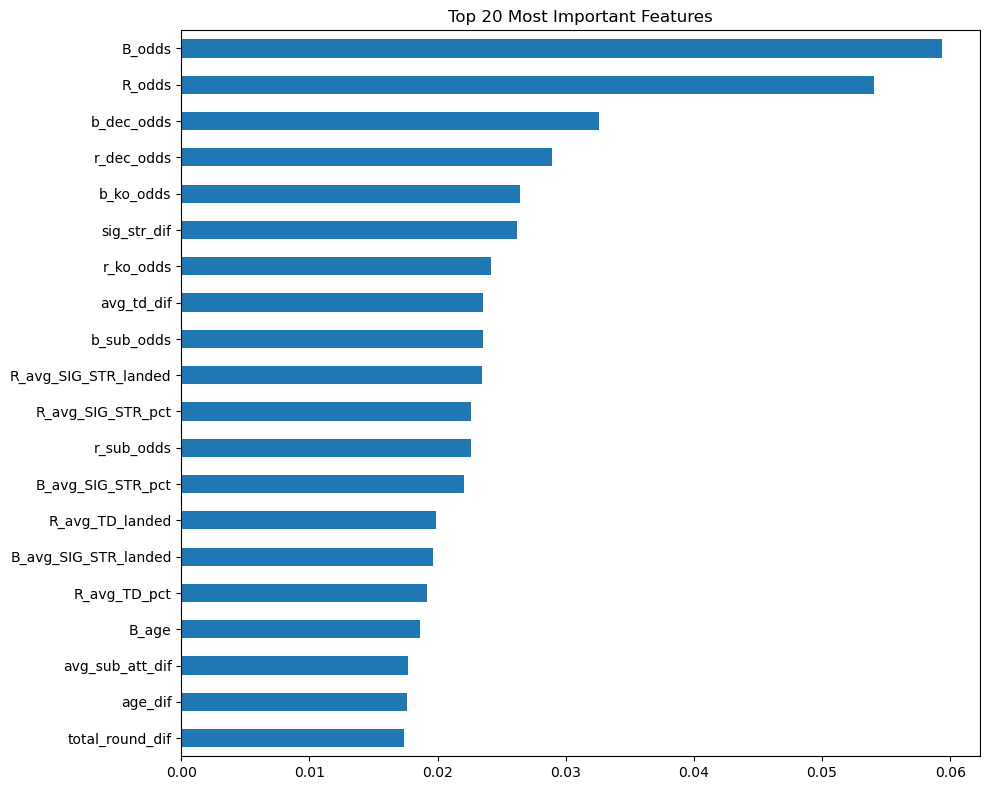

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
top20.plot(kind='barh')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
odds_cols = [col for col in X.columns if 'odds' in col.lower() or '_ev' in col.lower()]
print(odds_cols)

['R_odds', 'B_odds', 'r_dec_odds', 'b_dec_odds', 'r_sub_odds', 'b_sub_odds', 'r_ko_odds', 'b_ko_odds']


In [15]:
# Drop odds columns
X_no_odds = X.drop(columns=odds_cols)

# Retrain
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_odds, y, test_size=0.2, random_state=42
)

rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X_train2, y_train2)

# Evaluate
y_pred2 = rf2.predict(X_test2)
accuracy2 = accuracy_score(y_test2, y_pred2)
print(f"Accuracy WITHOUT odds: {accuracy2:.2%}")
print("\nClassification Report:")
print(classification_report(y_test2, y_pred2, target_names=['Blue wins', 'Red wins']))

Accuracy WITHOUT odds: 62.13%

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.58      0.39      0.47       607
    Red wins       0.64      0.79      0.71       827

    accuracy                           0.62      1434
   macro avg       0.61      0.59      0.59      1434
weighted avg       0.61      0.62      0.60      1434



In [16]:
# Train with class balancing
rf3 = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    class_weight='balanced'  # this fixes the imbalance
)
rf3.fit(X_train2, y_train2)

y_pred3 = rf3.predict(X_test2)
accuracy3 = accuracy_score(y_test2, y_pred3)
print(f"Accuracy balanced: {accuracy3:.2%}")
print("\nClassification Report:")
print(classification_report(y_test2, y_pred3, target_names=['Blue wins', 'Red wins']))

Accuracy balanced: 59.90%

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.54      0.35      0.42       607
    Red wins       0.62      0.78      0.69       827

    accuracy                           0.60      1434
   macro avg       0.58      0.57      0.56      1434
weighted avg       0.59      0.60      0.58      1434



In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=607/827  # handles class imbalance
)

xgb.fit(X_train2, y_train2)

y_pred_xgb = xgb.predict(X_test2)
accuracy_xgb = accuracy_score(y_test2, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.2%}")
print("\nClassification Report:")
print(classification_report(y_test2, y_pred_xgb, target_names=['Blue wins', 'Red wins']))

XGBoost Accuracy: 59.69%

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.52      0.57      0.54       607
    Red wins       0.66      0.62      0.64       827

    accuracy                           0.60      1434
   macro avg       0.59      0.59      0.59      1434
weighted avg       0.60      0.60      0.60      1434



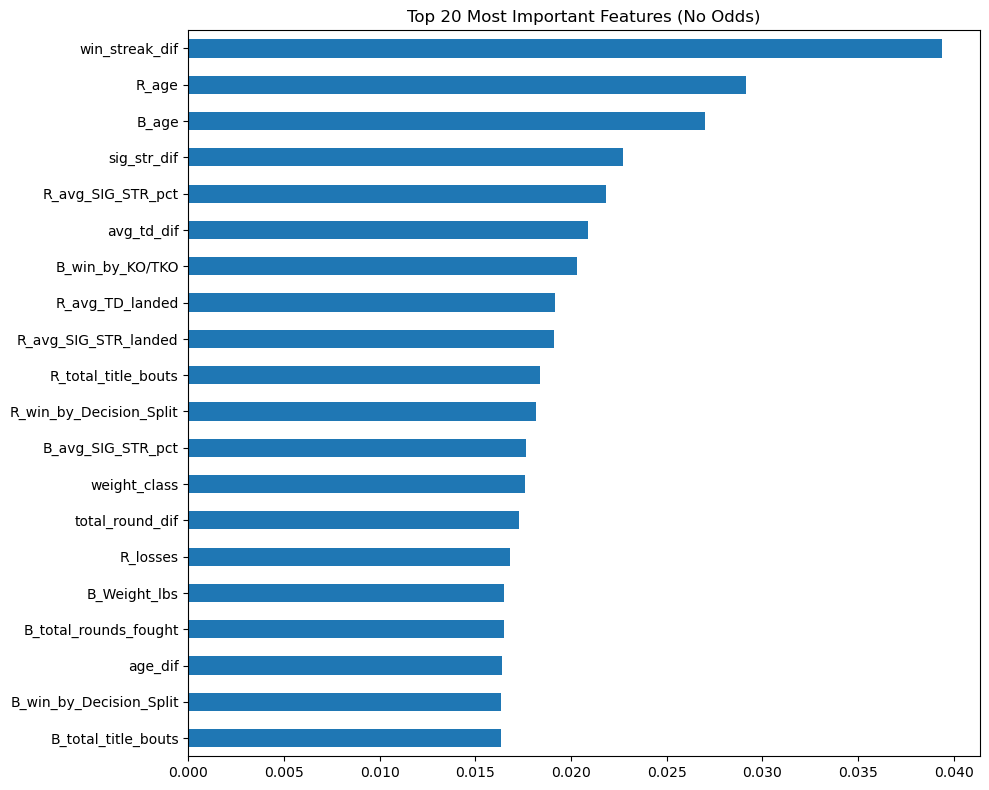

In [18]:
importances2 = pd.Series(xgb.feature_importances_, index=X_no_odds.columns)
top20_2 = importances2.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
top20_2.plot(kind='barh')
plt.title('Top 20 Most Important Features (No Odds)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
import joblib
import os

os.makedirs('./model', exist_ok=True)

# Save our best model (rf2 - random forest without odds)
joblib.dump(rf2, './model/ufc_model.pkl')

# Save the feature columns so the website knows what to send
joblib.dump(X_no_odds.columns.tolist(), './model/feature_columns.pkl')

print("Model saved!")
print(f"Features: {len(X_no_odds.columns)}")

Model saved!
Features: 72


In [20]:
# Finish rate already exists but let's make it smarter
# Weight recent finishes more heavily using wins ratio

# Upset potential — how likely is Blue to finish
df['B_upset_potential'] = (
    df['B_win_by_KO/TKO'] + df['B_win_by_Submission']
) / (df['B_wins'] + 1)

# Red's vulnerability to being finished
# (more losses = more times they've been finished potentially)
df['R_finish_vulnerability'] = df['R_losses'] / (df['R_total_rounds_fought'] + 1)

# Dagestan score — high TD + high TD pct + sub attempts = wrestler archetype
df['R_wrestling_score'] = (
    df['R_avg_TD_landed'] * df['R_avg_TD_pct'] + df['R_avg_SUB_ATT']
)
df['B_wrestling_score'] = (
    df['B_avg_TD_landed'] * df['B_avg_TD_pct'] + df['B_avg_SUB_ATT']
)
df['wrestling_score_dif'] = df['R_wrestling_score'] - df['B_wrestling_score']

# Finish streak proxy — ratio of finishes to decisions
df['R_finish_ratio'] = (
    df['R_win_by_KO/TKO'] + df['R_win_by_Submission']
) / (df['R_wins'] + 1)
df['B_finish_ratio'] = (
    df['B_win_by_KO/TKO'] + df['B_win_by_Submission']
) / (df['B_wins'] + 1)
df['finish_ratio_dif'] = df['R_finish_ratio'] - df['B_finish_ratio']

# Upset index — Blue finish potential vs Red being a decision fighter
df['upset_index'] = df['B_finish_ratio'] - df['R_finish_ratio']

print("New features added!")
print(df[['B_upset_potential', 'wrestling_score_dif', 'finish_ratio_dif', 'upset_index']].describe())

New features added!
       B_upset_potential  wrestling_score_dif  finish_ratio_dif  upset_index
count        7169.000000          7169.000000       7169.000000  7169.000000
mean            0.288409             0.093723          0.068574    -0.068574
std             0.272970             1.533502          0.318919     0.318919
min             0.000000            -9.453600         -0.888889    -1.000000
25%             0.000000            -0.630000         -0.113636    -0.300000
50%             0.312500             0.067100          0.000000     0.000000
75%             0.500000             0.785767          0.300000     0.113636
max             0.923077            28.590000          1.000000     0.888889


In [21]:
# Reload original df since we've been modifying it
df_raw = pd.read_csv('./data/ufc-master.csv')

# Drop draws and no contests
df_raw = df_raw[df_raw['Winner'].isin(['Red', 'Blue'])]

# Make sure date is parsed correctly
df_raw['date'] = pd.to_datetime(df_raw['date'])

# Peek at fighter history - pick one fighter to verify
fighter = 'Conor McGregor'
red = df_raw[df_raw['R_fighter'] == fighter][['date', 'R_fighter', 'B_fighter', 'Winner', 'R_avg_SIG_STR_landed']]
blue = df_raw[df_raw['B_fighter'] == fighter][['date', 'R_fighter', 'B_fighter', 'Winner', 'B_avg_SIG_STR_landed']]
print(red)
print(blue)

           date       R_fighter       B_fighter Winner  R_avg_SIG_STR_landed
3093 2020-01-18  Conor McGregor  Donald Cerrone    Red                   NaN
4918 2016-03-05  Conor McGregor       Nate Diaz   Blue               30.8571
5447 2015-01-18  Conor McGregor    Dennis Siver    Red               25.2500
5684 2014-07-19  Conor McGregor   Diego Brandao    Red               37.0000
6126 2013-08-17  Conor McGregor    Max Holloway    Red               21.0000
           date            R_fighter       B_fighter Winner  \
2394 2021-07-10       Dustin Poirier  Conor McGregor    Red   
2619 2021-01-23       Dustin Poirier  Conor McGregor    Red   
3733 2018-10-06  Khabib Nurmagomedov  Conor McGregor    Red   
4617 2016-11-12        Eddie Alvarez  Conor McGregor   Blue   
4717 2016-08-20            Nate Diaz  Conor McGregor   Blue   
5017 2015-12-12            Jose Aldo  Conor McGregor   Blue   
5226 2015-07-11          Chad Mendes  Conor McGregor   Blue   
5593 2014-09-27       Dustin Poiri

In [22]:
# Build a unified fight history from both corners
# Normalize so every row is from one fighter's perspective

red_fights = df_raw[['date', 'R_fighter', 'Winner',
                      'R_avg_SIG_STR_landed', 'R_avg_SIG_STR_pct',
                      'R_avg_TD_landed', 'R_avg_TD_pct', 'R_avg_SUB_ATT']].copy()
red_fights.columns = ['date', 'fighter', 'Winner',
                      'avg_SIG_STR_landed', 'avg_SIG_STR_pct',
                      'avg_TD_landed', 'avg_TD_pct', 'avg_SUB_ATT']
red_fights['won'] = (red_fights['Winner'] == 'Red').astype(int)
red_fights['corner'] = 'Red'

blue_fights = df_raw[['date', 'B_fighter', 'Winner',
                       'B_avg_SIG_STR_landed', 'B_avg_SIG_STR_pct',
                       'B_avg_TD_landed', 'B_avg_TD_pct', 'B_avg_SUB_ATT']].copy()
blue_fights.columns = ['date', 'fighter', 'Winner',
                       'avg_SIG_STR_landed', 'avg_SIG_STR_pct',
                       'avg_TD_landed', 'avg_TD_pct', 'avg_SUB_ATT']
blue_fights['won'] = (blue_fights['Winner'] == 'Blue').astype(int)
blue_fights['corner'] = 'Blue'

# Combine and sort by fighter and date
fighter_history = pd.concat([red_fights, blue_fights], ignore_index=True)
fighter_history = fighter_history.sort_values(['fighter', 'date']).reset_index(drop=True)

# Verify with McGregor
print(fighter_history[fighter_history['fighter'] == 'Conor McGregor'][['date', 'fighter', 'won', 'avg_SIG_STR_landed']])

           date         fighter  won  avg_SIG_STR_landed
2913 2013-04-06  Conor McGregor    1                 NaN
2914 2013-08-17  Conor McGregor    1             21.0000
2915 2014-07-19  Conor McGregor    1             37.0000
2916 2014-09-27  Conor McGregor    1             30.6667
2917 2015-01-18  Conor McGregor    1             25.2500
2918 2015-07-11  Conor McGregor    1             33.0000
2919 2015-12-12  Conor McGregor    1             35.1667
2920 2016-03-05  Conor McGregor    0             30.8571
2921 2016-08-20  Conor McGregor    1             34.6250
2922 2016-11-12  Conor McGregor    1             49.0000
2923 2018-10-06  Conor McGregor    0             47.3000
2924 2020-01-18  Conor McGregor    1                 NaN
2925 2021-01-23  Conor McGregor    0              5.4300
2926 2021-07-10  Conor McGregor    0              5.3200


In [23]:
# Calculate rolling last 3 fights stats for each fighter
stats_cols = ['avg_SIG_STR_landed', 'avg_SIG_STR_pct', 
              'avg_TD_landed', 'avg_TD_pct', 'avg_SUB_ATT', 'won']

# Shift by 1 so we only use PAST fights, not the current one
# Then take rolling average of last 3
recent_stats = fighter_history.groupby('fighter')[stats_cols].apply(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).reset_index(level=0, drop=True)

# Rename columns
recent_stats.columns = [f'recent_{col}' for col in stats_cols]

# Add back to fighter history
fighter_history = pd.concat([fighter_history, recent_stats], axis=1)

# Verify McGregor - recent_won should show his last 3 fight win rate
print(fighter_history[fighter_history['fighter'] == 'Conor McGregor']
      [['date', 'won', 'recent_won', 'recent_avg_SIG_STR_landed']])

           date  won  recent_won  recent_avg_SIG_STR_landed
2913 2013-04-06    1         NaN                        NaN
2914 2013-08-17    1    1.000000                        NaN
2915 2014-07-19    1    1.000000                  21.000000
2916 2014-09-27    1    1.000000                  29.000000
2917 2015-01-18    1    1.000000                  29.555567
2918 2015-07-11    1    1.000000                  30.972233
2919 2015-12-12    1    1.000000                  29.638900
2920 2016-03-05    0    1.000000                  31.138900
2921 2016-08-20    1    0.666667                  33.007933
2922 2016-11-12    1    0.666667                  33.549600
2923 2018-10-06    0    0.666667                  38.160700
2924 2020-01-18    1    0.666667                  43.641667
2925 2021-01-23    0    0.666667                  48.150000
2926 2021-07-10    0    0.333333                  26.365000


In [24]:
# Now merge recent stats back into main dataframe for both Red and Blue corners
# For Red fighter
red_recent = fighter_history[fighter_history['corner'] == 'Red'][
    ['date', 'fighter', 'recent_won', 'recent_avg_SIG_STR_landed',
     'recent_avg_SIG_STR_pct', 'recent_avg_TD_landed', 
     'recent_avg_TD_pct', 'recent_avg_SUB_ATT']
].copy()
red_recent.columns = ['date', 'R_fighter'] + [f'R_{col}' for col in 
    ['recent_won', 'recent_avg_SIG_STR_landed', 'recent_avg_SIG_STR_pct',
     'recent_avg_TD_landed', 'recent_avg_TD_pct', 'recent_avg_SUB_ATT']]

# For Blue fighter
blue_recent = fighter_history[fighter_history['corner'] == 'Blue'][
    ['date', 'fighter', 'recent_won', 'recent_avg_SIG_STR_landed',
     'recent_avg_SIG_STR_pct', 'recent_avg_TD_landed',
     'recent_avg_TD_pct', 'recent_avg_SUB_ATT']
].copy()
blue_recent.columns = ['date', 'B_fighter'] + [f'B_{col}' for col in 
    ['recent_won', 'recent_avg_SIG_STR_landed', 'recent_avg_SIG_STR_pct',
     'recent_avg_TD_landed', 'recent_avg_TD_pct', 'recent_avg_SUB_ATT']]

# Merge into raw dataframe
df_enhanced = df_raw.merge(red_recent, on=['date', 'R_fighter'], how='left')
df_enhanced = df_enhanced.merge(blue_recent, on=['date', 'B_fighter'], how='left')

# Add difference columns
df_enhanced['recent_won_dif'] = df_enhanced['R_recent_won'] - df_enhanced['B_recent_won']
df_enhanced['recent_sig_str_dif'] = df_enhanced['R_recent_avg_SIG_STR_landed'] - df_enhanced['B_recent_avg_SIG_STR_landed']
df_enhanced['recent_td_dif'] = df_enhanced['R_recent_avg_TD_landed'] - df_enhanced['B_recent_avg_TD_landed']

print(f"Shape: {df_enhanced.shape}")
print(f"\nNew columns added:")
new_cols = [c for c in df_enhanced.columns if 'recent' in c]
print(new_cols)

Shape: (7169, 133)

New columns added:
['R_recent_won', 'R_recent_avg_SIG_STR_landed', 'R_recent_avg_SIG_STR_pct', 'R_recent_avg_TD_landed', 'R_recent_avg_TD_pct', 'R_recent_avg_SUB_ATT', 'B_recent_won', 'B_recent_avg_SIG_STR_landed', 'B_recent_avg_SIG_STR_pct', 'B_recent_avg_TD_landed', 'B_recent_avg_TD_pct', 'B_recent_avg_SUB_ATT', 'recent_won_dif', 'recent_sig_str_dif', 'recent_td_dif']


In [25]:
# Target variable
df_enhanced['target'] = (df_enhanced['Winner'] == 'Red').astype(int)

# Drop columns
drop_cols_final = [
    'R_fighter', 'B_fighter',
    'date', 'location', 'country',
    'Winner',
    'finish', 'finish_round', 'finish_round_time', 'total_fight_time_secs',
    'R_ev', 'B_ev',
]

# Drop high missing columns
missing_pct = df_enhanced.isnull().sum() / len(df_enhanced)
cols_to_drop = missing_pct[missing_pct > 0.5].index.tolist()
df_enhanced = df_enhanced.drop(columns=cols_to_drop + drop_cols_final, errors='ignore')

# Add engineered features
df_enhanced['R_finish_rate'] = (df_enhanced['R_win_by_KO/TKO'] + df_enhanced['R_win_by_Submission']) / (df_enhanced['R_wins'] + 1)
df_enhanced['B_finish_rate'] = (df_enhanced['B_win_by_KO/TKO'] + df_enhanced['B_win_by_Submission']) / (df_enhanced['B_wins'] + 1)
df_enhanced['finish_rate_dif'] = df_enhanced['R_finish_rate'] - df_enhanced['B_finish_rate']
df_enhanced['B_upset_potential'] = (df_enhanced['B_win_by_KO/TKO'] + df_enhanced['B_win_by_Submission']) / (df_enhanced['B_wins'] + 1)
df_enhanced['R_finish_vulnerability'] = df_enhanced['R_losses'] / (df_enhanced['R_total_rounds_fought'] + 1)
df_enhanced['R_wrestling_score'] = (df_enhanced['R_avg_TD_landed'] * df_enhanced['R_avg_TD_pct'] + df_enhanced['R_avg_SUB_ATT'])
df_enhanced['B_wrestling_score'] = (df_enhanced['B_avg_TD_landed'] * df_enhanced['B_avg_TD_pct'] + df_enhanced['B_avg_SUB_ATT'])
df_enhanced['wrestling_score_dif'] = df_enhanced['R_wrestling_score'] - df_enhanced['B_wrestling_score']
df_enhanced['R_finish_ratio'] = (df_enhanced['R_win_by_KO/TKO'] + df_enhanced['R_win_by_Submission']) / (df_enhanced['R_wins'] + 1)
df_enhanced['B_finish_ratio'] = (df_enhanced['B_win_by_KO/TKO'] + df_enhanced['B_win_by_Submission']) / (df_enhanced['B_wins'] + 1)
df_enhanced['finish_ratio_dif'] = df_enhanced['R_finish_ratio'] - df_enhanced['B_finish_ratio']
df_enhanced['upset_index'] = df_enhanced['B_finish_ratio'] - df_enhanced['R_finish_ratio']

# Encode categoricals
for col in ['R_Stance', 'B_Stance', 'weight_class', 'gender', 'better_rank']:
    df_enhanced[col] = df_enhanced[col].fillna('Unknown')
    df_enhanced[col] = le.fit_transform(df_enhanced[col])

# Fill missing
df_enhanced = df_enhanced.fillna(df_enhanced.median(numeric_only=True))

print(f"Missing values: {df_enhanced.isnull().sum().sum()}")
print(f"Final shape: {df_enhanced.shape}")

Missing values: 0
Final shape: (7169, 105)


In [26]:
# Split features and target
X_final = df_enhanced.drop(columns=['target'] + [c for c in odds_cols if c in df_enhanced.columns])
y_final = df_enhanced['target']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

# Random Forest
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_train_f, y_train_f)

y_pred_f = rf_final.predict(X_test_f)
accuracy_f = accuracy_score(y_test_f, y_pred_f)
print(f"Final Model Accuracy: {accuracy_f:.2%}")
print("\nClassification Report:")
print(classification_report(y_test_f, y_pred_f, target_names=['Blue wins', 'Red wins']))

Final Model Accuracy: 60.46%

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.55      0.38      0.45       607
    Red wins       0.63      0.77      0.69       827

    accuracy                           0.60      1434
   macro avg       0.59      0.58      0.57      1434
weighted avg       0.59      0.60      0.59      1434



In [27]:
# How many recent stat rows are actually populated vs filled with median?
recent_cols = [c for c in X_final.columns if 'recent' in c]
print("Recent stats coverage:")
for col in recent_cols:
    filled = df_enhanced[col].notna().sum()
    print(f"{col}: {filled}/{len(df_enhanced)} ({filled/len(df_enhanced):.1%})")

Recent stats coverage:
R_recent_won: 7169/7169 (100.0%)
R_recent_avg_SIG_STR_landed: 7169/7169 (100.0%)
R_recent_avg_SIG_STR_pct: 7169/7169 (100.0%)
R_recent_avg_TD_landed: 7169/7169 (100.0%)
R_recent_avg_TD_pct: 7169/7169 (100.0%)
R_recent_avg_SUB_ATT: 7169/7169 (100.0%)
B_recent_won: 7169/7169 (100.0%)
B_recent_avg_SIG_STR_landed: 7169/7169 (100.0%)
B_recent_avg_SIG_STR_pct: 7169/7169 (100.0%)
B_recent_avg_TD_landed: 7169/7169 (100.0%)
B_recent_avg_TD_pct: 7169/7169 (100.0%)
B_recent_avg_SUB_ATT: 7169/7169 (100.0%)
recent_won_dif: 7169/7169 (100.0%)
recent_sig_str_dif: 7169/7169 (100.0%)
recent_td_dif: 7169/7169 (100.0%)


In [28]:
# Check correlation between our engineered features
eng_cols = ['R_finish_rate', 'R_finish_ratio', 'finish_rate_dif', 
            'finish_ratio_dif', 'upset_index', 'B_upset_potential']
print(df_enhanced[eng_cols].corr())

                   R_finish_rate  R_finish_ratio  finish_rate_dif  \
R_finish_rate           1.000000        1.000000         0.573235   
R_finish_ratio          1.000000        1.000000         0.573235   
finish_rate_dif         0.573235        0.573235         1.000000   
finish_ratio_dif        0.573235        0.573235         1.000000   
upset_index            -0.573235       -0.573235        -1.000000   
B_upset_potential       0.289033        0.289033        -0.618734   

                   finish_ratio_dif  upset_index  B_upset_potential  
R_finish_rate              0.573235    -0.573235           0.289033  
R_finish_ratio             0.573235    -0.573235           0.289033  
finish_rate_dif            1.000000    -1.000000          -0.618734  
finish_ratio_dif           1.000000    -1.000000          -0.618734  
upset_index               -1.000000     1.000000           0.618734  
B_upset_potential         -0.618734     0.618734           1.000000  


In [30]:
# Drop the duplicate engineered features
cols_to_remove = [
    'R_finish_ratio',      # exact duplicate of R_finish_rate
    'B_finish_ratio',      # exact duplicate of B_finish_rate
    'finish_ratio_dif',    # exact duplicate of finish_rate_dif
    'upset_index',         # exact inverse of finish_rate_dif, redundant
]

X_clean = X_final.drop(columns=cols_to_remove, errors='ignore')

# Retrain
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_final, test_size=0.2, random_state=42
)

rf_clean = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clean.fit(X_train_c, y_train_c)

y_pred_c = rf_clean.predict(X_test_c)
accuracy_c = accuracy_score(y_test_c, y_pred_c)
print(f"Cleaned Model Accuracy: {accuracy_c:.2%}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=['Blue wins', 'Red wins']))

Cleaned Model Accuracy: 61.16%

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.56      0.38      0.45       607
    Red wins       0.63      0.78      0.70       827

    accuracy                           0.61      1434
   macro avg       0.60      0.58      0.58      1434
weighted avg       0.60      0.61      0.60      1434



In [31]:
from xgboost import XGBClassifier

xgb_final = XGBClassifier(
    n_estimators=300,        # more trees
    learning_rate=0.05,      # slower learning = more careful
    max_depth=3,             # shallower trees = less overfitting
    subsample=0.8,           # use 80% of data per tree
    colsample_bytree=0.8,    # use 80% of features per tree
    min_child_weight=5,      # requires more samples per leaf
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=607/827  # balance classes
)

xgb_final.fit(
    X_train_c, y_train_c,
    eval_set=[(X_test_c, y_test_c)],
    verbose=50  # print every 50 rounds
)

y_pred_xgb2 = xgb_final.predict(X_test_c)
accuracy_xgb2 = accuracy_score(y_test_c, y_pred_xgb2)
print(f"\nTuned XGBoost Accuracy: {accuracy_xgb2:.2%}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_xgb2, target_names=['Blue wins', 'Red wins']))

[0]	validation_0-logloss:0.69078
[50]	validation_0-logloss:0.66118
[100]	validation_0-logloss:0.65537
[150]	validation_0-logloss:0.65501
[200]	validation_0-logloss:0.65510
[250]	validation_0-logloss:0.65604
[299]	validation_0-logloss:0.65621

Tuned XGBoost Accuracy: 61.09%

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.54      0.59      0.56       607
    Red wins       0.68      0.62      0.65       827

    accuracy                           0.61      1434
   macro avg       0.61      0.61      0.61      1434
weighted avg       0.62      0.61      0.61      1434



In [32]:
import joblib
import os

os.makedirs('./model', exist_ok=True)

# Save your chosen model — swap xgb_final for rf2 if you prefer
joblib.dump(xgb_final, './model/ufc_model.pkl')
joblib.dump(X_clean.columns.tolist(), './model/feature_columns.pkl')

print("Model saved!")
print(f"Features: {len(X_clean.columns)}")

Model saved!
Features: 92


In [33]:
df_enhanced['date'] = pd.to_datetime(df_raw['date'])
print(df_enhanced['date'].min(), 'to', df_enhanced['date'].max())

# Check fight counts by year cutoff
for year in [2013, 2014, 2015, 2016]:
    count = (df_enhanced['date'] >= f'{year}-01-01').sum()
    print(f"Fights from {year} onwards: {count}")

2010-03-21 00:00:00 to 2026-03-28 00:00:00
Fights from 2013 onwards: 6331
Fights from 2014 onwards: 5955
Fights from 2015 onwards: 5461
Fights from 2016 onwards: 4997


/var/folders/v5/t211ltbs1h31hmkx96n0588w0000gn/T/ipykernel_98062/148264146.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_enhanced['date'] = pd.to_datetime(df_raw['date'])


In [34]:
# Filter to 2015 onwards
mask = df_enhanced['date'] >= '2015-01-01'
df_modern = df_enhanced[mask].copy()

print(f"Modern era fights: {len(df_modern)}")
print(f"Red win rate: {df_modern['target'].mean():.2%}")

# Retrain with modern data only
X_modern = df_modern.drop(columns=['target', 'date'] + 
                          [c for c in odds_cols if c in df_modern.columns], 
                          errors='ignore')
y_modern = df_modern['target']

# Remove duplicate engineered features
X_modern = X_modern.drop(columns=cols_to_remove, errors='ignore')

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_modern, y_modern, test_size=0.2, random_state=42
)

xgb_modern = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=len(y_modern[y_modern==0])/len(y_modern[y_modern==1])
)

xgb_modern.fit(
    X_train_m, y_train_m,
    eval_set=[(X_test_m, y_test_m)],
    verbose=50
)

y_pred_m = xgb_modern.predict(X_test_m)
accuracy_m = accuracy_score(y_test_m, y_pred_m)
print(f"\nModern Era Model Accuracy: {accuracy_m:.2%}")
print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_m, target_names=['Blue wins', 'Red wins']))

Modern era fights: 5461
Red win rate: 56.99%
[0]	validation_0-logloss:0.69163
[50]	validation_0-logloss:0.66368
[100]	validation_0-logloss:0.66035
[150]	validation_0-logloss:0.65828
[200]	validation_0-logloss:0.66100
[250]	validation_0-logloss:0.66017
[299]	validation_0-logloss:0.66075

Modern Era Model Accuracy: 59.65%

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.52      0.57      0.55       466
    Red wins       0.66      0.61      0.64       627

    accuracy                           0.60      1093
   macro avg       0.59      0.59      0.59      1093
weighted avg       0.60      0.60      0.60      1093



In [35]:
xgb_modern2 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,  # stop if no improvement for 20 rounds
    scale_pos_weight=len(y_modern[y_modern==0])/len(y_modern[y_modern==1])
)

xgb_modern2.fit(
    X_train_m, y_train_m,
    eval_set=[(X_test_m, y_test_m)],
    verbose=25
)

y_pred_m2 = xgb_modern2.predict(X_test_m)
accuracy_m2 = accuracy_score(y_test_m, y_pred_m2)
print(f"\nEarly Stopping Model Accuracy: {accuracy_m2:.2%}")
print(f"Best iteration: {xgb_modern2.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_m2, target_names=['Blue wins', 'Red wins']))

[0]	validation_0-logloss:0.69163
[25]	validation_0-logloss:0.66918
[50]	validation_0-logloss:0.66368
[75]	validation_0-logloss:0.66218
[100]	validation_0-logloss:0.66035
[125]	validation_0-logloss:0.65886
[150]	validation_0-logloss:0.65828
[161]	validation_0-logloss:0.65828

Early Stopping Model Accuracy: 60.48%
Best iteration: 141

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.53      0.57      0.55       466
    Red wins       0.66      0.63      0.65       627

    accuracy                           0.60      1093
   macro avg       0.60      0.60      0.60      1093
weighted avg       0.61      0.60      0.61      1093



In [36]:
red_fighters = df_modern['R_fighter'].unique()
blue_fighters = df_modern['B_fighter'].unique()
all_fighters = set(red_fighters) | set(blue_fighters)
print(f"Unique fighters in modern dataset: {len(all_fighters)}")

KeyError: 'R_fighter'

In [37]:
# Go back to df_raw filtered to modern era to get fighter names
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_modern_raw = df_raw[df_raw['date'] >= '2015-01-01'].copy()

# Count fights per fighter across both corners
from collections import Counter

fight_counts = Counter()
for fighter in df_modern_raw['R_fighter']:
    fight_counts[fighter] += 1
for fighter in df_modern_raw['B_fighter']:
    fight_counts[fighter] += 1

# Find fighters with more than 1 fight
experienced_fighters = {f for f, count in fight_counts.items() if count > 1}
print(f"Total unique fighters: {len(fight_counts)}")
print(f"Fighters with more than 1 fight: {len(experienced_fighters)}")

# Filter to only fights where BOTH fighters have more than 1 fight
mask = (df_modern_raw['R_fighter'].isin(experienced_fighters) & 
        df_modern_raw['B_fighter'].isin(experienced_fighters))
df_modern_filtered = df_modern_raw[mask].copy()
print(f"\nFights before filter: {len(df_modern_raw)}")
print(f"Fights after filter: {len(df_modern_filtered)}")

Total unique fighters: 1847
Fighters with more than 1 fight: 1586

Fights before filter: 5461
Fights after filter: 5208


In [44]:
kaggle.api.dataset_download_files(
    'jossilva3110/ufc-dataset-1994-2026',
    path='./data/gold',
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/jossilva3110/ufc-dataset-1994-2026


In [45]:
import os
print(os.listdir('./data/gold'))

['ufc_gold_dataset_final.csv', 'ufc_fighters_final.csv']


In [46]:
df_gold = pd.read_csv('./data/gold/ufc_gold_dataset_final.csv')
print(f"Shape: {df_gold.shape}")
print(f"\nColumns:")
for col in df_gold.columns:
    print(col)

Shape: (8551, 37)

Columns:
Fight_URL
Fighter_1
Fighter_2
Winner
Weight_Class
Method
End_Round
End_Time
Total_Fight_Time_Sec
Time_Format
F1_KD
F2_KD
F1_Sig_Landed
F1_Sig_Att
F2_Sig_Landed
F2_Sig_Att
F1_TD_Landed
F2_TD_Landed
F1_TD_Att
F2_TD_Att
F1_Sub_Att
F2_Sub_Att
F1_Ctrl_Sec
F2_Ctrl_Sec
F1_Head
F2_Head
F1_Body
F2_Body
F1_Leg
F2_Leg
F1_Distance
F2_Distance
F1_Clinch
F2_Clinch
F1_Ground
F2_Ground
Event_Date


In [48]:
# Rename columns we want from gold dataset
df_gold_modern = df_gold[df_gold['Event_Date'] >= '2015-01-01'].copy()
df_gold_modern['Event_Date'] = pd.to_datetime(df_gold_modern['Event_Date'])

# Rename only the new columns we want
rename_map = {
    'Fighter_1': 'R_fighter',
    'Fighter_2': 'B_fighter',
    'Event_Date': 'date',
    'F1_KD': 'R_KD',
    'F2_KD': 'B_KD',
    'F1_Head': 'R_Head',
    'F2_Head': 'B_Head',
    'F1_Body': 'R_Body',
    'F2_Body': 'B_Body',
    'F1_Leg': 'R_Leg',
    'F2_Leg': 'B_Leg',
    'F1_Distance': 'R_Distance',
    'F2_Distance': 'B_Distance',
    'F1_Clinch': 'R_Clinch',
    'F2_Clinch': 'B_Clinch',
    'F1_Ground': 'R_Ground',
    'F2_Ground': 'B_Ground',
    'F1_Ctrl_Sec': 'R_Ctrl_Sec',
    'F2_Ctrl_Sec': 'B_Ctrl_Sec',
}

df_gold_modern = df_gold_modern.rename(columns=rename_map)

# Keep only the columns we need for merging
new_cols = ['date', 'R_fighter', 'B_fighter',
            'R_KD', 'B_KD',
            'R_Head', 'B_Head',
            'R_Body', 'B_Body',
            'R_Leg', 'B_Leg',
            'R_Distance', 'B_Distance',
            'R_Clinch', 'B_Clinch',
            'R_Ground', 'B_Ground',
            'R_Ctrl_Sec', 'B_Ctrl_Sec']

df_gold_modern = df_gold_modern[new_cols]

# Merge with our main dataset
df_merged = df_modern_filtered.merge(df_gold_modern, 
                                      on=['date', 'R_fighter', 'B_fighter'], 
                                      how='left')

print(f"Shape before merge: {df_modern_filtered.shape}")
print(f"Shape after merge: {df_merged.shape}")
print(f"\nNew columns coverage:")
for col in ['R_KD', 'R_Head', 'R_Ctrl_Sec']:
    filled = df_merged[col].notna().sum()
    print(f"{col}: {filled}/{len(df_merged)} ({filled/len(df_merged):.1%})")

Shape before merge: (5208, 118)
Shape after merge: (5208, 134)

New columns coverage:
R_KD: 4941/5208 (94.9%)
R_Head: 4941/5208 (94.9%)
R_Ctrl_Sec: 4941/5208 (94.9%)


In [49]:
# Add difference columns for new features
df_merged['KD_dif'] = df_merged['R_KD'] - df_merged['B_KD']
df_merged['Head_dif'] = df_merged['R_Head'] - df_merged['B_Head']
df_merged['Body_dif'] = df_merged['R_Body'] - df_merged['B_Body']
df_merged['Leg_dif'] = df_merged['R_Leg'] - df_merged['B_Leg']
df_merged['Distance_dif'] = df_merged['R_Distance'] - df_merged['B_Distance']
df_merged['Clinch_dif'] = df_merged['R_Clinch'] - df_merged['B_Clinch']
df_merged['Ground_dif'] = df_merged['R_Ground'] - df_merged['B_Ground']
df_merged['Ctrl_Sec_dif'] = df_merged['R_Ctrl_Sec'] - df_merged['B_Ctrl_Sec']

print("Difference columns added!")
print(df_merged[['KD_dif', 'Head_dif', 'Ctrl_Sec_dif']].describe())

Difference columns added!
            KD_dif     Head_dif  Ctrl_Sec_dif
count  4941.000000  4941.000000   4941.000000
mean      0.021858     2.075288     26.712204
std       0.740341    22.995766    245.214703
min      -6.000000  -134.000000  -1247.000000
25%       0.000000   -10.000000    -71.000000
50%       0.000000     1.000000      3.000000
75%       0.000000    14.000000    125.000000
max       5.000000   175.000000   1213.000000


In [50]:
# Set up features
drop_cols_final = [
    'R_fighter', 'B_fighter', 'date', 'location', 'country',
    'Winner', 'finish', 'finish_round', 'finish_round_time',
    'total_fight_time_secs', 'R_ev', 'B_ev',
    'R_finish_ratio', 'B_finish_ratio', 'finish_ratio_dif', 'upset_index'
]

df_merged['target'] = (df_merged['Winner'] == 'Red').astype(int)

# Drop high missing and unwanted columns
missing_pct = df_merged.isnull().sum() / len(df_merged)
high_missing = missing_pct[missing_pct > 0.5].index.tolist()

X_merged = df_merged.drop(columns=drop_cols_final + high_missing + ['target'], errors='ignore')
X_merged = X_merged.drop(columns=[c for c in odds_cols if c in X_merged.columns], errors='ignore')

# Encode categoricals
for col in ['R_Stance', 'B_Stance', 'weight_class', 'gender', 'better_rank']:
    if col in X_merged.columns:
        X_merged[col] = X_merged[col].fillna('Unknown')
        X_merged[col] = le.fit_transform(X_merged[col])

# Fill missing
X_merged = X_merged.fillna(X_merged.median(numeric_only=True))
y_merged = df_merged['target']

print(f"Missing values: {X_merged.isnull().sum().sum()}")
print(f"Final shape: {X_merged.shape}")

Missing values: 0
Final shape: (5208, 93)


In [51]:
# Check what got dropped
all_cols = set(df_merged.columns)
kept_cols = set(X_merged.columns)
dropped = all_cols - kept_cols - {'target'}
print(f"Dropped {len(dropped)} columns:")
for c in sorted(dropped):
    print(c)

Dropped 49 columns:
B_Bantamweight_rank
B_Featherweight_rank
B_Flyweight_rank
B_Heavyweight_rank
B_Light Heavyweight_rank
B_Lightweight_rank
B_Middleweight_rank
B_Pound-for-Pound_rank
B_Welterweight_rank
B_Women's Bantamweight_rank
B_Women's Featherweight_rank
B_Women's Flyweight_rank
B_Women's Strawweight_rank
B_ev
B_fighter
B_match_weightclass_rank
B_odds
R_Bantamweight_rank
R_Featherweight_rank
R_Flyweight_rank
R_Heavyweight_rank
R_Light Heavyweight_rank
R_Lightweight_rank
R_Middleweight_rank
R_Pound-for-Pound_rank
R_Welterweight_rank
R_Women's Bantamweight_rank
R_Women's Featherweight_rank
R_Women's Flyweight_rank
R_Women's Strawweight_rank
R_ev
R_fighter
R_match_weightclass_rank
R_odds
Winner
b_dec_odds
b_ko_odds
b_sub_odds
country
date
finish
finish_details
finish_round
finish_round_time
location
r_dec_odds
r_ko_odds
r_sub_odds
total_fight_time_secs


In [53]:
# Add back engineered features
X_merged['R_finish_rate'] = (df_merged['R_win_by_KO/TKO'] + df_merged['R_win_by_Submission']) / (df_merged['R_wins'] + 1)
X_merged['B_finish_rate'] = (df_merged['B_win_by_KO/TKO'] + df_merged['B_win_by_Submission']) / (df_merged['B_wins'] + 1)
X_merged['finish_rate_dif'] = X_merged['R_finish_rate'] - X_merged['B_finish_rate']
X_merged['B_upset_potential'] = X_merged['B_finish_rate']
X_merged['R_finish_vulnerability'] = df_merged['R_losses'] / (df_merged['R_total_rounds_fought'] + 1)
X_merged['R_wrestling_score'] = (df_merged['R_avg_TD_landed'] * df_merged['R_avg_TD_pct'] + df_merged['R_avg_SUB_ATT'])
X_merged['B_wrestling_score'] = (df_merged['B_avg_TD_landed'] * df_merged['B_avg_TD_pct'] + df_merged['B_avg_SUB_ATT'])
X_merged['wrestling_score_dif'] = X_merged['R_wrestling_score'] - X_merged['B_wrestling_score']

# Add recent fight stats from fighter_history
red_recent = fighter_history[fighter_history['corner'] == 'Red'][
    ['date', 'fighter', 'recent_won', 'recent_avg_SIG_STR_landed',
     'recent_avg_SIG_STR_pct', 'recent_avg_TD_landed',
     'recent_avg_TD_pct', 'recent_avg_SUB_ATT']
].copy()
red_recent.columns = ['date', 'R_fighter'] + [f'R_{col}' for col in
    ['recent_won', 'recent_avg_SIG_STR_landed', 'recent_avg_SIG_STR_pct',
     'recent_avg_TD_landed', 'recent_avg_TD_pct', 'recent_avg_SUB_ATT']]

blue_recent = fighter_history[fighter_history['corner'] == 'Blue'][
    ['date', 'fighter', 'recent_won', 'recent_avg_SIG_STR_landed',
     'recent_avg_SIG_STR_pct', 'recent_avg_TD_landed',
     'recent_avg_TD_pct', 'recent_avg_SUB_ATT']
].copy()
blue_recent.columns = ['date', 'B_fighter'] + [f'B_{col}' for col in
    ['recent_won', 'recent_avg_SIG_STR_landed', 'recent_avg_SIG_STR_pct',
     'recent_avg_TD_landed', 'recent_avg_TD_pct', 'recent_avg_SUB_ATT']]

# Merge recent stats
df_merged['date'] = pd.to_datetime(df_modern_filtered['date'].values)
df_merged['R_fighter'] = df_modern_filtered['R_fighter'].values
df_merged['B_fighter'] = df_modern_filtered['B_fighter'].values

df_merged = df_merged.merge(red_recent, on=['date', 'R_fighter'], how='left')
df_merged = df_merged.merge(blue_recent, on=['date', 'B_fighter'], how='left')

# Add recent diff columns
df_merged['recent_won_dif'] = df_merged['R_recent_won'] - df_merged['B_recent_won']
df_merged['recent_sig_str_dif'] = df_merged['R_recent_avg_SIG_STR_landed'] - df_merged['B_recent_avg_SIG_STR_landed']
df_merged['recent_td_dif'] = df_merged['R_recent_avg_TD_landed'] - df_merged['B_recent_avg_TD_landed']

# Add to X_merged and fill missing
recent_cols = ['R_recent_won', 'R_recent_avg_SIG_STR_landed', 'R_recent_avg_SIG_STR_pct',
               'R_recent_avg_TD_landed', 'R_recent_avg_TD_pct', 'R_recent_avg_SUB_ATT',
               'B_recent_won', 'B_recent_avg_SIG_STR_landed', 'B_recent_avg_SIG_STR_pct',
               'B_recent_avg_TD_landed', 'B_recent_avg_TD_pct', 'B_recent_avg_SUB_ATT',
               'recent_won_dif', 'recent_sig_str_dif', 'recent_td_dif']

for col in recent_cols:
    X_merged[col] = df_merged[col].fillna(df_merged[col].median())

X_merged = X_merged.fillna(X_merged.median(numeric_only=True))

print(f"Missing values: {X_merged.isnull().sum().sum()}")
print(f"Final shape: {X_merged.shape}")

Missing values: 0
Final shape: (5208, 116)


/var/folders/v5/t211ltbs1h31hmkx96n0588w0000gn/T/ipykernel_98062/360205122.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_merged['wrestling_score_dif'] = X_merged['R_wrestling_score'] - X_merged['B_wrestling_score']
/var/folders/v5/t211ltbs1h31hmkx96n0588w0000gn/T/ipykernel_98062/360205122.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_merged[col] = df_merged[col].fillna(df_merged[col].median())
/var/folders/v5/t211ltbs1h31hmkx96n0588w0000gn/T/ipykernel_98062/360205122.py:51: PerformanceWarning: DataFrame is highl

In [54]:
# Defragment the dataframe
X_merged = X_merged.copy()
print("Defragmented!")

Defragmented!


In [55]:
y_merged = df_merged['target']

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_merged, y_merged, test_size=0.2, random_state=42
)

xgb_best = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,
    scale_pos_weight=len(y_merged[y_merged==0])/len(y_merged[y_merged==1])
)

xgb_best.fit(
    X_train_final, y_train_final,
    eval_set=[(X_test_final, y_test_final)],
    verbose=25
)

y_pred_best = xgb_best.predict(X_test_final)
accuracy_best = accuracy_score(y_test_final, y_pred_best)
print(f"\nFinal Model Accuracy: {accuracy_best:.2%}")
print(f"Best iteration: {xgb_best.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_best, target_names=['Blue wins', 'Red wins']))

[0]	validation_0-logloss:0.67172
[25]	validation_0-logloss:0.44616
[50]	validation_0-logloss:0.39075
[75]	validation_0-logloss:0.36813
[100]	validation_0-logloss:0.35727
[125]	validation_0-logloss:0.35078
[150]	validation_0-logloss:0.34701
[175]	validation_0-logloss:0.34524
[200]	validation_0-logloss:0.34404
[222]	validation_0-logloss:0.34420

Final Model Accuracy: 84.17%
Best iteration: 202

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.82      0.82      0.82       458
    Red wins       0.86      0.86      0.86       584

    accuracy                           0.84      1042
   macro avg       0.84      0.84      0.84      1042
weighted avg       0.84      0.84      0.84      1042



In [56]:
# Check — these are the leaky columns
leaky_cols = ['R_KD', 'B_KD', 'R_Head', 'B_Head', 'R_Body', 'B_Body', 
              'R_Leg', 'B_Leg', 'R_Distance', 'B_Distance', 'R_Clinch', 
              'B_Clinch', 'R_Ground', 'B_Ground', 'R_Ctrl_Sec', 'B_Ctrl_Sec',
              'KD_dif', 'Head_dif', 'Body_dif', 'Leg_dif', 'Distance_dif',
              'Clinch_dif', 'Ground_dif', 'Ctrl_Sec_dif']

X_no_leak = X_merged.drop(columns=leaky_cols)

# Retrain without leaky columns
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_no_leak, y_merged, test_size=0.2, random_state=42
)

xgb_noleak = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,
    scale_pos_weight=len(y_merged[y_merged==0])/len(y_merged[y_merged==1])
)

xgb_noleak.fit(
    X_train_nl, y_train_nl,
    eval_set=[(X_test_nl, y_test_nl)],
    verbose=25
)

y_pred_nl = xgb_noleak.predict(X_test_nl)
accuracy_nl = accuracy_score(y_test_nl, y_pred_nl)
print(f"\nNo Leakage Model Accuracy: {accuracy_nl:.2%}")
print(f"Best iteration: {xgb_noleak.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_test_nl, y_pred_nl, target_names=['Blue wins', 'Red wins']))

[0]	validation_0-logloss:0.69051
[25]	validation_0-logloss:0.66520
[50]	validation_0-logloss:0.65643
[75]	validation_0-logloss:0.65313
[100]	validation_0-logloss:0.65042
[125]	validation_0-logloss:0.64895
[150]	validation_0-logloss:0.64969
[155]	validation_0-logloss:0.64969

No Leakage Model Accuracy: 61.90%
Best iteration: 135

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.56      0.59      0.58       458
    Red wins       0.67      0.64      0.65       584

    accuracy                           0.62      1042
   macro avg       0.61      0.62      0.61      1042
weighted avg       0.62      0.62      0.62      1042



In [57]:
# Build fighter strike history from gold dataset (all fights, not just modern)
df_gold['Event_Date'] = pd.to_datetime(df_gold['Event_Date'])

# Normalize to one row per fighter per fight
red_strikes = df_gold[['Event_Date', 'Fighter_1', 'F1_KD', 'F1_Head', 'F1_Body', 
                         'F1_Leg', 'F1_Distance', 'F1_Clinch', 'F1_Ground', 
                         'F1_Ctrl_Sec']].copy()
red_strikes.columns = ['date', 'fighter', 'KD', 'Head', 'Body', 
                        'Leg', 'Distance', 'Clinch', 'Ground', 'Ctrl_Sec']

blue_strikes = df_gold[['Event_Date', 'Fighter_2', 'F2_KD', 'F2_Head', 'F2_Body',
                          'F2_Leg', 'F2_Distance', 'F2_Clinch', 'F2_Ground',
                          'F2_Ctrl_Sec']].copy()
blue_strikes.columns = ['date', 'fighter', 'KD', 'Head', 'Body',
                         'Leg', 'Distance', 'Clinch', 'Ground', 'Ctrl_Sec']

# Combine and sort
strike_history = pd.concat([red_strikes, blue_strikes], ignore_index=True)
strike_history = strike_history.sort_values(['fighter', 'date']).reset_index(drop=True)

# Calculate rolling average of last 3 fights (shift 1 to avoid leakage)
strike_cols = ['KD', 'Head', 'Body', 'Leg', 'Distance', 'Clinch', 'Ground', 'Ctrl_Sec']

recent_strikes = strike_history.groupby('fighter')[strike_cols].apply(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).reset_index(level=0, drop=True)

recent_strikes.columns = [f'avg_{col}' for col in strike_cols]
strike_history = pd.concat([strike_history, recent_strikes], axis=1)

# Verify with a known fighter
print(strike_history[strike_history['fighter'] == 'Conor McGregor']
      [['date', 'KD', 'avg_KD', 'Head', 'avg_Head', 'Ctrl_Sec', 'avg_Ctrl_Sec']])

           date  KD    avg_KD  Head   avg_Head  Ctrl_Sec  avg_Ctrl_Sec
3331 2013-04-06   1       NaN    20        NaN         5           NaN
3332 2013-08-17   0  1.000000    34  20.000000       386      5.000000
3333 2014-07-19   1  0.500000    15  27.000000       141    195.500000
3334 2014-09-27   1  0.666667     8  23.000000         3    177.333333
3335 2015-01-18   1  0.666667    49  19.000000        26    176.666667
3336 2015-07-11   1  1.000000    31  24.000000         4     56.666667
3337 2015-12-12   1  1.000000     4  29.333333         2     11.000000
3338 2016-03-05   0  1.000000    47  28.000000        39     10.666667
3339 2016-08-20   3  0.666667    98  27.333333        91     15.000000
3340 2016-11-12   3  1.333333    24  49.666667        54     44.000000
3341 2018-10-06   0  2.000000    34  56.333333         0     61.333333
3342 2020-01-18   1  2.000000    19  52.000000        13     48.333333
3343 2021-01-23   0  1.333333    23  25.666667        67     22.333333
3344 2

In [58]:
# Merge back for Red and Blue corners
red_avg = strike_history[['date', 'fighter'] + [f'avg_{c}' for c in strike_cols]].copy()
red_avg.columns = ['date', 'R_fighter'] + [f'R_avg_{c}' for c in strike_cols]

blue_avg = strike_history[['date', 'fighter'] + [f'avg_{c}' for c in strike_cols]].copy()
blue_avg.columns = ['date', 'B_fighter'] + [f'B_avg_{c}' for c in strike_cols]

# Need fighter names and dates back in df_merged temporarily
df_merged['date'] = pd.to_datetime(df_modern_filtered['date'].values)
df_merged['R_fighter'] = df_modern_filtered['R_fighter'].values
df_merged['B_fighter'] = df_modern_filtered['B_fighter'].values

# Merge
df_merged = df_merged.merge(red_avg, on=['date', 'R_fighter'], how='left')
df_merged = df_merged.merge(blue_avg, on=['date', 'B_fighter'], how='left')

# Add difference columns
for col in strike_cols:
    df_merged[f'avg_{col}_dif'] = df_merged[f'R_avg_{col}'] - df_merged[f'B_avg_{col}']

# Add to X_merged
new_strike_cols = [f'R_avg_{c}' for c in strike_cols] + \
                  [f'B_avg_{c}' for c in strike_cols] + \
                  [f'avg_{c}_dif' for c in strike_cols]

for col in new_strike_cols:
    X_no_leak[col] = df_merged[col].fillna(df_merged[col].median())

X_no_leak = X_no_leak.copy()

print(f"Missing values: {X_no_leak.isnull().sum().sum()}")
print(f"Final shape: {X_no_leak.shape}")

Missing values: 0
Final shape: (5208, 116)


In [59]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_no_leak, y_merged, test_size=0.2, random_state=42
)

xgb_strikes = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,
    scale_pos_weight=len(y_merged[y_merged==0])/len(y_merged[y_merged==1])
)

xgb_strikes.fit(
    X_train_s, y_train_s,
    eval_set=[(X_test_s, y_test_s)],
    verbose=25
)

y_pred_s = xgb_strikes.predict(X_test_s)
accuracy_s = accuracy_score(y_test_s, y_pred_s)
print(f"\nStrike History Model Accuracy: {accuracy_s:.2%}")
print(f"Best iteration: {xgb_strikes.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_test_s, y_pred_s, target_names=['Blue wins', 'Red wins']))

[0]	validation_0-logloss:0.69044
[25]	validation_0-logloss:0.66432
[50]	validation_0-logloss:0.65358
[75]	validation_0-logloss:0.64967
[100]	validation_0-logloss:0.64756
[125]	validation_0-logloss:0.64730
[150]	validation_0-logloss:0.64812
[155]	validation_0-logloss:0.64829

Strike History Model Accuracy: 60.94%
Best iteration: 135

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.55      0.57      0.56       458
    Red wins       0.66      0.64      0.65       584

    accuracy                           0.61      1042
   macro avg       0.60      0.61      0.60      1042
weighted avg       0.61      0.61      0.61      1042



In [61]:
# Drop redundant strike features, keep only KD and Ctrl_Sec
cols_to_drop_strikes = [f'R_avg_{c}' for c in ['Head', 'Body', 'Leg', 'Distance', 'Clinch', 'Ground']] + \
                       [f'B_avg_{c}' for c in ['Head', 'Body', 'Leg', 'Distance', 'Clinch', 'Ground']] + \
                       [f'avg_{c}_dif' for c in ['Head', 'Body', 'Leg', 'Distance', 'Clinch', 'Ground']]

X_final_clean = X_no_leak.drop(columns=cols_to_drop_strikes, errors='ignore').copy()
print(f"Final shape: {X_final_clean.shape}")

# Retrain
X_train_fc, X_test_fc, y_train_fc, y_test_fc = train_test_split(
    X_final_clean, y_merged, test_size=0.2, random_state=42
)

xgb_final_clean = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,
    scale_pos_weight=len(y_merged[y_merged==0])/len(y_merged[y_merged==1])
)

xgb_final_clean.fit(
    X_train_fc, y_train_fc,
    eval_set=[(X_test_fc, y_test_fc)],
    verbose=25
)

y_pred_fc = xgb_final_clean.predict(X_test_fc)
accuracy_fc = accuracy_score(y_test_fc, y_pred_fc)
print(f"\nFinal Clean Model Accuracy: {accuracy_fc:.2%}")
print(f"Best iteration: {xgb_final_clean.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_test_fc, y_pred_fc, target_names=['Blue wins', 'Red wins']))

Final shape: (5208, 98)
[0]	validation_0-logloss:0.69081
[25]	validation_0-logloss:0.66573
[50]	validation_0-logloss:0.65528
[75]	validation_0-logloss:0.65175
[100]	validation_0-logloss:0.64990
[125]	validation_0-logloss:0.64936
[150]	validation_0-logloss:0.64821
[163]	validation_0-logloss:0.64884

Final Clean Model Accuracy: 61.71%
Best iteration: 143

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.56      0.59      0.58       458
    Red wins       0.67      0.64      0.65       584

    accuracy                           0.62      1042
   macro avg       0.61      0.61      0.61      1042
weighted avg       0.62      0.62      0.62      1042



In [62]:
print(f"xgb_noleak training samples: {len(X_train_nl)}")
print(f"xgb_final_clean training samples: {len(X_train_fc)}")
print(f"Total modern filtered fights: {len(df_modern_filtered)}")

# Check accuracy of each again
print(f"\nxgb_noleak accuracy: {accuracy_nl:.2%}")
print(f"xgb_final_clean accuracy: {accuracy_fc:.2%}")

# Feature counts
print(f"\nxgb_noleak features: {X_no_leak.shape[1]}")
print(f"xgb_final_clean features: {X_final_clean.shape[1]}")

xgb_noleak training samples: 4166
xgb_final_clean training samples: 4166
Total modern filtered fights: 5208

xgb_noleak accuracy: 61.90%
xgb_final_clean accuracy: 61.71%

xgb_noleak features: 116
xgb_final_clean features: 98


In [63]:
# Recount with more than 2 fights minimum
fight_counts2 = Counter()
for fighter in df_modern_raw['R_fighter']:
    fight_counts2[fighter] += 1
for fighter in df_modern_raw['B_fighter']:
    fight_counts2[fighter] += 1

# Fighters with more than 2 fights
experienced_fighters2 = {f for f, count in fight_counts2.items() if count > 2}
print(f"Fighters with more than 2 fights: {len(experienced_fighters2)}")

# Filter
mask2 = (df_modern_raw['R_fighter'].isin(experienced_fighters2) & 
         df_modern_raw['B_fighter'].isin(experienced_fighters2))
df_modern_filtered2 = df_modern_raw[mask2].copy()
print(f"Fights before filter: {len(df_modern_raw)}")
print(f"Fights after filter: {len(df_modern_filtered2)}")
print(f"Red win rate: {(df_modern_filtered2['Winner'] == 'Red').mean():.2%}")

Fighters with more than 2 fights: 1311
Fights before filter: 5461
Fights after filter: 4704
Red win rate: 56.16%


In [64]:
# Full pipeline with new filter
df_modern_filtered2['date'] = pd.to_datetime(df_modern_filtered2['date'])
df_modern_filtered2['target'] = (df_modern_filtered2['Winner'] == 'Red').astype(int)

# Rebuild fighter history for recent stats
red_fights2 = df_modern_raw[['date', 'R_fighter', 'Winner',
                      'R_avg_SIG_STR_landed', 'R_avg_SIG_STR_pct',
                      'R_avg_TD_landed', 'R_avg_TD_pct', 'R_avg_SUB_ATT']].copy()
red_fights2.columns = ['date', 'fighter', 'Winner',
                      'avg_SIG_STR_landed', 'avg_SIG_STR_pct',
                      'avg_TD_landed', 'avg_TD_pct', 'avg_SUB_ATT']
red_fights2['won'] = (red_fights2['Winner'] == 'Red').astype(int)
red_fights2['corner'] = 'Red'

blue_fights2 = df_modern_raw[['date', 'B_fighter', 'Winner',
                       'B_avg_SIG_STR_landed', 'B_avg_SIG_STR_pct',
                       'B_avg_TD_landed', 'B_avg_TD_pct', 'B_avg_SUB_ATT']].copy()
blue_fights2.columns = ['date', 'fighter', 'Winner',
                       'avg_SIG_STR_landed', 'avg_SIG_STR_pct',
                       'avg_TD_landed', 'avg_TD_pct', 'avg_SUB_ATT']
blue_fights2['won'] = (blue_fights2['Winner'] == 'Blue').astype(int)
blue_fights2['corner'] = 'Blue'

fighter_history2 = pd.concat([red_fights2, blue_fights2], ignore_index=True)
fighter_history2 = fighter_history2.sort_values(['fighter', 'date']).reset_index(drop=True)

# Rolling recent stats
stats_cols2 = ['avg_SIG_STR_landed', 'avg_SIG_STR_pct',
               'avg_TD_landed', 'avg_TD_pct', 'avg_SUB_ATT', 'won']
recent_stats2 = fighter_history2.groupby('fighter')[stats_cols2].apply(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).reset_index(level=0, drop=True)
recent_stats2.columns = [f'recent_{col}' for col in stats_cols2]
fighter_history2 = pd.concat([fighter_history2, recent_stats2], axis=1)

# Merge recent stats into main df
red_recent2 = fighter_history2[fighter_history2['corner'] == 'Red'][
    ['date', 'fighter', 'recent_won', 'recent_avg_SIG_STR_landed',
     'recent_avg_SIG_STR_pct', 'recent_avg_TD_landed',
     'recent_avg_TD_pct', 'recent_avg_SUB_ATT']].copy()
red_recent2.columns = ['date', 'R_fighter'] + [f'R_{col}' for col in
    ['recent_won', 'recent_avg_SIG_STR_landed', 'recent_avg_SIG_STR_pct',
     'recent_avg_TD_landed', 'recent_avg_TD_pct', 'recent_avg_SUB_ATT']]

blue_recent2 = fighter_history2[fighter_history2['corner'] == 'Blue'][
    ['date', 'fighter', 'recent_won', 'recent_avg_SIG_STR_landed',
     'recent_avg_SIG_STR_pct', 'recent_avg_TD_landed',
     'recent_avg_TD_pct', 'recent_avg_SUB_ATT']].copy()
blue_recent2.columns = ['date', 'B_fighter'] + [f'B_{col}' for col in
    ['recent_won', 'recent_avg_SIG_STR_landed', 'recent_avg_SIG_STR_pct',
     'recent_avg_TD_landed', 'recent_avg_TD_pct', 'recent_avg_SUB_ATT']]

df_final = df_modern_filtered2.merge(red_recent2, on=['date', 'R_fighter'], how='left')
df_final = df_final.merge(blue_recent2, on=['date', 'B_fighter'], how='left')
df_final['recent_won_dif'] = df_final['R_recent_won'] - df_final['B_recent_won']
df_final['recent_sig_str_dif'] = df_final['R_recent_avg_SIG_STR_landed'] - df_final['B_recent_avg_SIG_STR_landed']
df_final['recent_td_dif'] = df_final['R_recent_avg_TD_landed'] - df_final['B_recent_avg_TD_landed']

# Merge gold dataset strike history (KD and Ctrl_Sec only)
red_avg2 = strike_history[['date', 'fighter', 'avg_KD', 'avg_Ctrl_Sec']].copy()
red_avg2.columns = ['date', 'R_fighter', 'R_avg_KD', 'R_avg_Ctrl_Sec']
blue_avg2 = strike_history[['date', 'fighter', 'avg_KD', 'avg_Ctrl_Sec']].copy()
blue_avg2.columns = ['date', 'B_fighter', 'B_avg_KD', 'B_avg_Ctrl_Sec']

df_final = df_final.merge(red_avg2, on=['date', 'R_fighter'], how='left')
df_final = df_final.merge(blue_avg2, on=['date', 'B_fighter'], how='left')
df_final['avg_KD_dif'] = df_final['R_avg_KD'] - df_final['B_avg_KD']
df_final['avg_Ctrl_Sec_dif'] = df_final['R_avg_Ctrl_Sec'] - df_final['B_avg_Ctrl_Sec']

# Merge gold dataset
df_gold_modern2 = df_gold[df_gold['Event_Date'] >= '2015-01-01'].copy()
df_gold_modern2 = df_gold_modern2.rename(columns={
    'Fighter_1': 'R_fighter', 'Fighter_2': 'B_fighter', 'Event_Date': 'date'})
df_gold_modern2 = df_gold_modern2[['date', 'R_fighter', 'B_fighter']]
df_final = df_final.merge(df_gold_modern2, on=['date', 'R_fighter', 'B_fighter'], how='left')

# Engineered features
df_final['R_finish_rate'] = (df_final['R_win_by_KO/TKO'] + df_final['R_win_by_Submission']) / (df_final['R_wins'] + 1)
df_final['B_finish_rate'] = (df_final['B_win_by_KO/TKO'] + df_final['B_win_by_Submission']) / (df_final['B_wins'] + 1)
df_final['finish_rate_dif'] = df_final['R_finish_rate'] - df_final['B_finish_rate']
df_final['B_upset_potential'] = df_final['B_finish_rate']
df_final['R_finish_vulnerability'] = df_final['R_losses'] / (df_final['R_total_rounds_fought'] + 1)
df_final['R_wrestling_score'] = (df_final['R_avg_TD_landed'] * df_final['R_avg_TD_pct'] + df_final['R_avg_SUB_ATT'])
df_final['B_wrestling_score'] = (df_final['B_avg_TD_landed'] * df_final['B_avg_TD_pct'] + df_final['B_avg_SUB_ATT'])
df_final['wrestling_score_dif'] = df_final['R_wrestling_score'] - df_final['B_wrestling_score']

# Drop unwanted columns
drop_cols_final2 = [
    'R_fighter', 'B_fighter', 'date', 'location', 'country',
    'Winner', 'finish', 'finish_round', 'finish_round_time',
    'total_fight_time_secs', 'R_ev', 'B_ev',
]
missing_pct2 = df_final.isnull().sum() / len(df_final)
high_missing2 = missing_pct2[missing_pct2 > 0.5].index.tolist()

X_v2 = df_final.drop(columns=drop_cols_final2 + high_missing2 + ['target'], errors='ignore')
X_v2 = X_v2.drop(columns=[c for c in odds_cols if c in X_v2.columns], errors='ignore')
X_v2 = X_v2.drop(columns=['R_finish_ratio', 'B_finish_ratio', 
                            'finish_ratio_dif', 'upset_index'], errors='ignore')

# Encode categoricals
for col in ['R_Stance', 'B_Stance', 'weight_class', 'gender', 'better_rank']:
    if col in X_v2.columns:
        X_v2[col] = X_v2[col].fillna('Unknown')
        X_v2[col] = le.fit_transform(X_v2[col])

X_v2 = X_v2.fillna(X_v2.median(numeric_only=True)).copy()
y_v2 = df_final['target']

print(f"Missing values: {X_v2.isnull().sum().sum()}")
print(f"Final shape: {X_v2.shape}")

Missing values: 0
Final shape: (4704, 98)


In [65]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42
)

xgb_v2 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,
    scale_pos_weight=len(y_v2[y_v2==0])/len(y_v2[y_v2==1])
)

xgb_v2.fit(
    X_train_v2, y_train_v2,
    eval_set=[(X_test_v2, y_test_v2)],
    verbose=25
)

y_pred_v2 = xgb_v2.predict(X_test_v2)
accuracy_v2 = accuracy_score(y_test_v2, y_pred_v2)
print(f"\nV2 Model Accuracy: {accuracy_v2:.2%}")
print(f"Best iteration: {xgb_v2.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_test_v2, y_pred_v2, target_names=['Blue wins', 'Red wins']))

[0]	validation_0-logloss:0.69110
[25]	validation_0-logloss:0.66869
[50]	validation_0-logloss:0.66052
[75]	validation_0-logloss:0.65633
[100]	validation_0-logloss:0.65632
[106]	validation_0-logloss:0.65625

V2 Model Accuracy: 61.64%
Best iteration: 86

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.62      0.57      0.59       461
    Red wins       0.62      0.66      0.64       480

    accuracy                           0.62       941
   macro avg       0.62      0.62      0.62       941
weighted avg       0.62      0.62      0.62       941



In [66]:
import joblib
import os

os.makedirs('./model', exist_ok=True)

joblib.dump(xgb_v2, './model/ufc_model.pkl')
joblib.dump(X_v2.columns.tolist(), './model/feature_columns.pkl')

# Save the experienced fighters list too - useful for the website
import json
with open('./model/experienced_fighters.json', 'w') as f:
    json.dump(list(experienced_fighters2), f)

print("Model saved!")
print(f"Features: {len(X_v2.columns)}")
print(f"Experienced fighters: {len(experienced_fighters2)}")

Model saved!
Features: 98
Experienced fighters: 1311


Top 20 Features:
 1. R_losses                                 0.0258
 2. R_finish_vulnerability                   0.0214
 3. B_age                                    0.0213
 4. avg_td_dif                               0.0203
 5. wrestling_score_dif                      0.0203
 6. sig_str_dif                              0.0191
 7. R_age                                    0.0191
 8. win_streak_dif                           0.0171
 9. R_avg_SIG_STR_pct                        0.0170
10. B_avg_SIG_STR_landed                     0.0166
11. R_recent_won                             0.0165
12. B_avg_SIG_STR_pct                        0.0164
13. avg_Ctrl_Sec_dif                         0.0163
14. B_Weight_lbs                             0.0162
15. B_avg_KD                                 0.0160
16. R_Height_cms                             0.0159
17. height_dif                               0.0157
18. B_current_win_streak                     0.0157
19. total_round_dif                          0.

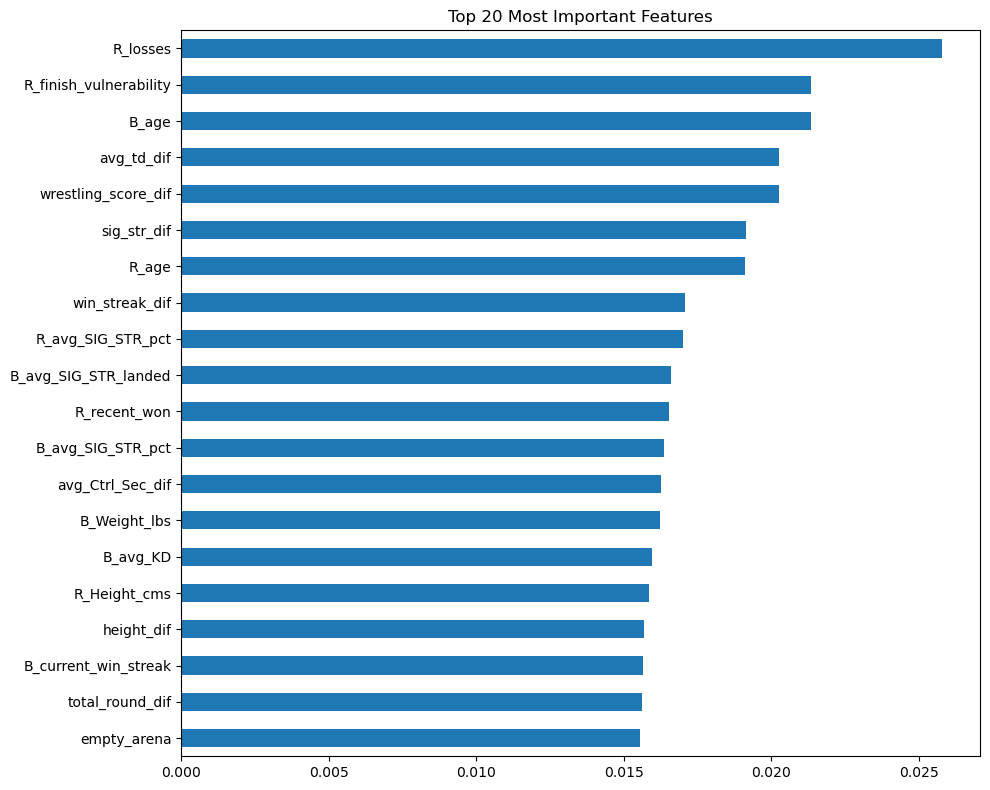

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import joblib

# Load the saved model
model = joblib.load('./model/ufc_model.pkl')
feature_cols = joblib.load('./model/feature_columns.pkl')

# Feature importance
importances = pd.Series(model.feature_importances_, index=feature_cols)
top20 = importances.sort_values(ascending=False).head(20)

print("Top 20 Features:")
for i, (feat, imp) in enumerate(top20.items(), 1):
    print(f"{i:2}. {feat:<40} {imp:.4f}")

# Plot
plt.figure(figsize=(10, 8))
top20.plot(kind='barh')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib
import matplotlib.pyplot as plt

# Load datasets
df_raw = pd.read_csv('./data/ufc-master.csv')
df_gold = pd.read_csv('./data/gold/ufc_gold_dataset_final.csv')

df_raw['date'] = pd.to_datetime(df_raw['date'])
df_gold['Event_Date'] = pd.to_datetime(df_gold['Event_Date'])

# Filter modern era
df_modern_raw = df_raw[df_raw['date'] >= '2015-01-01'].copy()
df_raw = df_raw[df_raw['Winner'].isin(['Red', 'Blue'])]
df_modern_raw = df_modern_raw[df_modern_raw['Winner'].isin(['Red', 'Blue'])]

# Filter experienced fighters (more than 2 fights)
fight_counts = Counter()
for fighter in df_modern_raw['R_fighter']:
    fight_counts[fighter] += 1
for fighter in df_modern_raw['B_fighter']:
    fight_counts[fighter] += 1

experienced_fighters = {f for f, count in fight_counts.items() if count > 2}
mask = (df_modern_raw['R_fighter'].isin(experienced_fighters) &
        df_modern_raw['B_fighter'].isin(experienced_fighters))
df_modern_filtered = df_modern_raw[mask].copy()

print(f"Modern filtered fights: {len(df_modern_filtered)}")
print("Base data loaded!")

Modern filtered fights: 4704
Base data loaded!


In [5]:
# Build fighter history for recent stats
red_fights = df_modern_raw[['date', 'R_fighter', 'Winner',
                      'R_avg_SIG_STR_landed', 'R_avg_SIG_STR_pct',
                      'R_avg_TD_landed', 'R_avg_TD_pct', 'R_avg_SUB_ATT']].copy()
red_fights.columns = ['date', 'fighter', 'Winner',
                      'avg_SIG_STR_landed', 'avg_SIG_STR_pct',
                      'avg_TD_landed', 'avg_TD_pct', 'avg_SUB_ATT']
red_fights['won'] = (red_fights['Winner'] == 'Red').astype(int)
red_fights['corner'] = 'Red'

blue_fights = df_modern_raw[['date', 'B_fighter', 'Winner',
                       'B_avg_SIG_STR_landed', 'B_avg_SIG_STR_pct',
                       'B_avg_TD_landed', 'B_avg_TD_pct', 'B_avg_SUB_ATT']].copy()
blue_fights.columns = ['date', 'fighter', 'Winner',
                       'avg_SIG_STR_landed', 'avg_SIG_STR_pct',
                       'avg_TD_landed', 'avg_TD_pct', 'avg_SUB_ATT']
blue_fights['won'] = (blue_fights['Winner'] == 'Blue').astype(int)
blue_fights['corner'] = 'Blue'

fighter_history = pd.concat([red_fights, blue_fights], ignore_index=True)
fighter_history = fighter_history.sort_values(['fighter', 'date']).reset_index(drop=True)

# Rolling recent stats
stats_cols = ['avg_SIG_STR_landed', 'avg_SIG_STR_pct',
              'avg_TD_landed', 'avg_TD_pct', 'avg_SUB_ATT', 'won']
recent_stats = fighter_history.groupby('fighter')[stats_cols].apply(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).reset_index(level=0, drop=True)
recent_stats.columns = [f'recent_{col}' for col in stats_cols]
fighter_history = pd.concat([fighter_history, recent_stats], axis=1)

print("Fighter history built!")

Fighter history built!


In [7]:
# Merge recent stats into main df
red_recent = fighter_history[fighter_history['corner'] == 'Red'][
    ['date', 'fighter', 'recent_won', 'recent_avg_SIG_STR_landed',
     'recent_avg_SIG_STR_pct', 'recent_avg_TD_landed',
     'recent_avg_TD_pct', 'recent_avg_SUB_ATT']].copy()
red_recent.columns = ['date', 'R_fighter'] + [f'R_{col}' for col in
    ['recent_won', 'recent_avg_SIG_STR_landed', 'recent_avg_SIG_STR_pct',
     'recent_avg_TD_landed', 'recent_avg_TD_pct', 'recent_avg_SUB_ATT']]

blue_recent = fighter_history[fighter_history['corner'] == 'Blue'][
    ['date', 'fighter', 'recent_won', 'recent_avg_SIG_STR_landed',
     'recent_avg_SIG_STR_pct', 'recent_avg_TD_landed',
     'recent_avg_TD_pct', 'recent_avg_SUB_ATT']].copy()
blue_recent.columns = ['date', 'B_fighter'] + [f'B_{col}' for col in
    ['recent_won', 'recent_avg_SIG_STR_landed', 'recent_avg_SIG_STR_pct',
     'recent_avg_TD_landed', 'recent_avg_TD_pct', 'recent_avg_SUB_ATT']]

df_final = df_modern_filtered.copy()
df_final = df_final.merge(red_recent, on=['date', 'R_fighter'], how='left')
df_final = df_final.merge(blue_recent, on=['date', 'B_fighter'], how='left')

df_final['recent_won_dif'] = df_final['R_recent_won'] - df_final['B_recent_won']
df_final['recent_sig_str_dif'] = df_final['R_recent_avg_SIG_STR_landed'] - df_final['B_recent_avg_SIG_STR_landed']
df_final['recent_td_dif'] = df_final['R_recent_avg_TD_landed'] - df_final['B_recent_avg_TD_landed']

print("Recent stats merged!")

Recent stats merged!


In [8]:
# Build gold dataset strike history
red_strikes = df_gold[['Event_Date', 'Fighter_1', 'F1_KD', 'F1_Ctrl_Sec']].copy()
red_strikes.columns = ['date', 'fighter', 'KD', 'Ctrl_Sec']

blue_strikes = df_gold[['Event_Date', 'Fighter_2', 'F2_KD', 'F2_Ctrl_Sec']].copy()
blue_strikes.columns = ['date', 'fighter', 'KD', 'Ctrl_Sec']

strike_history = pd.concat([red_strikes, blue_strikes], ignore_index=True)
strike_history = strike_history.sort_values(['fighter', 'date']).reset_index(drop=True)

strike_cols = ['KD', 'Ctrl_Sec']
recent_strikes = strike_history.groupby('fighter')[strike_cols].apply(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).reset_index(level=0, drop=True)
recent_strikes.columns = [f'avg_{col}' for col in strike_cols]
strike_history = pd.concat([strike_history, recent_strikes], axis=1)

# Merge for Red and Blue
red_avg = strike_history[['date', 'fighter', 'avg_KD', 'avg_Ctrl_Sec']].copy()
red_avg.columns = ['date', 'R_fighter', 'R_avg_KD', 'R_avg_Ctrl_Sec']
blue_avg = strike_history[['date', 'fighter', 'avg_KD', 'avg_Ctrl_Sec']].copy()
blue_avg.columns = ['date', 'B_fighter', 'B_avg_KD', 'B_avg_Ctrl_Sec']

df_final = df_final.merge(red_avg, on=['date', 'R_fighter'], how='left')
df_final = df_final.merge(blue_avg, on=['date', 'B_fighter'], how='left')

df_final['avg_KD_dif'] = df_final['R_avg_KD'] - df_final['B_avg_KD']
df_final['avg_Ctrl_Sec_dif'] = df_final['R_avg_Ctrl_Sec'] - df_final['B_avg_Ctrl_Sec']

# Engineered features
df_final['target'] = (df_final['Winner'] == 'Red').astype(int)
df_final['R_finish_rate'] = (df_final['R_win_by_KO/TKO'] + df_final['R_win_by_Submission']) / (df_final['R_wins'] + 1)
df_final['B_finish_rate'] = (df_final['B_win_by_KO/TKO'] + df_final['B_win_by_Submission']) / (df_final['B_wins'] + 1)
df_final['finish_rate_dif'] = df_final['R_finish_rate'] - df_final['B_finish_rate']
df_final['B_upset_potential'] = df_final['B_finish_rate']
df_final['R_finish_vulnerability'] = df_final['R_losses'] / (df_final['R_total_rounds_fought'] + 1)
df_final['R_wrestling_score'] = (df_final['R_avg_TD_landed'] * df_final['R_avg_TD_pct'] + df_final['R_avg_SUB_ATT'])
df_final['B_wrestling_score'] = (df_final['B_avg_TD_landed'] * df_final['B_avg_TD_pct'] + df_final['B_avg_SUB_ATT'])
df_final['wrestling_score_dif'] = df_final['R_wrestling_score'] - df_final['B_wrestling_score']

# Drop unwanted columns
odds_cols = ['R_odds', 'B_odds', 'r_dec_odds', 'b_dec_odds', 'r_sub_odds', 'b_sub_odds', 'r_ko_odds', 'b_ko_odds']
drop_cols = [
    'R_fighter', 'B_fighter', 'date', 'location', 'country',
    'Winner', 'finish', 'finish_round', 'finish_round_time',
    'total_fight_time_secs', 'R_ev', 'B_ev',
    'R_finish_ratio', 'B_finish_ratio', 'finish_ratio_dif', 'upset_index'
]

missing_pct = df_final.isnull().sum() / len(df_final)
high_missing = missing_pct[missing_pct > 0.5].index.tolist()

X_final = df_final.drop(columns=drop_cols + high_missing + ['target'] + odds_cols, errors='ignore')

# Encode categoricals
le = LabelEncoder()
for col in ['R_Stance', 'B_Stance', 'weight_class', 'gender', 'better_rank']:
    if col in X_final.columns:
        X_final[col] = X_final[col].fillna('Unknown')
        X_final[col] = le.fit_transform(X_final[col])

X_final = X_final.fillna(X_final.median(numeric_only=True)).copy()
y_final = df_final['target']

print(f"Missing values: {X_final.isnull().sum().sum()}")
print(f"Final shape: {X_final.shape}")

# Save the training dataframe
df_final.to_csv('./data/ufc_training_data.csv', index=False)
print("Training data saved to ./data/ufc_training_data.csv!")

Missing values: 0
Final shape: (4704, 98)
Training data saved to ./data/ufc_training_data.csv!


In [9]:
# Verify empty_arena is in our training features
print('empty_arena in X_final:', 'empty_arena' in X_final.columns)

# Also check ranking columns are NOT in X_final
rank_cols = [c for c in X_final.columns if 'rank' in c.lower()]
print(f'Ranking columns in X_final: {rank_cols}')

# Show exactly what X_final has
print(f'\nX_final columns ({len(X_final.columns)}):')
for col in sorted(X_final.columns):
    print(col)

empty_arena in X_final: True
Ranking columns in X_final: ['better_rank']

X_final columns (98):
B_Height_cms
B_Reach_cms
B_Stance
B_Weight_lbs
B_age
B_avg_Ctrl_Sec
B_avg_KD
B_avg_SIG_STR_landed
B_avg_SIG_STR_pct
B_avg_SUB_ATT
B_avg_TD_landed
B_avg_TD_pct
B_current_lose_streak
B_current_win_streak
B_draw
B_finish_rate
B_longest_win_streak
B_losses
B_recent_avg_SIG_STR_landed
B_recent_avg_SIG_STR_pct
B_recent_avg_SUB_ATT
B_recent_avg_TD_landed
B_recent_avg_TD_pct
B_recent_won
B_total_rounds_fought
B_total_title_bouts
B_upset_potential
B_win_by_Decision_Majority
B_win_by_Decision_Split
B_win_by_Decision_Unanimous
B_win_by_KO/TKO
B_win_by_Submission
B_win_by_TKO_Doctor_Stoppage
B_wins
B_wrestling_score
R_Height_cms
R_Reach_cms
R_Stance
R_Weight_lbs
R_age
R_avg_Ctrl_Sec
R_avg_KD
R_avg_SIG_STR_landed
R_avg_SIG_STR_pct
R_avg_SUB_ATT
R_avg_TD_landed
R_avg_TD_pct
R_current_lose_streak
R_current_win_streak
R_draw
R_finish_rate
R_finish_vulnerability
R_longest_win_streak
R_losses
R_recent_avg_SIG

In [10]:
import random

# Randomly swap corners for training data augmentation
def swap_corners(df):
    df_swapped = df.copy()
    
    # Get all R_ and B_ columns
    r_cols = [c for c in df.columns if c.startswith('R_')]
    b_cols = [c for c in df.columns if c.startswith('B_')]
    
    # For each row randomly decide to swap
    swap_mask = np.random.rand(len(df)) > 0.5
    
    for r_col, b_col in zip(sorted(r_cols), sorted(b_cols)):
        # Swap values where mask is True
        df_swapped.loc[swap_mask, r_col] = df.loc[swap_mask, b_col].values
        df_swapped.loc[swap_mask, b_col] = df.loc[swap_mask, r_col].values
    
    # Flip target when swapped (Red win becomes Blue win)
    df_swapped.loc[swap_mask, 'target'] = 1 - df_swapped.loc[swap_mask, 'target']
    
    return df_swapped

# Apply to X_final + target
df_train = X_final.copy()
df_train['target'] = y_final.values

# Augment — double the dataset with swapped versions
df_augmented = pd.concat([df_train, swap_corners(df_train)], ignore_index=True)

X_aug = df_augmented.drop(columns=['target'])
y_aug = df_augmented['target']

print(f"Original training size: {len(df_train)}")
print(f"Augmented training size: {len(df_augmented)}")
print(f"Red win rate after augmentation: {y_aug.mean():.2%}")

Original training size: 4704
Augmented training size: 9408
Red win rate after augmentation: 53.51%


/var/folders/v5/t211ltbs1h31hmkx96n0588w0000gn/T/ipykernel_15467/1939709058.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.07462687 0.10869565 0.35294118 ... 0.15625    0.10714286 0.21428571]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_swapped.loc[swap_mask, b_col] = df.loc[swap_mask, r_col].values
/var/folders/v5/t211ltbs1h31hmkx96n0588w0000gn/T/ipykernel_15467/1939709058.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3.58666667 4.65333333 3.58666667 ... 5.76       5.76       5.76      ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_swapped.loc[swap_mask, r_col] = df.loc[swap_mask, b_col].values
/var/folders/v5/t211ltbs1h31hmkx96n0588w0000gn/T/ipykernel_15467/1939709058.py:17: FutureWarning: Setting an item of i

In [11]:
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_aug, y_aug, test_size=0.2, random_state=42
)

xgb_aug = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,
    scale_pos_weight=len(y_aug[y_aug==0])/len(y_aug[y_aug==1])
)

xgb_aug.fit(
    X_train_aug, y_train_aug,
    eval_set=[(X_test_aug, y_test_aug)],
    verbose=25
)

y_pred_aug = xgb_aug.predict(X_test_aug)
accuracy_aug = accuracy_score(y_test_aug, y_pred_aug)
print(f"\nAugmented Model Accuracy: {accuracy_aug:.2%}")
print(f"Best iteration: {xgb_aug.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_test_aug, y_pred_aug, target_names=['Blue wins', 'Red wins']))

[0]	validation_0-logloss:0.69151
[25]	validation_0-logloss:0.66375
[50]	validation_0-logloss:0.65092
[75]	validation_0-logloss:0.64372
[100]	validation_0-logloss:0.63965
[125]	validation_0-logloss:0.63671
[150]	validation_0-logloss:0.63398
[175]	validation_0-logloss:0.63178
[200]	validation_0-logloss:0.62999
[225]	validation_0-logloss:0.62820
[250]	validation_0-logloss:0.62694
[275]	validation_0-logloss:0.62537
[300]	validation_0-logloss:0.62282
[325]	validation_0-logloss:0.62140
[350]	validation_0-logloss:0.62002
[375]	validation_0-logloss:0.61915
[400]	validation_0-logloss:0.61771
[425]	validation_0-logloss:0.61742
[450]	validation_0-logloss:0.61629
[475]	validation_0-logloss:0.61500
[499]	validation_0-logloss:0.61405

Augmented Model Accuracy: 65.89%
Best iteration: 497

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.62      0.66      0.64       858
    Red wins       0.70      0.66      0.68      1024

    accuracy                

Top 20 Features:
 1. R_losses                                 0.0267
 2. R_finish_vulnerability                   0.0195
 3. B_age                                    0.0183
 4. R_age                                    0.0176
 5. B_recent_avg_SIG_STR_pct                 0.0167
 6. R_avg_SIG_STR_pct                        0.0153
 7. win_streak_dif                           0.0142
 8. B_wrestling_score                        0.0142
 9. B_current_lose_streak                    0.0140
10. R_recent_avg_SIG_STR_landed              0.0137
11. B_avg_SIG_STR_pct                        0.0133
12. R_current_win_streak                     0.0131
13. R_recent_avg_TD_landed                   0.0129
14. B_avg_TD_landed                          0.0124
15. R_avg_TD_landed                          0.0121
16. R_wrestling_score                        0.0120
17. sig_str_dif                              0.0120
18. avg_td_dif                               0.0119
19. R_avg_TD_pct                             0.

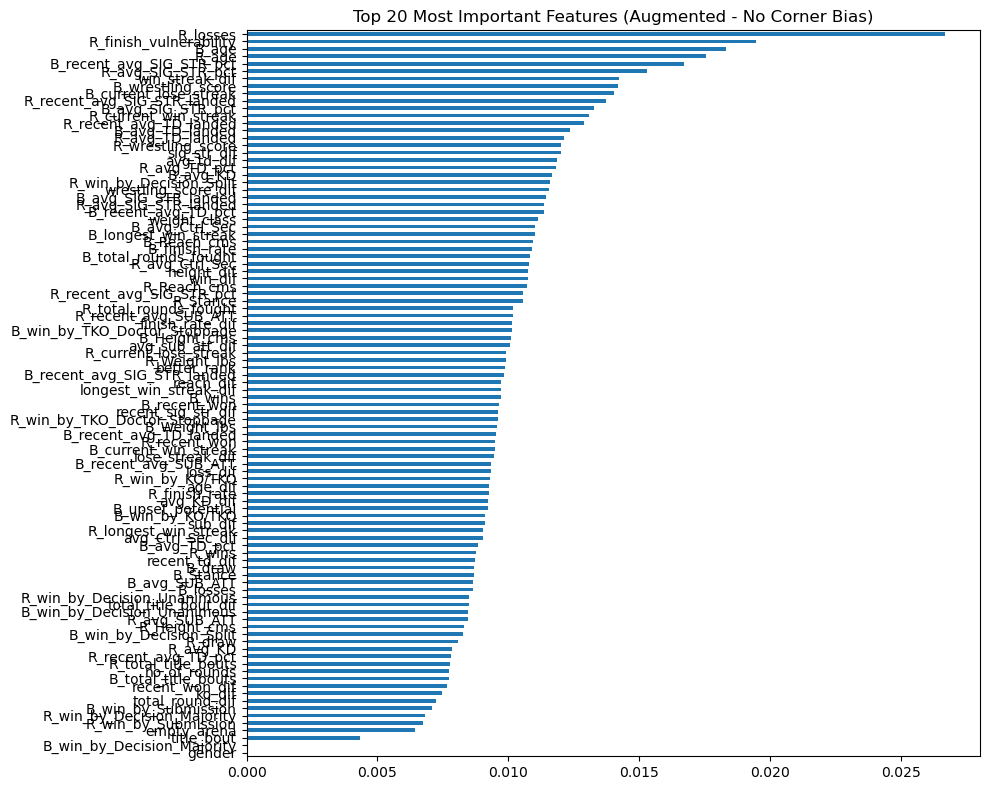

In [26]:
importances = pd.Series(xgb_aug.feature_importances_, index=X_aug.columns)
top20 = importances.sort_values(ascending=False).head(100)

print("Top 20 Features:")
for i, (feat, imp) in enumerate(top20.items(), 1):
    print(f"{i:2}. {feat:<40} {imp:.4f}")

plt.figure(figsize=(10, 8))
top20.plot(kind='barh')
plt.title('Top 20 Most Important Features (Augmented - No Corner Bias)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
joblib.dump(xgb_aug, './model/ufc_model.pkl')
joblib.dump(X_aug.columns.tolist(), './model/feature_columns.pkl')
print("New best model saved!")

New best model saved!


In [14]:
# Keep only diff columns and neutral fight info
diff_and_neutral_cols = [c for c in X_aug.columns if 
    c.endswith('_dif') or 
    c in ['weight_class', 'title_bout', 'no_of_rounds', 'empty_arena', 'gender', 'better_rank']]

print(f"Columns kept: {len(diff_and_neutral_cols)}")
for c in sorted(diff_and_neutral_cols):
    print(c)

Columns kept: 28
age_dif
avg_Ctrl_Sec_dif
avg_KD_dif
avg_sub_att_dif
avg_td_dif
better_rank
empty_arena
finish_rate_dif
gender
height_dif
ko_dif
longest_win_streak_dif
lose_streak_dif
loss_dif
no_of_rounds
reach_dif
recent_sig_str_dif
recent_td_dif
recent_won_dif
sig_str_dif
sub_dif
title_bout
total_round_dif
total_title_bout_dif
weight_class
win_dif
win_streak_dif
wrestling_score_dif


In [15]:
X_diff = X_aug[diff_and_neutral_cols].copy()

X_train_diff, X_test_diff, y_train_diff, y_test_diff = train_test_split(
    X_diff, y_aug, test_size=0.2, random_state=42
)

xgb_diff = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,
    scale_pos_weight=len(y_aug[y_aug==0])/len(y_aug[y_aug==1])
)

xgb_diff.fit(
    X_train_diff, y_train_diff,
    eval_set=[(X_test_diff, y_test_diff)],
    verbose=25
)

y_pred_diff = xgb_diff.predict(X_test_diff)
accuracy_diff = accuracy_score(y_test_diff, y_pred_diff)
print(f"\nDiff Only Model Accuracy: {accuracy_diff:.2%}")
print(f"Best iteration: {xgb_diff.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_test_diff, y_pred_diff, target_names=['Blue wins', 'Red wins']))

[0]	validation_0-logloss:0.69343
[25]	validation_0-logloss:0.68897
[50]	validation_0-logloss:0.68902
[59]	validation_0-logloss:0.68930

Diff Only Model Accuracy: 53.93%
Best iteration: 39

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.50      0.58      0.54       858
    Red wins       0.59      0.50      0.54      1024

    accuracy                           0.54      1882
   macro avg       0.54      0.54      0.54      1882
weighted avg       0.55      0.54      0.54      1882



In [16]:
# Rebuild X_aug with new loss context features
X_aug_new = X_aug.copy()

# Loss rate (losses per total fights) - more meaningful than raw losses
X_aug_new['R_loss_rate'] = X_aug['R_losses'] / (X_aug['R_wins'] + X_aug['R_losses'] + 1)
X_aug_new['B_loss_rate'] = X_aug['B_losses'] / (X_aug['B_wins'] + X_aug['B_losses'] + 1)
X_aug_new['loss_rate_dif'] = X_aug_new['R_loss_rate'] - X_aug_new['B_loss_rate']

# Experience gap — total fights difference
X_aug_new['R_total_fights'] = X_aug['R_wins'] + X_aug['R_losses']
X_aug_new['B_total_fights'] = X_aug['B_wins'] + X_aug['B_losses']
X_aug_new['total_fights_dif'] = X_aug_new['R_total_fights'] - X_aug_new['B_total_fights']

# Win rate — quality of record not just quantity
X_aug_new['R_win_rate'] = X_aug['R_wins'] / (X_aug['R_wins'] + X_aug['R_losses'] + 1)
X_aug_new['B_win_rate'] = X_aug['B_wins'] / (X_aug['B_wins'] + X_aug['B_losses'] + 1)
X_aug_new['win_rate_dif'] = X_aug_new['R_win_rate'] - X_aug_new['B_win_rate']

# Veteran vs prospect flag
# High losses + high wins = veteran, low losses + decent wins = prospect
X_aug_new['R_veteran_score'] = X_aug['R_losses'] * X_aug['R_wins']
X_aug_new['B_veteran_score'] = X_aug['B_losses'] * X_aug['B_wins']
X_aug_new['veteran_score_dif'] = X_aug_new['R_veteran_score'] - X_aug_new['B_veteran_score']

print(f"New shape: {X_aug_new.shape}")
print("\nNew features:")
new_feats = ['R_loss_rate', 'B_loss_rate', 'loss_rate_dif', 
             'R_total_fights', 'B_total_fights', 'total_fights_dif',
             'R_win_rate', 'B_win_rate', 'win_rate_dif',
             'R_veteran_score', 'B_veteran_score', 'veteran_score_dif']
print(X_aug_new[new_feats].describe())

New shape: (9408, 110)

New features:
       R_loss_rate  B_loss_rate  loss_rate_dif  R_total_fights  \
count  9408.000000  9408.000000    9408.000000     9408.000000   
mean      0.374968     0.279987       0.094981       11.284923   
std       0.249426     0.180859       0.292708       12.538573   
min       0.000000     0.000000      -0.750000        0.000000   
25%       0.222222     0.166667      -0.099449        4.000000   
50%       0.333333     0.307692       0.057692        7.240000   
75%       0.500000     0.400000       0.300000       13.521667   
max       0.990826     0.800000       0.990826      143.000000   

       B_total_fights  total_fights_dif   R_win_rate   B_win_rate  \
count     9408.000000       9408.000000  9408.000000  9408.000000   
mean         6.878720          4.406203     0.452571     0.459608   
std          6.336617         12.378673     0.238152     0.235409   
min          0.000000        -28.870000     0.000000     0.000000   
25%          2.000000 

In [ ]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_aug_new, y_aug, test_size=0.2, random_state=42
)

xgb_new = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,
    scale_pos_weight=len(y_aug[y_aug==0])/len(y_aug[y_aug==1])
)

xgb_new.fit(
    X_train_new, y_train_new,
    eval_set=[(X_test_new, y_test_new)],
    verbose=25
)

y_pred_new = xgb_new.predict(X_test_new)
accuracy_new = accuracy_score(y_test_new, y_pred_new)
print(f"\nNew Features Model Accuracy: {accuracy_new:.2%}")
print(f"Best iteration: {xgb_new.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_new, target_names=['Blue wins', 'Red wins']))

[0]	validation_0-logloss:0.69211
[25]	validation_0-logloss:0.66363
[50]	validation_0-logloss:0.65135
[75]	validation_0-logloss:0.64402
[100]	validation_0-logloss:0.63901
[125]	validation_0-logloss:0.63656
[150]	validation_0-logloss:0.63453
[175]	validation_0-logloss:0.63195
[200]	validation_0-logloss:0.62929
[225]	validation_0-logloss:0.62847
[250]	validation_0-logloss:0.62648
[275]	validation_0-logloss:0.62489
[300]	validation_0-logloss:0.62266
[325]	validation_0-logloss:0.62084
[350]	validation_0-logloss:0.61894
[375]	validation_0-logloss:0.61661
[400]	validation_0-logloss:0.61525
[425]	validation_0-logloss:0.61456
[450]	validation_0-logloss:0.61259
[475]	validation_0-logloss:0.61113
[499]	validation_0-logloss:0.60916

New Features Model Accuracy: 66.37%
Best iteration: 499

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.62      0.67      0.64       858
    Red wins       0.70      0.66      0.68      1024

    accuracy             

In [18]:
xgb_more = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=30,
    scale_pos_weight=len(y_aug[y_aug==0])/len(y_aug[y_aug==1])
)

xgb_more.fit(
    X_train_new, y_train_new,
    eval_set=[(X_test_new, y_test_new)],
    verbose=50
)

y_pred_more = xgb_more.predict(X_test_new)
accuracy_more = accuracy_score(y_test_new, y_pred_more)
print(f"\nMore Trees Model Accuracy: {accuracy_more:.2%}")
print(f"Best iteration: {xgb_more.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_more, target_names=['Blue wins', 'Red wins']))

[0]	validation_0-logloss:0.69211
[50]	validation_0-logloss:0.65135
[100]	validation_0-logloss:0.63901
[150]	validation_0-logloss:0.63453
[200]	validation_0-logloss:0.62929
[250]	validation_0-logloss:0.62648
[300]	validation_0-logloss:0.62266
[350]	validation_0-logloss:0.61894
[400]	validation_0-logloss:0.61525
[450]	validation_0-logloss:0.61259
[500]	validation_0-logloss:0.60914
[550]	validation_0-logloss:0.60724
[600]	validation_0-logloss:0.60494
[650]	validation_0-logloss:0.60266
[700]	validation_0-logloss:0.60078
[750]	validation_0-logloss:0.59850
[800]	validation_0-logloss:0.59617
[850]	validation_0-logloss:0.59411
[900]	validation_0-logloss:0.59185
[950]	validation_0-logloss:0.59039
[999]	validation_0-logloss:0.58949

More Trees Model Accuracy: 68.97%
Best iteration: 976

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.65      0.69      0.67       858
    Red wins       0.73      0.69      0.71      1024

    accuracy             

In [20]:
xgb_big = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_aug[y_aug==0])/len(y_aug[y_aug==1])
)

xgb_big.fit(
    X_train_new, y_train_new,
    eval_set=[(X_test_new, y_test_new)],
    verbose=100
)

y_pred_big = xgb_big.predict(X_test_new)
accuracy_big = accuracy_score(y_test_new, y_pred_big)
print(f"\nBig Model Accuracy: {accuracy_big:.2%}")
print(f"Best iteration: {xgb_big.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_big, target_names=['Blue wins', 'Red wins']))

[0]	validation_0-logloss:0.69211
[100]	validation_0-logloss:0.63901
[200]	validation_0-logloss:0.62929
[300]	validation_0-logloss:0.62266
[400]	validation_0-logloss:0.61525
[500]	validation_0-logloss:0.60914
[600]	validation_0-logloss:0.60494
[700]	validation_0-logloss:0.60078
[800]	validation_0-logloss:0.59617
[900]	validation_0-logloss:0.59185
[1000]	validation_0-logloss:0.58937
[1100]	validation_0-logloss:0.58666
[1200]	validation_0-logloss:0.58372
[1300]	validation_0-logloss:0.58106
[1400]	validation_0-logloss:0.57846
[1500]	validation_0-logloss:0.57665
[1600]	validation_0-logloss:0.57392
[1700]	validation_0-logloss:0.57134
[1800]	validation_0-logloss:0.57005
[1900]	validation_0-logloss:0.56799
[1999]	validation_0-logloss:0.56539

Big Model Accuracy: 71.04%
Best iteration: 1992

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.68      0.70      0.69       858
    Red wins       0.74      0.72      0.73      1024

    accuracy       

In [21]:
# Check for leakage in augmentation split
print(classification_report(y_test_new, y_pred_big, target_names=['Blue wins', 'Red wins']))

# Check if augmentation caused leakage
# Original dataset size
print(f"\nOriginal fights: {len(X_final)}")
print(f"Augmented size: {len(X_aug_new)}")
print(f"Test size: {len(X_test_new)}")
print(f"Expected test if no leakage: {len(X_aug_new) * 0.2:.0f}")

              precision    recall  f1-score   support

   Blue wins       0.68      0.70      0.69       858
    Red wins       0.74      0.72      0.73      1024

    accuracy                           0.71      1882
   macro avg       0.71      0.71      0.71      1882
weighted avg       0.71      0.71      0.71      1882


Original fights: 4704
Augmented size: 9408
Test size: 1882
Expected test if no leakage: 1882


In [22]:
# The real leakage test - split BEFORE augmenting
# This ensures no fight and its swapped version end up in different splits

# Start from original unaugmented data
df_train_orig = X_final.copy()
df_train_orig['target'] = y_final.values

# Split first on original data
X_tr_orig, X_te_orig, y_tr_orig, y_te_orig = train_test_split(
    df_train_orig.drop(columns=['target']), 
    df_train_orig['target'],
    test_size=0.2, random_state=42
)

# Now augment ONLY the training set
df_tr = X_tr_orig.copy()
df_tr['target'] = y_tr_orig.values

df_tr_aug = pd.concat([df_tr, swap_corners(df_tr)], ignore_index=True)

X_tr_aug = df_tr_aug.drop(columns=['target'])
y_tr_aug = df_tr_aug['target']

# Add new engineered features to both train and test
for df_part in [X_tr_aug, X_te_orig]:
    df_part['R_loss_rate'] = df_part['R_losses'] / (df_part['R_wins'] + df_part['R_losses'] + 1)
    df_part['B_loss_rate'] = df_part['B_losses'] / (df_part['B_wins'] + df_part['B_losses'] + 1)
    df_part['loss_rate_dif'] = df_part['R_loss_rate'] - df_part['B_loss_rate']
    df_part['R_total_fights'] = df_part['R_wins'] + df_part['R_losses']
    df_part['B_total_fights'] = df_part['B_wins'] + df_part['B_losses']
    df_part['total_fights_dif'] = df_part['R_total_fights'] - df_part['B_total_fights']
    df_part['R_win_rate'] = df_part['R_wins'] / (df_part['R_wins'] + df_part['R_losses'] + 1)
    df_part['B_win_rate'] = df_part['B_wins'] / (df_part['B_wins'] + df_part['B_losses'] + 1)
    df_part['win_rate_dif'] = df_part['R_win_rate'] - df_part['B_win_rate']
    df_part['R_veteran_score'] = df_part['R_losses'] * df_part['R_wins']
    df_part['B_veteran_score'] = df_part['B_losses'] * df_part['B_wins']
    df_part['veteran_score_dif'] = df_part['R_veteran_score'] - df_part['B_veteran_score']

print(f"Training size (augmented): {len(X_tr_aug)}")
print(f"Test size (clean, never augmented): {len(X_te_orig)}")
print(f"Train target balance: {y_tr_aug.mean():.2%}")
print(f"Test target balance: {y_te_orig.mean():.2%}")

Training size (augmented): 7526
Test size (clean, never augmented): 941
Train target balance: 53.79%
Test target balance: 51.01%


/var/folders/v5/t211ltbs1h31hmkx96n0588w0000gn/T/ipykernel_15467/1939709058.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.21428571 0.07692308 0.16       ... 0.17857143 0.1        0.125     ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_swapped.loc[swap_mask, b_col] = df.loc[swap_mask, r_col].values
/var/folders/v5/t211ltbs1h31hmkx96n0588w0000gn/T/ipykernel_15467/1939709058.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 4.         23.25        5.76       ... 23.05833333  5.76
  3.46      ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_swapped.loc[swap_mask, r_col] = df.loc[swap_mask, b_col].values
/var/folders/v5/t211ltbs1h31hmkx96n0588w0000gn/T/ipykernel_15467/1939709058.py:17: FutureWarning: Setting an item of 

In [23]:
# Fix swap_corners function
def swap_corners(df):
    df_swapped = df.copy().astype(float)  # convert all to float first to avoid dtype issues
    
    r_cols = sorted([c for c in df.columns if c.startswith('R_')])
    b_cols = sorted([c for c in df.columns if c.startswith('B_')])
    
    swap_mask = np.random.rand(len(df)) > 0.5
    
    for r_col, b_col in zip(r_cols, b_cols):
        r_vals = df_swapped.loc[swap_mask, r_col].values.copy()
        b_vals = df_swapped.loc[swap_mask, b_col].values.copy()
        df_swapped.loc[swap_mask, r_col] = b_vals
        df_swapped.loc[swap_mask, b_col] = r_vals
    
    df_swapped.loc[swap_mask, 'target'] = 1 - df_swapped.loc[swap_mask, 'target']
    
    return df_swapped

# Retrain on clean split
xgb_clean = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_aug[y_tr_aug==0])/len(y_tr_aug[y_tr_aug==1])
)

xgb_clean.fit(
    X_tr_aug, y_tr_aug,
    eval_set=[(X_te_orig, y_te_orig)],
    verbose=100
)

y_pred_clean = xgb_clean.predict(X_te_orig)
accuracy_clean = accuracy_score(y_te_orig, y_pred_clean)
print(f"\nClean Split Model Accuracy: {accuracy_clean:.2%}")
print(f"Best iteration: {xgb_clean.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_orig, y_pred_clean, target_names=['Blue wins', 'Red wins']))

[0]	validation_0-logloss:0.69170
[100]	validation_0-logloss:0.66062
[120]	validation_0-logloss:0.66124

Clean Split Model Accuracy: 61.32%
Best iteration: 70

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.63      0.52      0.57       461
    Red wins       0.60      0.70      0.65       480

    accuracy                           0.61       941
   macro avg       0.62      0.61      0.61       941
weighted avg       0.61      0.61      0.61       941



In [24]:
# More targeted approach - only augment Blue wins to balance classes
df_tr_blue_wins = df_tr[df_tr['target'] == 0].copy()  # Blue wins in training
df_tr_swapped = swap_corners(df_tr_blue_wins)

df_tr_balanced = pd.concat([df_tr, df_tr_swapped], ignore_index=True)

X_tr_bal = df_tr_balanced.drop(columns=['target'])
y_tr_bal = df_tr_balanced['target']

# Add engineered features
for df_part in [X_tr_bal, X_te_orig]:
    df_part['R_loss_rate'] = df_part['R_losses'] / (df_part['R_wins'] + df_part['R_losses'] + 1)
    df_part['B_loss_rate'] = df_part['B_losses'] / (df_part['B_wins'] + df_part['B_losses'] + 1)
    df_part['loss_rate_dif'] = df_part['R_loss_rate'] - df_part['B_loss_rate']
    df_part['R_total_fights'] = df_part['R_wins'] + df_part['R_losses']
    df_part['B_total_fights'] = df_part['B_wins'] + df_part['B_losses']
    df_part['total_fights_dif'] = df_part['R_total_fights'] - df_part['B_total_fights']
    df_part['R_win_rate'] = df_part['R_wins'] / (df_part['R_wins'] + df_part['R_losses'] + 1)
    df_part['B_win_rate'] = df_part['B_wins'] / (df_part['B_wins'] + df_part['B_losses'] + 1)
    df_part['win_rate_dif'] = df_part['R_win_rate'] - df_part['B_win_rate']
    df_part['R_veteran_score'] = df_part['R_losses'] * df_part['R_wins']
    df_part['B_veteran_score'] = df_part['B_losses'] * df_part['B_wins']
    df_part['veteran_score_dif'] = df_part['R_veteran_score'] - df_part['B_veteran_score']

print(f"Balanced training size: {len(X_tr_bal)}")
print(f"Target balance: {y_tr_bal.mean():.2%}")

xgb_bal = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_bal[y_tr_bal==0])/len(y_tr_bal[y_tr_bal==1])
)

xgb_bal.fit(
    X_tr_bal, y_tr_bal,
    eval_set=[(X_te_orig, y_te_orig)],
    verbose=100
)

y_pred_bal = xgb_bal.predict(X_te_orig)
accuracy_bal = accuracy_score(y_te_orig, y_pred_bal)
print(f"\nBalanced Model Accuracy: {accuracy_bal:.2%}")
print(f"Best iteration: {xgb_bal.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_orig, y_pred_bal, target_names=['Blue wins', 'Red wins']))

Balanced training size: 5364
Target balance: 55.28%


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:title_bout: object

In [25]:
# Fix dtypes before training
X_tr_bal = X_tr_bal.infer_objects().fillna(0)
X_te_orig = X_te_orig.infer_objects().fillna(0)

# Force all to numeric
X_tr_bal = X_tr_bal.apply(pd.to_numeric, errors='coerce').fillna(0)
X_te_orig = X_te_orig.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Any object dtypes in train: {X_tr_bal.select_dtypes('object').columns.tolist()}")
print(f"Any object dtypes in test: {X_te_orig.select_dtypes('object').columns.tolist()}")

xgb_bal.fit(
    X_tr_bal, y_tr_bal,
    eval_set=[(X_te_orig, y_te_orig)],
    verbose=100
)

y_pred_bal = xgb_bal.predict(X_te_orig)
accuracy_bal = accuracy_score(y_te_orig, y_pred_bal)
print(f"\nBalanced Model Accuracy: {accuracy_bal:.2%}")
print(f"Best iteration: {xgb_bal.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_orig, y_pred_bal, target_names=['Blue wins', 'Red wins']))

Any object dtypes in train: []
Any object dtypes in test: []
[0]	validation_0-logloss:0.69219
[100]	validation_0-logloss:0.67274
[186]	validation_0-logloss:0.67081

Balanced Model Accuracy: 58.45%
Best iteration: 136

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.55      0.79      0.65       461
    Red wins       0.66      0.39      0.49       480

    accuracy                           0.58       941
   macro avg       0.60      0.59      0.57       941
weighted avg       0.61      0.58      0.57       941



In [27]:
# Check odds columns are in df_final
print(df_modern_filtered[['R_odds', 'B_odds']].describe())
print(f"\nMissing odds: {df_modern_filtered['R_odds'].isna().sum()}")

            R_odds       B_odds
count  4484.000000  4484.000000
mean   -105.613961    40.442239
std     282.059007   257.747724
min   -2000.000000 -2200.000000
25%    -245.000000  -155.000000
50%    -142.000000   120.000000
75%     130.000000   200.000000
max    1100.000000  1200.000000

Missing odds: 220


In [28]:
# Filter to competitive fights only (no heavy favorites beyond -250)
df_competitive = df_modern_filtered.copy()

# Keep fights where odds data exists
df_competitive = df_competitive.dropna(subset=['R_odds', 'B_odds'])

# Remove blowouts — neither fighter should be worse than -250
# In American odds, -250 means heavy favorite
# We want fights where BOTH fighters are between -250 and +inf
mask = (df_competitive['R_odds'] >= -250) & (df_competitive['B_odds'] >= -250)
df_competitive = df_competitive[mask].copy()

print(f"Fights before filter: {len(df_modern_filtered)}")
print(f"Fights with odds: {4484}")
print(f"Competitive fights only: {len(df_competitive)}")
print(f"\nRed win rate in competitive fights: {(df_competitive['Winner'] == 'Red').mean():.2%}")
print(f"\nOdds distribution after filter:")
print(df_competitive[['R_odds', 'B_odds']].describe())

Fights before filter: 4704
Fights with odds: 4484
Competitive fights only: 3002

Red win rate in competitive fights: 52.40%

Odds distribution after filter:
            R_odds       B_odds
count  3002.000000  3002.000000
mean    -44.901732     1.149900
std     156.150561   158.685132
min    -250.000000  -250.000000
25%    -170.000000  -150.000000
50%    -125.000000   102.000000
75%     126.000000   145.000000
max     260.000000   500.000000


In [29]:
# Filter experienced fighters in competitive set
fight_counts_comp = Counter()
for fighter in df_competitive['R_fighter']:
    fight_counts_comp[fighter] += 1
for fighter in df_competitive['B_fighter']:
    fight_counts_comp[fighter] += 1

experienced_comp = {f for f, count in fight_counts_comp.items() if count > 2}
mask2 = (df_competitive['R_fighter'].isin(experienced_comp) & 
         df_competitive['B_fighter'].isin(experienced_comp))
df_competitive = df_competitive[mask2].copy()

print(f"After experience filter: {len(df_competitive)}")
print(f"Red win rate: {(df_competitive['Winner'] == 'Red').mean():.2%}")

After experience filter: 2451
Red win rate: 52.02%


In [30]:
# Rebuild fighter history on competitive set
red_fights_c = df_competitive[['date', 'R_fighter', 'Winner',
                      'R_avg_SIG_STR_landed', 'R_avg_SIG_STR_pct',
                      'R_avg_TD_landed', 'R_avg_TD_pct', 'R_avg_SUB_ATT']].copy()
red_fights_c.columns = ['date', 'fighter', 'Winner',
                      'avg_SIG_STR_landed', 'avg_SIG_STR_pct',
                      'avg_TD_landed', 'avg_TD_pct', 'avg_SUB_ATT']
red_fights_c['won'] = (red_fights_c['Winner'] == 'Red').astype(int)
red_fights_c['corner'] = 'Red'

blue_fights_c = df_competitive[['date', 'B_fighter', 'Winner',
                       'B_avg_SIG_STR_landed', 'B_avg_SIG_STR_pct',
                       'B_avg_TD_landed', 'B_avg_TD_pct', 'B_avg_SUB_ATT']].copy()
blue_fights_c.columns = ['date', 'fighter', 'Winner',
                       'avg_SIG_STR_landed', 'avg_SIG_STR_pct',
                       'avg_TD_landed', 'avg_TD_pct', 'avg_SUB_ATT']
blue_fights_c['won'] = (blue_fights_c['Winner'] == 'Blue').astype(int)
blue_fights_c['corner'] = 'Blue'

fighter_history_c = pd.concat([red_fights_c, blue_fights_c], ignore_index=True)
fighter_history_c = fighter_history_c.sort_values(['fighter', 'date']).reset_index(drop=True)

# Rolling recent stats
recent_stats_c = fighter_history_c.groupby('fighter')[stats_cols].apply(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).reset_index(level=0, drop=True)
recent_stats_c.columns = [f'recent_{col}' for col in stats_cols]
fighter_history_c = pd.concat([fighter_history_c, recent_stats_c], axis=1)

# Merge recent stats
red_recent_c = fighter_history_c[fighter_history_c['corner'] == 'Red'][
    ['date', 'fighter', 'recent_won', 'recent_avg_SIG_STR_landed',
     'recent_avg_SIG_STR_pct', 'recent_avg_TD_landed',
     'recent_avg_TD_pct', 'recent_avg_SUB_ATT']].copy()
red_recent_c.columns = ['date', 'R_fighter'] + [f'R_{col}' for col in
    ['recent_won', 'recent_avg_SIG_STR_landed', 'recent_avg_SIG_STR_pct',
     'recent_avg_TD_landed', 'recent_avg_TD_pct', 'recent_avg_SUB_ATT']]

blue_recent_c = fighter_history_c[fighter_history_c['corner'] == 'Blue'][
    ['date', 'fighter', 'recent_won', 'recent_avg_SIG_STR_landed',
     'recent_avg_SIG_STR_pct', 'recent_avg_TD_landed',
     'recent_avg_TD_pct', 'recent_avg_SUB_ATT']].copy()
blue_recent_c.columns = ['date', 'B_fighter'] + [f'B_{col}' for col in
    ['recent_won', 'recent_avg_SIG_STR_landed', 'recent_avg_SIG_STR_pct',
     'recent_avg_TD_landed', 'recent_avg_TD_pct', 'recent_avg_SUB_ATT']]

df_comp_final = df_competitive.copy()
df_comp_final = df_comp_final.merge(red_recent_c, on=['date', 'R_fighter'], how='left')
df_comp_final = df_comp_final.merge(blue_recent_c, on=['date', 'B_fighter'], how='left')

df_comp_final['recent_won_dif'] = df_comp_final['R_recent_won'] - df_comp_final['B_recent_won']
df_comp_final['recent_sig_str_dif'] = df_comp_final['R_recent_avg_SIG_STR_landed'] - df_comp_final['B_recent_avg_SIG_STR_landed']
df_comp_final['recent_td_dif'] = df_comp_final['R_recent_avg_TD_landed'] - df_comp_final['B_recent_avg_TD_landed']

print(f"Shape after merging recent stats: {df_comp_final.shape}")

Shape after merging recent stats: (2451, 133)


In [31]:
# Show full feature importance sorted
importances_full = pd.Series(xgb_clean.feature_importances_, index=X_te_orig.columns)
importances_full = importances_full.sort_values(ascending=False)

# Find natural cutoff
print("Bottom 20 features:")
print(importances_full.tail(20))

# Count features above different thresholds
for threshold in [0.01, 0.009, 0.008, 0.007]:
    count = (importances_full >= threshold).sum()
    print(f"Features above {threshold}: {count}")

Bottom 20 features:
recent_won_dif                  0.0
better_rank                     0.0
gender                          0.0
no_of_rounds                    0.0
B_current_lose_streak           0.0
B_draw                          0.0
B_win_by_Decision_Majority      0.0
B_win_by_Submission             0.0
B_win_by_TKO_Doctor_Stoppage    0.0
B_wins                          0.0
B_Stance                        0.0
R_draw                          0.0
R_win_by_TKO_Doctor_Stoppage    0.0
R_wins                          0.0
lose_streak_dif                 0.0
weight_class                    0.0
total_title_bout_dif            0.0
sub_dif                         0.0
empty_arena                     0.0
win_dif                         0.0
dtype: float32
Features above 0.01: 50
Features above 0.009: 58
Features above 0.008: 67
Features above 0.007: 74


In [32]:
# Merge gold dataset KD and Ctrl_Sec
red_avg_c = strike_history[['date', 'fighter', 'avg_KD', 'avg_Ctrl_Sec']].copy()
red_avg_c.columns = ['date', 'R_fighter', 'R_avg_KD', 'R_avg_Ctrl_Sec']
blue_avg_c = strike_history[['date', 'fighter', 'avg_KD', 'avg_Ctrl_Sec']].copy()
blue_avg_c.columns = ['date', 'B_fighter', 'B_avg_KD', 'B_avg_Ctrl_Sec']

df_comp_final = df_comp_final.merge(red_avg_c, on=['date', 'R_fighter'], how='left')
df_comp_final = df_comp_final.merge(blue_avg_c, on=['date', 'B_fighter'], how='left')

df_comp_final['avg_KD_dif'] = df_comp_final['R_avg_KD'] - df_comp_final['B_avg_KD']
df_comp_final['avg_Ctrl_Sec_dif'] = df_comp_final['R_avg_Ctrl_Sec'] - df_comp_final['B_avg_Ctrl_Sec']

# Target and engineered features
df_comp_final['target'] = (df_comp_final['Winner'] == 'Red').astype(int)
df_comp_final['R_finish_rate'] = (df_comp_final['R_win_by_KO/TKO'] + df_comp_final['R_win_by_Submission']) / (df_comp_final['R_wins'] + 1)
df_comp_final['B_finish_rate'] = (df_comp_final['B_win_by_KO/TKO'] + df_comp_final['B_win_by_Submission']) / (df_comp_final['B_wins'] + 1)
df_comp_final['finish_rate_dif'] = df_comp_final['R_finish_rate'] - df_comp_final['B_finish_rate']
df_comp_final['B_upset_potential'] = df_comp_final['B_finish_rate']
df_comp_final['R_finish_vulnerability'] = df_comp_final['R_losses'] / (df_comp_final['R_total_rounds_fought'] + 1)
df_comp_final['R_wrestling_score'] = (df_comp_final['R_avg_TD_landed'] * df_comp_final['R_avg_TD_pct'] + df_comp_final['R_avg_SUB_ATT'])
df_comp_final['B_wrestling_score'] = (df_comp_final['B_avg_TD_landed'] * df_comp_final['B_avg_TD_pct'] + df_comp_final['B_avg_SUB_ATT'])
df_comp_final['wrestling_score_dif'] = df_comp_final['R_wrestling_score'] - df_comp_final['B_wrestling_score']

# Loss context features
df_comp_final['R_loss_rate'] = df_comp_final['R_losses'] / (df_comp_final['R_wins'] + df_comp_final['R_losses'] + 1)
df_comp_final['B_loss_rate'] = df_comp_final['B_losses'] / (df_comp_final['B_wins'] + df_comp_final['B_losses'] + 1)
df_comp_final['loss_rate_dif'] = df_comp_final['R_loss_rate'] - df_comp_final['B_loss_rate']
df_comp_final['R_total_fights'] = df_comp_final['R_wins'] + df_comp_final['R_losses']
df_comp_final['B_total_fights'] = df_comp_final['B_wins'] + df_comp_final['B_losses']
df_comp_final['total_fights_dif'] = df_comp_final['R_total_fights'] - df_comp_final['B_total_fights']
df_comp_final['R_win_rate'] = df_comp_final['R_wins'] / (df_comp_final['R_wins'] + df_comp_final['R_losses'] + 1)
df_comp_final['B_win_rate'] = df_comp_final['B_wins'] / (df_comp_final['B_wins'] + df_comp_final['B_losses'] + 1)
df_comp_final['win_rate_dif'] = df_comp_final['R_win_rate'] - df_comp_final['B_win_rate']
df_comp_final['R_veteran_score'] = df_comp_final['R_losses'] * df_comp_final['R_wins']
df_comp_final['B_veteran_score'] = df_comp_final['B_losses'] * df_comp_final['B_wins']
df_comp_final['veteran_score_dif'] = df_comp_final['R_veteran_score'] - df_comp_final['B_veteran_score']

# Drop unwanted columns
drop_cols_c = [
    'R_fighter', 'B_fighter', 'date', 'location', 'country',
    'Winner', 'finish', 'finish_round', 'finish_round_time',
    'total_fight_time_secs', 'R_ev', 'B_ev',
    'R_finish_ratio', 'B_finish_ratio', 'finish_ratio_dif', 'upset_index',
    'R_odds', 'B_odds'  # remove odds - we filtered by them but don't train on them
]

missing_pct_c = df_comp_final.isnull().sum() / len(df_comp_final)
high_missing_c = missing_pct_c[missing_pct_c > 0.5].index.tolist()

X_comp = df_comp_final.drop(columns=drop_cols_c + high_missing_c + ['target'] + odds_cols, errors='ignore')

# Encode categoricals
le_c = LabelEncoder()
for col in ['R_Stance', 'B_Stance', 'weight_class', 'gender', 'better_rank']:
    if col in X_comp.columns:
        X_comp[col] = X_comp[col].fillna('Unknown')
        X_comp[col] = le_c.fit_transform(X_comp[col])

X_comp = X_comp.fillna(X_comp.median(numeric_only=True)).apply(pd.to_numeric, errors='coerce').fillna(0).copy()
y_comp = df_comp_final['target']

print(f"Missing values: {X_comp.isnull().sum().sum()}")
print(f"Final shape: {X_comp.shape}")

Missing values: 0
Final shape: (2451, 110)


In [33]:
# Split FIRST before augmenting
df_comp_train = X_comp.copy()
df_comp_train['target'] = y_comp.values

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_comp, y_comp, test_size=0.2, random_state=42
)

# Augment only training set
df_tr_c = X_tr_c.copy()
df_tr_c['target'] = y_tr_c.values
df_tr_c_aug = pd.concat([df_tr_c, swap_corners(df_tr_c)], ignore_index=True)

X_tr_c_aug = df_tr_c_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_c_aug = df_tr_c_aug['target']
X_te_c = X_te_c.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train size (augmented): {len(X_tr_c_aug)}")
print(f"Test size (clean): {len(X_te_c)}")
print(f"Train balance: {y_tr_c_aug.mean():.2%}")
print(f"Test balance: {y_te_c.mean():.2%}")

# Train
xgb_comp = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_c_aug[y_tr_c_aug==0])/len(y_tr_c_aug[y_tr_c_aug==1])
)

xgb_comp.fit(
    X_tr_c_aug, y_tr_c_aug,
    eval_set=[(X_te_c, y_te_c)],
    verbose=100
)

y_pred_comp = xgb_comp.predict(X_te_c)
accuracy_comp = accuracy_score(y_te_c, y_pred_comp)
print(f"\nCompetitive Model Accuracy: {accuracy_comp:.2%}")
print(f"Best iteration: {xgb_comp.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_c, y_pred_comp, target_names=['Blue wins', 'Red wins']))

Train size (augmented): 3920
Test size (clean): 491
Train balance: 50.71%
Test balance: 51.73%
[0]	validation_0-logloss:0.69295
[100]	validation_0-logloss:0.66917
[160]	validation_0-logloss:0.67242

Competitive Model Accuracy: 59.27%
Best iteration: 110

Classification Report:
              precision    recall  f1-score   support

   Blue wins       0.58      0.54      0.56       237
    Red wins       0.60      0.64      0.62       254

    accuracy                           0.59       491
   macro avg       0.59      0.59      0.59       491
weighted avg       0.59      0.59      0.59       491



In [35]:
# Fresh start - simple lean model
# Filters: 2015+, more than 1 fight, no odds filtering

# Filter modern era
df_lean = df_raw[df_raw['date'] >= '2015-01-01'].copy()
df_lean = df_lean[df_lean['Winner'].isin(['Red', 'Blue'])].copy()

# Filter experienced fighters (more than 1 fight)
fight_counts_lean = Counter()
for fighter in df_lean['R_fighter']:
    fight_counts_lean[fighter] += 1
for fighter in df_lean['B_fighter']:
    fight_counts_lean[fighter] += 1

experienced_lean = {f for f, count in fight_counts_lean.items() if count > 1}
mask_lean = (df_lean['R_fighter'].isin(experienced_lean) & 
             df_lean['B_fighter'].isin(experienced_lean))
df_lean = df_lean[mask_lean].copy()

print(f"Fights: {len(df_lean)}")
print(f"Red win rate: {(df_lean['Winner'] == 'Red').mean():.2%}")

Fights: 5208
Red win rate: 57.05%


In [38]:
# Randomly shuffle corners for the entire dataset before training
# This ensures the model never learns "Red = better"
np.random.seed(43)

df_shuffled = df_lean.copy()
swap_idx = np.random.rand(len(df_shuffled)) > 0.5

# Get all R_ and B_ columns
r_cols = [c for c in df_shuffled.columns if c.startswith('R_')]
b_cols = [c for c in df_shuffled.columns if c.startswith('B_')]

# Swap corners randomly
for r_col, b_col in zip(sorted(r_cols), sorted(b_cols)):
    r_vals = df_shuffled.loc[swap_idx, r_col].copy()
    b_vals = df_shuffled.loc[swap_idx, b_col].copy()
    df_shuffled.loc[swap_idx, r_col] = b_vals.values
    df_shuffled.loc[swap_idx, b_col] = r_vals.values

# Flip winner where swapped
df_shuffled.loc[swap_idx & (df_shuffled['Winner'] == 'Red'), 'Winner'] = 'TEMP'
df_shuffled.loc[swap_idx & (df_shuffled['Winner'] == 'Blue'), 'Winner'] = 'Red'
df_shuffled.loc[swap_idx & (df_shuffled['Winner'] == 'TEMP'), 'Winner'] = 'Blue'

print(f"Fights: {len(df_shuffled)}")
print(f"Red win rate after shuffle: {(df_shuffled['Winner'] == 'Red').mean():.2%}")

Fights: 5208
Red win rate after shuffle: 50.12%


In [39]:
# Build last 5 fights win rate for each fighter
red_fights_l = df_shuffled[['date', 'R_fighter', 'Winner']].copy()
red_fights_l.columns = ['date', 'fighter', 'Winner']
red_fights_l['won'] = (red_fights_l['Winner'] == 'Red').astype(int)

blue_fights_l = df_shuffled[['date', 'B_fighter', 'Winner']].copy()
blue_fights_l.columns = ['date', 'fighter', 'Winner']
blue_fights_l['won'] = (blue_fights_l['Winner'] == 'Blue').astype(int)

fighter_hist_l = pd.concat([red_fights_l, blue_fights_l], ignore_index=True)
fighter_hist_l = fighter_hist_l.sort_values(['fighter', 'date']).reset_index(drop=True)

# Last 5 fights win rate (shift 1 to avoid leakage)
fighter_hist_l['last5_won'] = fighter_hist_l.groupby('fighter')['won'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

# Merge back
red_last5 = fighter_hist_l[['date', 'fighter', 'last5_won']].copy()
red_last5.columns = ['date', 'R_fighter', 'R_last5_won']
blue_last5 = fighter_hist_l[['date', 'fighter', 'last5_won']].copy()
blue_last5.columns = ['date', 'B_fighter', 'B_last5_won']

df_shuffled['date'] = pd.to_datetime(df_shuffled['date'])
df_lean_model = df_shuffled.merge(red_last5, on=['date', 'R_fighter'], how='left')
df_lean_model = df_lean_model.merge(blue_last5, on=['date', 'B_fighter'], how='left')

print(f"Shape: {df_lean_model.shape}")
print(f"Last5 coverage R: {df_lean_model['R_last5_won'].notna().sum()}/{len(df_lean_model)}")
print(f"Last5 coverage B: {df_lean_model['B_last5_won'].notna().sum()}/{len(df_lean_model)}")

Shape: (5208, 120)
Last5 coverage R: 4398/5208
Last5 coverage B: 4432/5208


In [40]:
# Build lean feature set - only what matters
df_lean_model['target'] = (df_lean_model['Winner'] == 'Red').astype(int)

# Finishes and times finished
df_lean_model['R_finishes'] = df_lean_model['R_win_by_KO/TKO'] + df_lean_model['R_win_by_Submission']
df_lean_model['B_finishes'] = df_lean_model['B_win_by_KO/TKO'] + df_lean_model['B_win_by_Submission']
df_lean_model['R_finish_rate'] = df_lean_model['R_finishes'] / (df_lean_model['R_wins'] + 1)
df_lean_model['B_finish_rate'] = df_lean_model['B_finishes'] / (df_lean_model['B_wins'] + 1)

# Times finished (losses by finish as proxy)
df_lean_model['R_times_finished'] = df_lean_model['R_losses'] - df_lean_model['R_win_by_Decision_Unanimous'] - df_lean_model['R_win_by_Decision_Split'] - df_lean_model['R_win_by_Decision_Majority']
df_lean_model['B_times_finished'] = df_lean_model['B_losses'] - df_lean_model['B_win_by_Decision_Unanimous'] - df_lean_model['B_win_by_Decision_Split'] - df_lean_model['B_win_by_Decision_Majority']
df_lean_model['R_times_finished'] = df_lean_model['R_times_finished'].clip(lower=0)
df_lean_model['B_times_finished'] = df_lean_model['B_times_finished'].clip(lower=0)

# Total UFC fights (experience)
df_lean_model['R_ufc_fights'] = df_lean_model['R_wins'] + df_lean_model['R_losses']
df_lean_model['B_ufc_fights'] = df_lean_model['B_wins'] + df_lean_model['B_losses']

# Diff columns
df_lean_model['win_dif'] = df_lean_model['R_wins'] - df_lean_model['B_wins']
df_lean_model['loss_dif'] = df_lean_model['R_losses'] - df_lean_model['B_losses']
df_lean_model['finish_rate_dif'] = df_lean_model['R_finish_rate'] - df_lean_model['B_finish_rate']
df_lean_model['times_finished_dif'] = df_lean_model['R_times_finished'] - df_lean_model['B_times_finished']
df_lean_model['ufc_fights_dif'] = df_lean_model['R_ufc_fights'] - df_lean_model['B_ufc_fights']
df_lean_model['last5_dif'] = df_lean_model['R_last5_won'] - df_lean_model['B_last5_won']
df_lean_model['height_dif'] = df_lean_model['R_Height_cms'] - df_lean_model['B_Height_cms']
df_lean_model['age_dif'] = df_lean_model['R_age'] - df_lean_model['B_age']
df_lean_model['sig_str_dif'] = df_lean_model['R_avg_SIG_STR_landed'] - df_lean_model['B_avg_SIG_STR_landed']
df_lean_model['td_dif'] = df_lean_model['R_avg_TD_landed'] - df_lean_model['B_avg_TD_landed']

# Select only lean features
lean_features = [
    # Individual stats (both fighters)
    'R_wins', 'R_losses', 'R_ufc_fights', 'R_finish_rate', 
    'R_times_finished', 'R_last5_won', 'R_Height_cms', 'R_age',
    'R_avg_SIG_STR_landed', 'R_avg_TD_landed',
    'B_wins', 'B_losses', 'B_ufc_fights', 'B_finish_rate',
    'B_times_finished', 'B_last5_won', 'B_Height_cms', 'B_age',
    'B_avg_SIG_STR_landed', 'B_avg_TD_landed',
    # Diff columns
    'win_dif', 'loss_dif', 'finish_rate_dif', 'times_finished_dif',
    'ufc_fights_dif', 'last5_dif', 'height_dif', 'age_dif',
    'sig_str_dif', 'td_dif'
]

X_lean = df_lean_model[lean_features].fillna(df_lean_model[lean_features].median()).copy()
y_lean = df_lean_model['target']

print(f"Features: {len(lean_features)}")
print(f"Missing values: {X_lean.isnull().sum().sum()}")
print(f"Shape: {X_lean.shape}")

Features: 30
Missing values: 0
Shape: (5208, 30)


In [41]:
# Split FIRST before augmenting
X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_lean, y_lean, test_size=0.2, random_state=42
)

# Augment only training set
df_tr_l = X_tr_l.copy()
df_tr_l['target'] = y_tr_l.values

def swap_corners_lean(df):
    df_swapped = df.copy().astype(float)
    r_cols = sorted([c for c in df.columns if c.startswith('R_')])
    b_cols = sorted([c for c in df.columns if c.startswith('B_')])
    swap_mask = np.random.rand(len(df)) > 0.5
    for r_col, b_col in zip(r_cols, b_cols):
        r_vals = df_swapped.loc[swap_mask, r_col].values.copy()
        b_vals = df_swapped.loc[swap_mask, b_col].values.copy()
        df_swapped.loc[swap_mask, r_col] = b_vals
        df_swapped.loc[swap_mask, b_col] = r_vals
    # Flip diffs too
    diff_cols = [c for c in df.columns if c.endswith('_dif')]
    for col in diff_cols:
        df_swapped.loc[swap_mask, col] = -df_swapped.loc[swap_mask, col]
    df_swapped.loc[swap_mask, 'target'] = 1 - df_swapped.loc[swap_mask, 'target']
    return df_swapped

df_tr_l_aug = pd.concat([df_tr_l, swap_corners_lean(df_tr_l)], ignore_index=True)

X_tr_l_aug = df_tr_l_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_l_aug = df_tr_l_aug['target']
X_te_l = X_te_l.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train size (augmented): {len(X_tr_l_aug)}")
print(f"Test size (clean): {len(X_te_l)}")
print(f"Train balance: {y_tr_l_aug.mean():.2%}")
print(f"Test balance: {y_te_l.mean():.2%}")

# Train
xgb_lean = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_l_aug[y_tr_l_aug==0])/len(y_tr_l_aug[y_tr_l_aug==1])
)

xgb_lean.fit(
    X_tr_l_aug, y_tr_l_aug,
    eval_set=[(X_te_l, y_te_l)],
    verbose=100
)

y_pred_l = xgb_lean.predict(X_te_l)
accuracy_l = accuracy_score(y_te_l, y_pred_l)
print(f"\nLean Model Accuracy: {accuracy_l:.2%}")
print(f"Best iteration: {xgb_lean.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_l, y_pred_l, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Train size (augmented): 8332
Test size (clean): 1042
Train balance: 50.23%
Test balance: 49.23%
[0]	validation_0-logloss:0.69080
[100]	validation_0-logloss:0.65410
[156]	validation_0-logloss:0.65442

Lean Model Accuracy: 63.15%
Best iteration: 106

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.63      0.66      0.64       529
Fighter 1 wins       0.63      0.60      0.62       513

      accuracy                           0.63      1042
     macro avg       0.63      0.63      0.63      1042
  weighted avg       0.63      0.63      0.63      1042



In [42]:
joblib.dump(xgb_lean, './model/ufc_model.pkl')
joblib.dump(lean_features, './model/feature_columns.pkl')
print("Lean model saved!")
print(f"Accuracy: 63.15%")
print(f"Features: {len(lean_features)}")

# Check feature importance
importances_l = pd.Series(xgb_lean.feature_importances_, index=lean_features)
top_l = importances_l.sort_values(ascending=False)
print("\nFeature Importance:")
for i, (feat, imp) in enumerate(top_l.items(), 1):
    print(f"{i:2}. {feat:<30} {imp:.4f}")

Lean model saved!
Accuracy: 63.15%
Features: 30

Feature Importance:
 1. age_dif                        0.0858
 2. sig_str_dif                    0.0504
 3. td_dif                         0.0485
 4. R_last5_won                    0.0467
 5. B_age                          0.0448
 6. last5_dif                      0.0414
 7. B_avg_TD_landed                0.0402
 8. B_last5_won                    0.0378
 9. R_avg_SIG_STR_landed           0.0337
10. ufc_fights_dif                 0.0318
11. loss_dif                       0.0313
12. finish_rate_dif                0.0312
13. win_dif                        0.0312
14. times_finished_dif             0.0293
15. B_avg_SIG_STR_landed           0.0291
16. R_ufc_fights                   0.0285
17. R_finish_rate                  0.0276
18. B_Height_cms                   0.0276
19. height_dif                     0.0269
20. R_times_finished               0.0268
21. R_Height_cms                   0.0267
22. R_avg_TD_landed                0.0267
23. R_w

In [43]:
import requests
from bs4 import BeautifulSoup

# Test Wikipedia fighter page
url = "https://en.wikipedia.org/wiki/Conor_McGregor"
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'lxml')

# Look for the infobox which has fighter stats
infobox = soup.find('table', class_='infobox')
if infobox:
    rows = infobox.find_all('tr')
    for row in rows:
        print(row.text.strip())

Conor McGregor
McGregor in 2025
BornConor Anthony McGregor (1988-07-14) 14 July 1988 (age 37)Dublin, Ireland
Other namesNotorious
OccupationsMixed martial artistbusinessman
Criminal charges20+, including driving offences and assault[1][2]
Spouse
Dee Devlin ​(m. 2025)​
Children4
RelativesKeith Buckley (cousin)Warren Davis (cousin)
Martial arts career
Height5 ft 8 in (173 cm)
Weight155 lb (70 kg; 11 st 1 lb)
DivisionFeatherweight (2008–2015)Lightweight (2008–2012, 2016–2018, 2021–present)Welterweight (2016, 2020)
Reach74 in (188 cm)[3][4]
StanceSouthpaw
TeamSBG Ireland
TrainerJohn Kavanagh (head coach)[5]Owen Roddy, Raj Vrînceanu (Boxing)[6]Sergey Pikulskiy (Wrestling)John Connor (S&C)[7]George Lockhart (Nutrition)[8]
RankBlack belt in Brazilian jiu-jitsu[9] under John Kavanagh[10]
Years active2008–present

Professional boxing record
Total1
Losses1
By knockout1


Mixed martial arts record
Total28
Wins22
By knockout19
By submission1
By decision2
Losses6
By knockout2
By submission4


Amate

In [44]:
import time

def get_wikipedia_fighter_stats(name):
    # Convert name to Wikipedia URL format
    wiki_name = name.replace(' ', '_')
    url = f"https://en.wikipedia.org/wiki/{wiki_name}"
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}
    
    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code != 200:
            return None
            
        soup = BeautifulSoup(response.content, 'lxml')
        infobox = soup.find('table', class_='infobox')
        if not infobox:
            return None
            
        # Parse all rows into a dict
        data = {}
        rows = infobox.find_all('tr')
        for row in rows:
            th = row.find('th')
            td = row.find('td')
            if th and td:
                key = th.text.strip()
                val = td.text.strip()
                data[key] = val
        
        # Extract MMA record section
        text = infobox.text
        
        # Total MMA record
        result = {'name': name, 'wiki_url': url}
        
        # Find MMA record numbers
        import re
        
        # Look for MMA record block
        mma_section = re.search(r'Mixed martial arts record.*?(?=Professional boxing|Amateur|Other information|$)', 
                                text, re.DOTALL)
        
        if mma_section:
            mma_text = mma_section.group()
            
            # Extract total, wins, losses
            total = re.search(r'Total(\d+)', mma_text)
            wins = re.search(r'Wins(\d+)', mma_text)
            losses = re.search(r'Losses(\d+)', mma_text)
            ko_wins = re.search(r'By knockout(\d+)', mma_text)
            sub_wins = re.search(r'By submission(\d+)', mma_text)
            dec_wins = re.search(r'By decision(\d+)', mma_text)
            
            result['total_mma_fights'] = int(total.group(1)) if total else None
            result['total_mma_wins'] = int(wins.group(1)) if wins else None
            result['total_mma_losses'] = int(losses.group(1)) if losses else None
            result['mma_ko_wins'] = int(ko_wins.group(1)) if ko_wins else None
            result['mma_sub_wins'] = int(sub_wins.group(1)) if sub_wins else None
            result['mma_dec_wins'] = int(dec_wins.group(1)) if dec_wins else None
        
        # Nationality from Born field
        born = data.get('Born', '')
        result['nationality'] = born.split('\n')[-1].strip() if born else None
        
        # Stance
        result['stance'] = data.get('Stance', None)
        
        # Team
        result['team'] = data.get('Team', None)
        
        return result
        
    except Exception as e:
        return None

# Test with McGregor
result = get_wikipedia_fighter_stats('Conor McGregor')
for k, v in result.items():
    print(f"{k}: {v}")

name: Conor McGregor
wiki_url: https://en.wikipedia.org/wiki/Conor_McGregor
total_mma_fights: 28
total_mma_wins: 22
total_mma_losses: 6
mma_ko_wins: None
mma_sub_wins: None
mma_dec_wins: None
nationality: Conor Anthony McGregor (1988-07-14) 14 July 1988 (age 37)Dublin, Ireland
stance: Southpaw
team: SBG Ireland


In [45]:
# Get all unique fighters from our dataset
all_fighters = sorted(set(df_lean['R_fighter'].unique()) | set(df_lean['B_fighter'].unique()))
print(f"Total fighters to look up: {len(all_fighters)}")

# Scrape with delay
fighter_records = {}
failed = []

for i, name in enumerate(all_fighters):
    result = get_wikipedia_fighter_stats(name)
    if result and result.get('total_mma_wins') is not None:
        fighter_records[name] = result
    else:
        failed.append(name)
    
    # Progress update every 50 fighters
    if (i + 1) % 50 == 0:
        print(f"Progress: {i+1}/{len(all_fighters)} — Found: {len(fighter_records)} — Failed: {len(failed)}")
    
    # Be respectful to Wikipedia
    time.sleep(0.5)

print(f"\nDone!")
print(f"Successfully scraped: {len(fighter_records)}")
print(f"Failed/not found: {len(failed)}")

Total fighters to look up: 1586
Progress: 50/1586 — Found: 27 — Failed: 23
Progress: 100/1586 — Found: 57 — Failed: 43
Progress: 150/1586 — Found: 90 — Failed: 60
Progress: 200/1586 — Found: 123 — Failed: 77
Progress: 250/1586 — Found: 148 — Failed: 102
Progress: 300/1586 — Found: 180 — Failed: 120
Progress: 350/1586 — Found: 212 — Failed: 138
Progress: 400/1586 — Found: 241 — Failed: 159
Progress: 450/1586 — Found: 271 — Failed: 179
Progress: 500/1586 — Found: 302 — Failed: 198
Progress: 550/1586 — Found: 331 — Failed: 219
Progress: 600/1586 — Found: 368 — Failed: 232
Progress: 650/1586 — Found: 404 — Failed: 246
Progress: 700/1586 — Found: 436 — Failed: 264
Progress: 750/1586 — Found: 470 — Failed: 280
Progress: 800/1586 — Found: 499 — Failed: 301
Progress: 850/1586 — Found: 536 — Failed: 314
Progress: 900/1586 — Found: 567 — Failed: 333
Progress: 950/1586 — Found: 598 — Failed: 352
Progress: 1000/1586 — Found: 630 — Failed: 370
Progress: 1050/1586 — Found: 666 — Failed: 384
Progress

In [46]:
# Check what we have
print(f"Successfully scraped: {len(fighter_records)}")

# Sample some failures to understand why
print("\nSample failed fighters:")
for name in failed[:20]:
    print(f"  {name}")

Successfully scraped: 1022

Sample failed fighters:
  AJ Cunningham
  AJ Dobson
  AJ Fletcher
  Aalon Cruz
  Aaron Phillips
  Abdul-Kareem Al-Selwady
  Abu Azaitar
  Adam Fugitt
  Ailin Perez
  Alan Patrick
  Alatengheili
  Albert Duraev
  Alberto Uda
  Alden Coria
  Alejandro Perez
  Aleksandar Rakic
  Aleksei Kunchenko
  Alessandro Costa
  Alessandro Ricci
  Alex Da Silva


In [47]:
def clean_name_for_wiki(name):
    """Try alternate Wikipedia URL formats"""
    attempts = [
        name.replace(' ', '_'),                          # Standard
        name.replace("'", '%27').replace(' ', '_'),      # Apostrophes
        name.replace('.', '').replace(' ', '_'),         # Remove periods
        '_'.join(name.split()[::-1]),                    # Last_First
    ]
    return attempts

# Try to recover failed fighters
recovered = {}
still_failed = []

for i, name in enumerate(failed):
    found = False
    for attempt in clean_name_for_wiki(name)[1:]:  # Skip first, already tried
        url = f"https://en.wikipedia.org/wiki/{attempt}"
        headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}
        try:
            response = requests.get(url, headers=headers, timeout=10)
            if response.status_code == 200:
                soup = BeautifulSoup(response.content, 'lxml')
                infobox = soup.find('table', class_='infobox')
                if infobox and 'martial arts' in infobox.text.lower():
                    result = get_wikipedia_fighter_stats(attempt.replace('_', ' '))
                    if result and result.get('total_mma_wins') is not None:
                        recovered[name] = result
                        found = True
                        break
        except:
            pass
        time.sleep(0.3)
    
    if not found:
        still_failed.append(name)
    
    if (i + 1) % 50 == 0:
        print(f"Progress: {i+1}/{len(failed)} — Recovered: {len(recovered)}")

print(f"\nRecovered: {len(recovered)}")
print(f"Still failed: {len(still_failed)}")

# Merge all records
all_records = {**fighter_records, **recovered}
print(f"Total records: {len(all_records)}")

Progress: 50/564 — Recovered: 0
Progress: 100/564 — Recovered: 1
Progress: 150/564 — Recovered: 1
Progress: 200/564 — Recovered: 1
Progress: 250/564 — Recovered: 1
Progress: 300/564 — Recovered: 1
Progress: 350/564 — Recovered: 6
Progress: 400/564 — Recovered: 6
Progress: 450/564 — Recovered: 6
Progress: 500/564 — Recovered: 6
Progress: 550/564 — Recovered: 6

Recovered: 6
Still failed: 558
Total records: 1028


In [48]:
# Check coverage with just what we already have
all_records_combined = {**fighter_records}

df_lean['R_has_wiki'] = df_lean['R_fighter'].isin(all_records_combined)
df_lean['B_has_wiki'] = df_lean['B_fighter'].isin(all_records_combined)
df_lean['both_have_wiki'] = df_lean['R_has_wiki'] & df_lean['B_has_wiki']

print(f"Total fights: {len(df_lean)}")
print(f"Fights where BOTH fighters have wiki data: {df_lean['both_have_wiki'].sum()}")
print(f"Coverage: {df_lean['both_have_wiki'].mean():.1%}")

Total fights: 5208
Fights where BOTH fighters have wiki data: 3181
Coverage: 61.1%


In [49]:
# Check coverage on just the fighters we actually care about
# (modern era, more than 1 fight - same filter as our lean model)
fight_counts_wiki = Counter()
for fighter in df_lean['R_fighter']:
    fight_counts_wiki[fighter] += 1
for fighter in df_lean['B_fighter']:
    fight_counts_wiki[fighter] += 1

experienced_wiki = {f for f, count in fight_counts_wiki.items() if count > 1}

df_lean_exp = df_lean[
    df_lean['R_fighter'].isin(experienced_wiki) & 
    df_lean['B_fighter'].isin(experienced_wiki)
].copy()

df_lean_exp['R_has_wiki'] = df_lean_exp['R_fighter'].isin(all_records_combined)
df_lean_exp['B_has_wiki'] = df_lean_exp['B_fighter'].isin(all_records_combined)
df_lean_exp['both_have_wiki'] = df_lean_exp['R_has_wiki'] & df_lean_exp['B_has_wiki']

print(f"Experienced fighters fights: {len(df_lean_exp)}")
print(f"Both have wiki: {df_lean_exp['both_have_wiki'].sum()}")
print(f"Coverage: {df_lean_exp['both_have_wiki'].mean():.1%}")

Experienced fighters fights: 5187
Both have wiki: 3177
Coverage: 61.2%


In [52]:
# Rebuild wiki_df from what we scraped
wiki_df = []
for name, record in fighter_records.items():
    wiki_df.append({
        'fighter': name,
        'total_mma_fights': record.get('total_mma_fights'),
        'total_mma_wins': record.get('total_mma_wins'),
        'total_mma_losses': record.get('total_mma_losses'),
    })

wiki_df = pd.DataFrame(wiki_df)
print(f"Wiki dataframe shape: {wiki_df.shape}")
print(wiki_df.head(10))

Wiki dataframe shape: (1022, 4)
                 fighter  total_mma_fights  total_mma_wins  total_mma_losses
0   Abdul Razak Alhassan                20              12                 7
1          Abel Trujillo                24              15                 8
2  Abubakar Nurmagomedov                22              17                 4
3         Abus Magomedov                36              28                 7
4          Adam Milstead                12               8                 3
5         Adam Wieczorek                14              11                 3
6           Adrian Yanez                24              17                 6
7        Adriano Martins                43              29                13
8         Aiemann Zahabi                16              14                 2
9           Aisling Daly                22              16                 6


In [53]:
# Filter to only fights where both fighters have wiki data
df_wiki = df_lean[df_lean['both_have_wiki']].copy()
print(f"Fights with both wiki records: {len(df_wiki)}")
print(f"Red win rate: {(df_wiki['Winner'] == 'Red').mean():.2%}")

# Merge wiki records for Red fighter
red_wiki = wiki_df.copy()
red_wiki.columns = ['R_fighter', 'R_total_mma_fights', 'R_total_mma_wins', 'R_total_mma_losses']

blue_wiki = wiki_df.copy()
blue_wiki.columns = ['B_fighter', 'B_total_mma_fights', 'B_total_mma_wins', 'B_total_mma_losses']

df_wiki = df_wiki.merge(red_wiki, on='R_fighter', how='left')
df_wiki = df_wiki.merge(blue_wiki, on='B_fighter', how='left')

# Pre-UFC fights = total - UFC fights
df_wiki['R_pre_ufc_wins'] = (df_wiki['R_total_mma_wins'] - df_wiki['R_wins']).clip(lower=0)
df_wiki['B_pre_ufc_wins'] = (df_wiki['B_total_mma_wins'] - df_wiki['B_wins']).clip(lower=0)
df_wiki['R_pre_ufc_losses'] = (df_wiki['R_total_mma_losses'] - df_wiki['R_losses']).clip(lower=0)
df_wiki['B_pre_ufc_losses'] = (df_wiki['B_total_mma_losses'] - df_wiki['B_losses']).clip(lower=0)

# Diff columns
df_wiki['total_mma_wins_dif'] = df_wiki['R_total_mma_wins'] - df_wiki['B_total_mma_wins']
df_wiki['total_mma_losses_dif'] = df_wiki['R_total_mma_losses'] - df_wiki['B_total_mma_losses']
df_wiki['total_mma_fights_dif'] = df_wiki['R_total_mma_fights'] - df_wiki['B_total_mma_fights']
df_wiki['pre_ufc_wins_dif'] = df_wiki['R_pre_ufc_wins'] - df_wiki['B_pre_ufc_wins']

print(f"\nNew features sample:")
print(df_wiki[['R_fighter', 'R_total_mma_wins', 'R_wins', 'R_pre_ufc_wins',
               'B_fighter', 'B_total_mma_wins', 'B_wins', 'B_pre_ufc_wins']].head(10))

Fights with both wiki records: 3181
Red win rate: 55.08%

New features sample:
            R_fighter  R_total_mma_wins  R_wins  R_pre_ufc_wins  \
0     Israel Adesanya                24      13              11   
1        Alexa Grasso                17       8               9   
2      Michael Chiesa                20      14               6   
3  Ignacio Bahamondes                17       7              10   
4       Movsar Evloev                20       9              11   
5       Roman Dolidze                15       9               6   
6         Josh Emmett                19      10               9   
7        Amanda Lemos                15       9               6   
8        Brad Tavares                21      16               5   
9        Max Holloway                27      23               4   

                B_fighter  B_total_mma_wins  B_wins  B_pre_ufc_wins  
0               Joe Pyfer                16       7               9  
1           Maycee Barber                15

In [54]:
# Shuffle corners first
np.random.seed(43)
swap_idx = np.random.rand(len(df_wiki)) > 0.5

r_cols = [c for c in df_wiki.columns if c.startswith('R_')]
b_cols = [c for c in df_wiki.columns if c.startswith('B_')]

for r_col, b_col in zip(sorted(r_cols), sorted(b_cols)):
    r_vals = df_wiki.loc[swap_idx, r_col].copy()
    b_vals = df_wiki.loc[swap_idx, b_col].copy()
    df_wiki.loc[swap_idx, r_col] = b_vals.values
    df_wiki.loc[swap_idx, b_col] = r_vals.values

df_wiki.loc[swap_idx & (df_wiki['Winner'] == 'Red'), 'Winner'] = 'TEMP'
df_wiki.loc[swap_idx & (df_wiki['Winner'] == 'Blue'), 'Winner'] = 'Red'
df_wiki.loc[swap_idx & (df_wiki['Winner'] == 'TEMP'), 'Winner'] = 'Blue'

print(f"Red win rate after shuffle: {(df_wiki['Winner'] == 'Red').mean():.2%}")

# Rebuild last 5 fights on wiki dataset
red_fights_w = df_wiki[['date', 'R_fighter', 'Winner']].copy()
red_fights_w.columns = ['date', 'fighter', 'Winner']
red_fights_w['won'] = (red_fights_w['Winner'] == 'Red').astype(int)

blue_fights_w = df_wiki[['date', 'B_fighter', 'Winner']].copy()
blue_fights_w.columns = ['date', 'fighter', 'Winner']
blue_fights_w['won'] = (blue_fights_w['Winner'] == 'Blue').astype(int)

fighter_hist_w = pd.concat([red_fights_w, blue_fights_w], ignore_index=True)
fighter_hist_w = fighter_hist_w.sort_values(['fighter', 'date']).reset_index(drop=True)
fighter_hist_w['last5_won'] = fighter_hist_w.groupby('fighter')['won'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

red_last5_w = fighter_hist_w[['date', 'fighter', 'last5_won']].copy()
red_last5_w.columns = ['date', 'R_fighter', 'R_last5_won']
blue_last5_w = fighter_hist_w[['date', 'fighter', 'last5_won']].copy()
blue_last5_w.columns = ['date', 'B_fighter', 'B_last5_won']

df_wiki = df_wiki.merge(red_last5_w, on=['date', 'R_fighter'], how='left')
df_wiki = df_wiki.merge(blue_last5_w, on=['date', 'B_fighter'], how='left')

# Build lean features + wiki features
df_wiki['target'] = (df_wiki['Winner'] == 'Red').astype(int)
df_wiki['R_finishes'] = df_wiki['R_win_by_KO/TKO'] + df_wiki['R_win_by_Submission']
df_wiki['B_finishes'] = df_wiki['B_win_by_KO/TKO'] + df_wiki['B_win_by_Submission']
df_wiki['R_finish_rate'] = df_wiki['R_finishes'] / (df_wiki['R_wins'] + 1)
df_wiki['B_finish_rate'] = df_wiki['B_finishes'] / (df_wiki['B_wins'] + 1)
df_wiki['R_times_finished'] = (df_wiki['R_losses'] - df_wiki['R_win_by_Decision_Unanimous'] - 
                                df_wiki['R_win_by_Decision_Split'] - df_wiki['R_win_by_Decision_Majority']).clip(lower=0)
df_wiki['B_times_finished'] = (df_wiki['B_losses'] - df_wiki['B_win_by_Decision_Unanimous'] - 
                                df_wiki['B_win_by_Decision_Split'] - df_wiki['B_win_by_Decision_Majority']).clip(lower=0)
df_wiki['R_ufc_fights'] = df_wiki['R_wins'] + df_wiki['R_losses']
df_wiki['B_ufc_fights'] = df_wiki['B_wins'] + df_wiki['B_losses']

# Diff columns
df_wiki['win_dif'] = df_wiki['R_wins'] - df_wiki['B_wins']
df_wiki['loss_dif'] = df_wiki['R_losses'] - df_wiki['B_losses']
df_wiki['finish_rate_dif'] = df_wiki['R_finish_rate'] - df_wiki['B_finish_rate']
df_wiki['times_finished_dif'] = df_wiki['R_times_finished'] - df_wiki['B_times_finished']
df_wiki['ufc_fights_dif'] = df_wiki['R_ufc_fights'] - df_wiki['B_ufc_fights']
df_wiki['last5_dif'] = df_wiki['R_last5_won'] - df_wiki['B_last5_won']
df_wiki['height_dif'] = df_wiki['R_Height_cms'] - df_wiki['B_Height_cms']
df_wiki['age_dif'] = df_wiki['R_age'] - df_wiki['B_age']
df_wiki['sig_str_dif'] = df_wiki['R_avg_SIG_STR_landed'] - df_wiki['B_avg_SIG_STR_landed']
df_wiki['td_dif'] = df_wiki['R_avg_TD_landed'] - df_wiki['B_avg_TD_landed']
df_wiki['total_mma_wins_dif'] = df_wiki['R_total_mma_wins'] - df_wiki['B_total_mma_wins']
df_wiki['total_mma_losses_dif'] = df_wiki['R_total_mma_losses'] - df_wiki['B_total_mma_losses']
df_wiki['total_mma_fights_dif'] = df_wiki['R_total_mma_fights'] - df_wiki['B_total_mma_fights']
df_wiki['pre_ufc_wins_dif'] = df_wiki['R_pre_ufc_wins'] - df_wiki['B_pre_ufc_wins']

# Select features
wiki_features = [
    'R_wins', 'R_losses', 'R_ufc_fights', 'R_finish_rate',
    'R_times_finished', 'R_last5_won', 'R_Height_cms', 'R_age',
    'R_avg_SIG_STR_landed', 'R_avg_TD_landed',
    'R_total_mma_wins', 'R_total_mma_losses', 'R_pre_ufc_wins',
    'B_wins', 'B_losses', 'B_ufc_fights', 'B_finish_rate',
    'B_times_finished', 'B_last5_won', 'B_Height_cms', 'B_age',
    'B_avg_SIG_STR_landed', 'B_avg_TD_landed',
    'B_total_mma_wins', 'B_total_mma_losses', 'B_pre_ufc_wins',
    'win_dif', 'loss_dif', 'finish_rate_dif', 'times_finished_dif',
    'ufc_fights_dif', 'last5_dif', 'height_dif', 'age_dif',
    'sig_str_dif', 'td_dif', 'total_mma_wins_dif', 
    'total_mma_losses_dif', 'total_mma_fights_dif', 'pre_ufc_wins_dif'
]

X_wiki = df_wiki[wiki_features].fillna(df_wiki[wiki_features].median()).copy()
y_wiki = df_wiki['target']

print(f"Features: {len(wiki_features)}")
print(f"Missing values: {X_wiki.isnull().sum().sum()}")
print(f"Shape: {X_wiki.shape}")

Red win rate after shuffle: 50.30%
Features: 40
Missing values: 0
Shape: (3181, 40)


In [55]:
# Split FIRST
X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(
    X_wiki, y_wiki, test_size=0.2, random_state=42
)

# Augment only training set
df_tr_w = X_tr_w.copy()
df_tr_w['target'] = y_tr_w.values
df_tr_w_aug = pd.concat([df_tr_w, swap_corners_lean(df_tr_w)], ignore_index=True)

X_tr_w_aug = df_tr_w_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_w_aug = df_tr_w_aug['target']
X_te_w = X_te_w.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train size (augmented): {len(X_tr_w_aug)}")
print(f"Test size (clean): {len(X_te_w)}")
print(f"Train balance: {y_tr_w_aug.mean():.2%}")
print(f"Test balance: {y_te_w.mean():.2%}")

# Train
xgb_wiki = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_w_aug[y_tr_w_aug==0])/len(y_tr_w_aug[y_tr_w_aug==1])
)

xgb_wiki.fit(
    X_tr_w_aug, y_tr_w_aug,
    eval_set=[(X_te_w, y_te_w)],
    verbose=100
)

y_pred_w = xgb_wiki.predict(X_te_w)
accuracy_w = accuracy_score(y_te_w, y_pred_w)
print(f"\nWiki Model Accuracy: {accuracy_w:.2%}")
print(f"Best iteration: {xgb_wiki.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_w, y_pred_w, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Train size (augmented): 5088
Test size (clean): 637
Train balance: 50.02%
Test balance: 51.81%
[0]	validation_0-logloss:0.68846
[100]	validation_0-logloss:0.60713
[200]	validation_0-logloss:0.60341
[225]	validation_0-logloss:0.60441

Wiki Model Accuracy: 66.25%
Best iteration: 175

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.64      0.70      0.67       307
Fighter 1 wins       0.69      0.63      0.66       330

      accuracy                           0.66       637
     macro avg       0.66      0.66      0.66       637
  weighted avg       0.67      0.66      0.66       637



In [56]:
joblib.dump(xgb_wiki, './model/ufc_model.pkl')
joblib.dump(wiki_features, './model/feature_columns.pkl')
print("Wiki model saved!")
print(f"Accuracy: 66.25%")
print(f"Features: {len(wiki_features)}")

# Feature importance
importances_w = pd.Series(xgb_wiki.feature_importances_, index=wiki_features)
top_w = importances_w.sort_values(ascending=False)
print("\nTop 20 Feature Importance:")
for i, (feat, imp) in enumerate(top_w.items(), 1):
    if i > 20:
        break
    print(f"{i:2}. {feat:<35} {imp:.4f}")

Wiki model saved!
Accuracy: 66.25%
Features: 40

Top 20 Feature Importance:
 1. pre_ufc_wins_dif                    0.0798
 2. age_dif                             0.0558
 3. total_mma_losses_dif                0.0538
 4. total_mma_wins_dif                  0.0518
 5. R_total_mma_losses                  0.0386
 6. R_pre_ufc_wins                      0.0363
 7. B_total_mma_losses                  0.0343
 8. R_total_mma_wins                    0.0281
 9. B_pre_ufc_wins                      0.0278
10. sig_str_dif                         0.0261
11. R_age                               0.0255
12. win_dif                             0.0251
13. B_total_mma_wins                    0.0243
14. total_mma_fights_dif                0.0228
15. R_avg_TD_landed                     0.0217
16. td_dif                              0.0211
17. B_ufc_fights                        0.0205
18. B_age                               0.0200
19. finish_rate_dif                     0.0200
20. B_Height_cms               

In [57]:
import pickle
with open('./data/wiki_fighter_records.pkl', 'wb') as f:
    pickle.dump(fighter_records, f)
print("Wiki records saved!")

Wiki records saved!


In [58]:
import requests
from bs4 import BeautifulSoup

# Test Sherdog search
url = "https://www.sherdog.com/stats/fightfinder?SearchTxt=Conor+McGregor"
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

response = requests.get(url, headers=headers, timeout=10)
print(f"Status: {response.status_code}")
print(response.text[:1000])

Status: 200
<!DOCTYPE html><html lang="en" class="light">
<head>
<title>Sherdog.com: UFC, Mixed Martial Arts (MMA) News, Results, Fighting</title><meta charset="UTF-8">
<meta name="author" content="Sherdog.com" >
<meta name="publisher" content="Sherdog.com" >
<meta name="copyright" content="2026 - Sherdog.com" >
<meta name="viewport" content="width=device-width, initial-scale=1, maximum-scale=1, user-scalable=no" >
<meta name="robots" content="index, follow" >
<meta name="googlebot" content="index, follow" >
<meta name="description" content="The industry pioneer in UFC, Bellator and all things MMA (aka Ultimate Fighting). MMA news, interviews, pictures, videos and more since 1997." >
<meta name="location" content="" >
<meta name="ir-site-verification-token" content="816654511" ><meta property="fb:admins" content="100000399936875" /><meta property="og:description" content="The industry pioneer in UFC, Bellator and all things MMA (aka Ultimate Fighting). MMA news, interviews, pictures, v

In [59]:
# Parse search results to find fighter ID
soup = BeautifulSoup(response.content, 'lxml')

# Look for fighter links in search results
fighter_links = soup.find_all('a', href=True)
for link in fighter_links:
    if '/fighter/' in link['href']:
        print(link['href'], '|', link.text.strip())

/fighter/Mike-Malott-79377 | Mike Malott
/fighter/JayJay-Wilson-228347 | Jay-Jay Wilson
/fighter/Gilbert-Burns-91727 | Gilbert Burns
/fighter/Rhys-McKee-145609 | Rhys McKee
/fighter/Mandel-Nallo-121011 | Mandel Nallo
/fighter/Dovletdzhan-Yagshimuradov-96307 | Dovletdzhan Yagshimuradov
/fighter/Aboubacar-Sanogo-467767 | Aboubacar Sanogo
/fighter/Conor-McGregor-29688 | Conor McGregor
/fighter/Darragh-Kelly-281677 | Darragh Kelly
/fighter/Mike-Malott-79377 | Mike Malott
/fighter/JayJay-Wilson-228347 | Jay-Jay Wilson
/fighter/Gilbert-Burns-91727 | Gilbert Burns
/fighter/Rhys-McKee-145609 | Rhys McKee
/fighter/Mandel-Nallo-121011 | Mandel Nallo
/fighter/Dovletdzhan-Yagshimuradov-96307 | Dovletdzhan Yagshimuradov
/fighter/Jasmine-Jasudavicius-311001 | Jasmine Jasudavicius
/fighter/Ciaran-Clarke-151927 | Ciaran Clarke
/fighter/Jai-Herbert-168551 | Jai Herbert
/fighter/Julien-Leblanc-161413 | Julien Leblanc


In [60]:
# Pull McGregor's full fight history from Sherdog
url = "https://www.sherdog.com/fighter/Conor-McGregor-29688"
response = requests.get(url, headers=headers, timeout=10)
soup = BeautifulSoup(response.content, 'lxml')

# Find fight history table
fight_tables = soup.find_all('table', class_='fight_history')
print(f"Found {len(fight_tables)} fight tables")

for table in fight_tables:
    print("\n--- TABLE ---")
    rows = table.find_all('tr')
    for row in rows[:5]:  # first 5 rows
        cols = [td.text.strip() for td in row.find_all('td')]
        if cols:
            print(cols)

Found 0 fight tables


In [61]:
# Check what's actually in the raw HTML
print(response.text[5000:8000])

-cfasync="false" async></script>
<script async="true">
	window.evParam_type = new URLSearchParams(window.location.search).get("gnad_type");
	freestar.queue.push(function () {
			googletag.pubads().set('page_url', 'https://www.sherdog.com/');
    	googletag.pubads().setTargeting('type', String( evParam_type ) );
    	googletag.pubads().setTargeting('pathname', window.location.pathname );
	  });
</script>

<!-- freestar stop autorefresh TEST -->
<script>
	const params = new URLSearchParams(window.location.search);
	
	function checkFreestar() {
		if (typeof window.top.freestar === 'object' && typeof window.top.freestar.disableRefresh === 'function') {
			if (params.get('adDebug') === '1') {
				window.top.freestar.disableRefresh();
			}
		} else {
			setTimeout(checkFreestar, 1000);
		}
	}
	
	checkFreestar();
</script>

	<!-- BEGIN ANALYTICS SCRIPT -->
	<script>
    var GAManager = {
        ga: function() {
            var passedArgs = Array.prototype.slice.call(arguments);
            i

In [62]:
# Check all tables on the page
all_tables = soup.find_all('table')
print(f"Total tables found: {len(all_tables)}")

# Check all divs with fight related class names
fight_divs = soup.find_all(['div', 'section'], class_=lambda x: x and 'fight' in x.lower())
for div in fight_divs[:5]:
    print(div.get('class'), '|', div.text[:100])

Total tables found: 7
['sub-menu', 'fight_finder'] | UFC EVENTSPFL EVENTSFULL CALENDARFIGHT FINDER GUIDE
['module', 'bio_fighter', 'vcard'] | 












Ireland
Dublin




Conor McGregor


"Notorious"









AGE
37 / Jul 14, 1988


HEIGHT
['fighter-info'] | 











Ireland
Dublin




Conor McGregor


"Notorious"









AGE
37 / Jul 14, 1988


HEIGHT5
['fighter-right'] | 





Ireland
Dublin




Conor McGregor


"Notorious"









AGE
37 / Jul 14, 1988


HEIGHT5'8" / 
['fighter-title'] | 




Ireland
Dublin




Conor McGregor


"Notorious"






In [63]:
# Check all 7 tables
all_tables = soup.find_all('table')
for i, table in enumerate(all_tables):
    print(f"\nTable {i}: class={table.get('class')}")
    print(table.text[:200])


Table 0: class=None


AGE
37 / Jul 14, 1988


HEIGHT5'8" / 172.72 cm
WEIGHT155 lbs / 70.31 kg


Table 1: class=['new_table', 'fighter']


Result
Fighter
Event
Method/Referee
R
Time


loss
Dustin Poirier
UFC 264 - Poirier vs. McGregor 3Jul / 10 / 2021
TKO (Leg Injury)Herb Dean
VIEW PLAY-BY-PLAY 
1
5:00


loss
Dustin Poirier
UFC 257 - P

Table 2: class=['new_table', 'fighter']


Result
Fighter
Event
Method/Referee
R
Time


loss
Floyd Mayweather
Showtime Boxing - Mayweather vs. McGregorAug / 26 / 2017
TKO (Punches)Robert Byrd
10
1:05



Table 3: class=['new_table', 'fighter']


Result
Fighter
Event
Method/Referee
R
Time


win
Ciaran Campbell
ROT - Ring of Truth 6Feb / 17 / 2007
TKO (Punches)David Jones
1
1:31



Table 4: class=None
{firstname} { "nickname" }{lastname}

Table 5: class=None
{firstname} { "nickname" }{lastname}

Table 6: class=None
{name} - {title}


In [64]:
# Get nationality from bio
bio = soup.find('div', class_='fighter-right')
if bio:
    print(bio.text[:500])







Ireland
Dublin




Conor McGregor


"Notorious"









AGE
37 / Jul 14, 1988


HEIGHT5'8" / 172.72 cm
WEIGHT155 lbs / 70.31 kg


                                    
                                    ASSOCIATION
SBG Ireland 

                                    CLASS
Lightweight





Wins
22

KO / TKO

19




86%

SUBMISSIONS

1




5%

DECISIONS

2




9%




Losses
6

KO / TKO

2




33%

SUBMISSIONS

4




67%

DECISIONS

0




0%







In [66]:
def get_sherdog_fighter_id(name):
    """Search Sherdog for fighter and return their URL"""
    search_name = name.replace(' ', '+')
    url = f"https://www.sherdog.com/stats/fightfinder?SearchTxt={search_name}"
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
    
    try:
        response = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.content, 'lxml')
        
        # Find first fighter link that matches name
        links = soup.find_all('a', href=True)
        for link in links:
            if '/fighter/' in link['href']:
                # Check if name roughly matches
                link_name = link.text.strip().lower()
                search_parts = name.lower().split()
                if all(part in link_name for part in search_parts):
                    return link['href']
        
        # If no exact match, return first fighter link
        for link in links:
            if '/fighter/' in link['href']:
                return link['href']
                
    except Exception as e:
        return None
    return None


def get_sherdog_fight_history(fighter_url):
    """Pull full dated fight history from Sherdog"""
    url = f"https://www.sherdog.com{fighter_url}"
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
    
    try:
        response = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.content, 'lxml')
        
        fights = []
        
        # Table 1 is pro MMA history
        tables = soup.find_all('table', class_='new_table fighter')
        if not tables:
            tables = soup.find_all('table')
        
        # Pro MMA is first new_table fighter
        pro_table = None
        for table in soup.find_all('table'):
            if table.get('class') and 'new_table' in table.get('class', []):
                pro_table = table
                break
        
        if not pro_table:
            return None
            
        rows = pro_table.find_all('tr')
        for row in rows[1:]:  # skip header
            cols = row.find_all('td')
            if len(cols) >= 5:
                result = cols[0].text.strip().lower()
                opponent = cols[1].text.strip()
                event_text = cols[2].text.strip()
                method = cols[3].text.strip()
                
                # Extract date from event text
                import re
                date_match = re.search(r'(\w+)\s*/\s*(\d+)\s*/\s*(\d{4})', event_text)
                if date_match:
                    month_str, day, year = date_match.groups()
                    try:
                        date = pd.to_datetime(f"{month_str} {day} {year}")
                    except:
                        date = None
                else:
                    date = None
                
                fights.append({
                    'result': result,
                    'opponent': opponent,
                    'date': date,
                    'method': method
                })
        
        # Get nationality
        nationality = None
        bio = soup.find('div', class_='fighter-right')
        if bio:
            loc_span = bio.find('span', class_='locality')
            country = bio.find('strong', class_='location')
            if country:
                nationality = country.text.strip()
        
        return {
            'fights': fights,
            'nationality': nationality
        }
        
    except Exception as e:
        return None


# Test with McGregor
fighter_url = get_sherdog_fighter_id('Conor McGregor')
print(f"Found URL: {fighter_url}")
history = get_sherdog_fight_history(fighter_url)
if history:
    print(f"Nationality: {history['nationality']}")
    print(f"Total fights: {len(history['fights'])}")
    for fight in history['fights'][:5]:
        print(fight)

Found URL: /fighter/Conor-McGregor-29688
Nationality: None
Total fights: 28
{'result': 'loss', 'opponent': 'Dustin Poirier', 'date': Timestamp('2010-07-03 20:21:00'), 'method': 'TKO (Leg Injury)Herb Dean\nVIEW PLAY-BY-PLAY'}
{'result': 'loss', 'opponent': 'Dustin Poirier', 'date': Timestamp('2023-01-02 20:21:00'), 'method': 'KO (Punches)Herb Dean\nVIEW PLAY-BY-PLAY'}
{'result': 'win', 'opponent': 'Donald Cerrone', 'date': None, 'method': 'TKO (Head Kick and Punches)Herb Dean\nVIEW PLAY-BY-PLAY'}
{'result': 'loss', 'opponent': 'Khabib Nurmagomedov', 'date': None, 'method': 'Submission (Neck Crank)Herb Dean\nVIEW PLAY-BY-PLAY'}
{'result': 'win', 'opponent': 'Eddie Alvarez', 'date': None, 'method': 'TKO (Punches)John McCarthy\nVIEW PLAY-BY-PLAY'}


In [67]:
# Check what the raw event text looks like
url = "https://www.sherdog.com/fighter/Conor-McGregor-29688"
response = requests.get(url, headers=headers, timeout=10)
soup = BeautifulSoup(response.content, 'lxml')

# Find pro table and check raw row text
tables = soup.find_all('table')
pro_table = tables[1]  # Table 1 is pro MMA
rows = pro_table.find_all('tr')
for row in rows[1:4]:  # first 3 fights
    cols = row.find_all('td')
    if len(cols) >= 3:
        print("EVENT COL:")
        print(repr(cols[2].text.strip()))
        print()

EVENT COL:
'UFC 264 - Poirier vs. McGregor 3Jul / 10 / 2021'

EVENT COL:
'UFC 257 - Poirier vs. McGregor 2Jan / 23 / 2021'

EVENT COL:
'UFC 246 - McGregor vs. CerroneJan / 18 / 2020'



In [68]:
def get_sherdog_fight_history(fighter_url):
    url = f"https://www.sherdog.com{fighter_url}"
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
    
    try:
        response = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.content, 'lxml')
        
        fights = []
        tables = soup.find_all('table')
        if len(tables) < 2:
            return None
            
        pro_table = tables[1]  # Pro MMA is always table index 1
        rows = pro_table.find_all('tr')
        
        for row in rows[1:]:  # skip header
            cols = row.find_all('td')
            if len(cols) >= 5:
                result = cols[0].text.strip().lower()
                opponent = cols[1].text.strip()
                event_text = cols[2].text.strip()
                method = cols[3].text.strip()
                # Clean method - remove VIEW PLAY-BY-PLAY and referee
                method = method.split('\n')[0].strip()
                
                # Fix date regex - format is "Jan / 10 / 2021"
                import re
                date_match = re.search(
                    r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s*/\s*(\d{1,2})\s*/\s*(\d{4})', 
                    event_text
                )
                if date_match:
                    month_str, day, year = date_match.groups()
                    try:
                        date = pd.to_datetime(f"{month_str} {day} {year}")
                    except:
                        date = None
                else:
                    date = None
                
                # Extract event name (everything before the date)
                event_name = re.sub(
                    r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s*/\s*\d{1,2}\s*/\s*\d{4}',
                    '', event_text
                ).strip()
                
                fights.append({
                    'result': result,
                    'opponent': opponent,
                    'date': date,
                    'method': method,
                    'event': event_name
                })
        
        return {'fights': fights}
        
    except Exception as e:
        print(f"Error: {e}")
        return None

# Test
history = get_sherdog_fight_history('/fighter/Conor-McGregor-29688')
print(f"Total fights: {len(history['fights'])}")
for fight in history['fights'][:8]:
    print(fight)

Total fights: 28
{'result': 'loss', 'opponent': 'Dustin Poirier', 'date': Timestamp('2021-07-10 00:00:00'), 'method': 'TKO (Leg Injury)Herb Dean', 'event': 'UFC 264 - Poirier vs. McGregor 3'}
{'result': 'loss', 'opponent': 'Dustin Poirier', 'date': Timestamp('2021-01-23 00:00:00'), 'method': 'KO (Punches)Herb Dean', 'event': 'UFC 257 - Poirier vs. McGregor 2'}
{'result': 'win', 'opponent': 'Donald Cerrone', 'date': Timestamp('2020-01-18 00:00:00'), 'method': 'TKO (Head Kick and Punches)Herb Dean', 'event': 'UFC 246 - McGregor vs. Cerrone'}
{'result': 'loss', 'opponent': 'Khabib Nurmagomedov', 'date': Timestamp('2018-10-06 00:00:00'), 'method': 'Submission (Neck Crank)Herb Dean', 'event': 'UFC 229 - Nurmagomedov vs. McGregor'}
{'result': 'win', 'opponent': 'Eddie Alvarez', 'date': Timestamp('2016-11-12 00:00:00'), 'method': 'TKO (Punches)John McCarthy', 'event': 'UFC 205 - Alvarez vs. McGregor'}
{'result': 'win', 'opponent': 'Nate Diaz', 'date': Timestamp('2016-08-20 00:00:00'), 'method

In [69]:
def calculate_record_at_date(fights, target_date):
    """Calculate a fighter's record just before a given date"""
    wins = 0
    losses = 0
    
    for fight in fights:
        if fight['date'] is None:
            continue
        if fight['date'] < target_date:
            if fight['result'] == 'win':
                wins += 1
            elif fight['result'] == 'loss':
                losses += 1
    
    return wins, losses

# Test with McGregor at UFC 194 (Aldo fight Dec 2015)
test_date = pd.Timestamp('2015-12-12')
wins, losses = calculate_record_at_date(history['fights'], test_date)
print(f"McGregor record before UFC 194: {wins}-{losses}")
print(f"Expected: roughly 17-2 at that point")

McGregor record before UFC 194: 18-2
Expected: roughly 17-2 at that point


In [70]:
import pickle
import time

# Load any previously saved results if we have them
try:
    with open('./data/sherdog_records.pkl', 'rb') as f:
        sherdog_records = pickle.load(f)
    print(f"Loaded {len(sherdog_records)} existing records")
except:
    sherdog_records = {}
    print("Starting fresh")

# Get all unique fighters
all_fighters = sorted(set(df_lean['R_fighter'].unique()) | set(df_lean['B_fighter'].unique()))
remaining = [f for f in all_fighters if f not in sherdog_records]
print(f"Total fighters: {len(all_fighters)}")
print(f"Already scraped: {len(sherdog_records)}")
print(f"Remaining: {len(remaining)}")

failed_sherdog = []

for i, name in enumerate(remaining):
    try:
        # Search for fighter
        fighter_url = get_sherdog_fighter_id(name)
        
        if fighter_url:
            history = get_sherdog_fight_history(fighter_url)
            if history and history['fights']:
                sherdog_records[name] = history
            else:
                failed_sherdog.append(name)
        else:
            failed_sherdog.append(name)
            
    except Exception as e:
        failed_sherdog.append(name)
    
    # Save every 50 fighters in case of crash
    if (i + 1) % 50 == 0:
        with open('./data/sherdog_records.pkl', 'wb') as f:
            pickle.dump(sherdog_records, f)
        print(f"Progress: {i+1}/{len(remaining)} — Found: {len(sherdog_records)} — Failed: {len(failed_sherdog)}")
    
    # Be respectful
    time.sleep(1)

# Final save
with open('./data/sherdog_records.pkl', 'wb') as f:
    pickle.dump(sherdog_records, f)

print(f"\nDone!")
print(f"Successfully scraped: {len(sherdog_records)}")
print(f"Failed: {len(failed_sherdog)}")

Starting fresh
Total fighters: 1586
Already scraped: 0
Remaining: 1586
Progress: 50/1586 — Found: 50 — Failed: 0
Progress: 100/1586 — Found: 100 — Failed: 0
Progress: 150/1586 — Found: 150 — Failed: 0
Progress: 200/1586 — Found: 200 — Failed: 0
Progress: 250/1586 — Found: 250 — Failed: 0
Progress: 300/1586 — Found: 300 — Failed: 0
Progress: 350/1586 — Found: 350 — Failed: 0
Progress: 400/1586 — Found: 400 — Failed: 0
Progress: 450/1586 — Found: 448 — Failed: 2
Progress: 500/1586 — Found: 498 — Failed: 2
Progress: 550/1586 — Found: 548 — Failed: 2
Progress: 600/1586 — Found: 598 — Failed: 2
Error: HTTPSConnectionPool(host='www.sherdog.com', port=443): Read timed out. (read timeout=10)
Progress: 650/1586 — Found: 647 — Failed: 3
Progress: 700/1586 — Found: 697 — Failed: 3
Progress: 750/1586 — Found: 746 — Failed: 4
Progress: 800/1586 — Found: 796 — Failed: 4
Progress: 850/1586 — Found: 846 — Failed: 4
Error: HTTPSConnectionPool(host='www.sherdog.com', port=443): Read timed out. (read tim

In [71]:
# Build record at date for every fight in our dataset
def get_record_at_date(fighter_name, fight_date):
    if fighter_name not in sherdog_records:
        return None, None
    
    fights = sherdog_records[fighter_name]['fights']
    wins, losses = calculate_record_at_date(fights, fight_date)
    return wins, losses

# Test on a few fights
test_fights = df_lean[['date', 'R_fighter', 'B_fighter', 'R_wins', 'R_losses', 'B_wins', 'B_losses']].head(5)
for _, row in test_fights.iterrows():
    r_wins, r_losses = get_record_at_date(row['R_fighter'], row['date'])
    b_wins, b_losses = get_record_at_date(row['B_fighter'], row['date'])
    print(f"{row['R_fighter']}: UFC {row['R_wins']}-{row['R_losses']} | Total at date: {r_wins}-{r_losses}")
    print(f"{row['B_fighter']}: UFC {row['B_wins']}-{row['B_losses']} | Total at date: {b_wins}-{b_losses}")
    print()

Israel Adesanya: UFC 13-5 | Total at date: 24-5
Joe Pyfer: UFC 7-2 | Total at date: 15-3

Alexa Grasso: UFC 8-5 | Total at date: 16-5
Maycee Barber: UFC 11-2 | Total at date: 15-2

Michael Chiesa: UFC 14-7 | Total at date: 19-7
Niko Price: UFC 8-10 | Total at date: 16-10

Mansur Abdul-Malik: UFC 4-0 | Total at date: 9-0
Yousri Belgaroui: UFC 2-1 | Total at date: 9-3

Terrance McKinney: UFC 7-6 | Total at date: 17-8
Kyle Nelson: UFC 5-5 | Total at date: 17-6



In [72]:
# Build record at date for all fights
print("Building records at date for all fights...")

R_total_wins = []
R_total_losses = []
B_total_wins = []
B_total_losses = []

for _, row in df_lean.iterrows():
    r_w, r_l = get_record_at_date(row['R_fighter'], row['date'])
    b_w, b_l = get_record_at_date(row['B_fighter'], row['date'])
    R_total_wins.append(r_w)
    R_total_losses.append(r_l)
    B_total_wins.append(b_w)
    B_total_losses.append(b_l)

df_lean['R_total_wins_at_date'] = R_total_wins
df_lean['R_total_losses_at_date'] = R_total_losses
df_lean['B_total_wins_at_date'] = B_total_wins
df_lean['B_total_losses_at_date'] = B_total_losses

# Pre UFC wins/losses
df_lean['R_pre_ufc_wins'] = (df_lean['R_total_wins_at_date'] - df_lean['R_wins']).clip(lower=0)
df_lean['B_pre_ufc_wins'] = (df_lean['B_total_wins_at_date'] - df_lean['B_wins']).clip(lower=0)
df_lean['R_pre_ufc_losses'] = (df_lean['R_total_losses_at_date'] - df_lean['R_losses']).clip(lower=0)
df_lean['B_pre_ufc_losses'] = (df_lean['B_total_losses_at_date'] - df_lean['B_losses']).clip(lower=0)

# Coverage check
has_data = df_lean['R_total_wins_at_date'].notna() & df_lean['B_total_wins_at_date'].notna()
print(f"Fights with both records: {has_data.sum()}/{len(df_lean)} ({has_data.mean():.1%})")
print(f"\nSample:")
print(df_lean[['R_fighter', 'R_wins', 'R_total_wins_at_date', 'R_pre_ufc_wins',
               'B_fighter', 'B_wins', 'B_total_wins_at_date', 'B_pre_ufc_wins']].head(10))

Building records at date for all fights...
Fights with both records: 5111/5208 (98.1%)

Sample:
             R_fighter  R_wins  R_total_wins_at_date  R_pre_ufc_wins  \
0      Israel Adesanya      13                  24.0            11.0   
1         Alexa Grasso       8                  16.0             8.0   
2       Michael Chiesa      14                  19.0             5.0   
4   Mansur Abdul-Malik       4                   9.0             5.0   
5    Terrance McKinney       7                  17.0            10.0   
6   Ignacio Bahamondes       7                  17.0            10.0   
7         Chase Hooper       9                  16.0             7.0   
9        Casey O'Neill       5                  10.0             5.0   
10     Navajo Stirling       4                   8.0             4.0   
12     Alexia Thainara       3                  13.0            10.0   

              B_fighter  B_wins  B_total_wins_at_date  B_pre_ufc_wins  
0             Joe Pyfer       7        

In [73]:
# Shuffle corners
np.random.seed(43)
df_sherdog = df_lean.copy()
swap_idx = np.random.rand(len(df_sherdog)) > 0.5

r_cols = [c for c in df_sherdog.columns if c.startswith('R_')]
b_cols = [c for c in df_sherdog.columns if c.startswith('B_')]

for r_col, b_col in zip(sorted(r_cols), sorted(b_cols)):
    r_vals = df_sherdog.loc[swap_idx, r_col].copy()
    b_vals = df_sherdog.loc[swap_idx, b_col].copy()
    df_sherdog.loc[swap_idx, r_col] = b_vals.values
    df_sherdog.loc[swap_idx, b_col] = r_vals.values

df_sherdog.loc[swap_idx & (df_sherdog['Winner'] == 'Red'), 'Winner'] = 'TEMP'
df_sherdog.loc[swap_idx & (df_sherdog['Winner'] == 'Blue'), 'Winner'] = 'Red'
df_sherdog.loc[swap_idx & (df_sherdog['Winner'] == 'TEMP'), 'Winner'] = 'Blue'

print(f"Red win rate after shuffle: {(df_sherdog['Winner'] == 'Red').mean():.2%}")

# Rebuild last 5
df_sherdog['date'] = pd.to_datetime(df_sherdog['date'])

red_fights_s = df_sherdog[['date', 'R_fighter', 'Winner']].copy()
red_fights_s.columns = ['date', 'fighter', 'Winner']
red_fights_s['won'] = (red_fights_s['Winner'] == 'Red').astype(int)

blue_fights_s = df_sherdog[['date', 'B_fighter', 'Winner']].copy()
blue_fights_s.columns = ['date', 'fighter', 'Winner']
blue_fights_s['won'] = (blue_fights_s['Winner'] == 'Blue').astype(int)

fighter_hist_s = pd.concat([red_fights_s, blue_fights_s], ignore_index=True)
fighter_hist_s = fighter_hist_s.sort_values(['fighter', 'date']).reset_index(drop=True)
fighter_hist_s['last5_won'] = fighter_hist_s.groupby('fighter')['won'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

red_last5_s = fighter_hist_s[['date', 'fighter', 'last5_won']].copy()
red_last5_s.columns = ['date', 'R_fighter', 'R_last5_won']
blue_last5_s = fighter_hist_s[['date', 'fighter', 'last5_won']].copy()
blue_last5_s.columns = ['date', 'B_fighter', 'B_last5_won']

df_sherdog = df_sherdog.merge(red_last5_s, on=['date', 'R_fighter'], how='left')
df_sherdog = df_sherdog.merge(blue_last5_s, on=['date', 'B_fighter'], how='left')

# Build features
df_sherdog['target'] = (df_sherdog['Winner'] == 'Red').astype(int)
df_sherdog['R_finishes'] = df_sherdog['R_win_by_KO/TKO'] + df_sherdog['R_win_by_Submission']
df_sherdog['B_finishes'] = df_sherdog['B_win_by_KO/TKO'] + df_sherdog['B_win_by_Submission']
df_sherdog['R_finish_rate'] = df_sherdog['R_finishes'] / (df_sherdog['R_wins'] + 1)
df_sherdog['B_finish_rate'] = df_sherdog['B_finishes'] / (df_sherdog['B_wins'] + 1)
df_sherdog['R_times_finished'] = (df_sherdog['R_losses'] - df_sherdog['R_win_by_Decision_Unanimous'] -
                                   df_sherdog['R_win_by_Decision_Split'] - df_sherdog['R_win_by_Decision_Majority']).clip(lower=0)
df_sherdog['B_times_finished'] = (df_sherdog['B_losses'] - df_sherdog['B_win_by_Decision_Unanimous'] -
                                   df_sherdog['B_win_by_Decision_Split'] - df_sherdog['B_win_by_Decision_Majority']).clip(lower=0)
df_sherdog['R_ufc_fights'] = df_sherdog['R_wins'] + df_sherdog['R_losses']
df_sherdog['B_ufc_fights'] = df_sherdog['B_wins'] + df_sherdog['B_losses']
df_sherdog['R_total_fights'] = df_sherdog['R_total_wins_at_date'] + df_sherdog['R_total_losses_at_date']
df_sherdog['B_total_fights'] = df_sherdog['B_total_wins_at_date'] + df_sherdog['B_total_losses_at_date']

# Diff columns
df_sherdog['win_dif'] = df_sherdog['R_wins'] - df_sherdog['B_wins']
df_sherdog['loss_dif'] = df_sherdog['R_losses'] - df_sherdog['B_losses']
df_sherdog['finish_rate_dif'] = df_sherdog['R_finish_rate'] - df_sherdog['B_finish_rate']
df_sherdog['times_finished_dif'] = df_sherdog['R_times_finished'] - df_sherdog['B_times_finished']
df_sherdog['ufc_fights_dif'] = df_sherdog['R_ufc_fights'] - df_sherdog['B_ufc_fights']
df_sherdog['last5_dif'] = df_sherdog['R_last5_won'] - df_sherdog['B_last5_won']
df_sherdog['height_dif'] = df_sherdog['R_Height_cms'] - df_sherdog['B_Height_cms']
df_sherdog['age_dif'] = df_sherdog['R_age'] - df_sherdog['B_age']
df_sherdog['sig_str_dif'] = df_sherdog['R_avg_SIG_STR_landed'] - df_sherdog['B_avg_SIG_STR_landed']
df_sherdog['td_dif'] = df_sherdog['R_avg_TD_landed'] - df_sherdog['B_avg_TD_landed']
df_sherdog['total_wins_dif'] = df_sherdog['R_total_wins_at_date'] - df_sherdog['B_total_wins_at_date']
df_sherdog['total_losses_dif'] = df_sherdog['R_total_losses_at_date'] - df_sherdog['B_total_losses_at_date']
df_sherdog['total_fights_dif'] = df_sherdog['R_total_fights'] - df_sherdog['B_total_fights']
df_sherdog['pre_ufc_wins_dif'] = df_sherdog['R_pre_ufc_wins'] - df_sherdog['B_pre_ufc_wins']
df_sherdog['pre_ufc_losses_dif'] = df_sherdog['R_pre_ufc_losses'] - df_sherdog['B_pre_ufc_losses']

# Select features
sherdog_features = [
    'R_wins', 'R_losses', 'R_ufc_fights', 'R_finish_rate',
    'R_times_finished', 'R_last5_won', 'R_Height_cms', 'R_age',
    'R_avg_SIG_STR_landed', 'R_avg_TD_landed',
    'R_total_wins_at_date', 'R_total_losses_at_date', 'R_pre_ufc_wins', 'R_pre_ufc_losses',
    'B_wins', 'B_losses', 'B_ufc_fights', 'B_finish_rate',
    'B_times_finished', 'B_last5_won', 'B_Height_cms', 'B_age',
    'B_avg_SIG_STR_landed', 'B_avg_TD_landed',
    'B_total_wins_at_date', 'B_total_losses_at_date', 'B_pre_ufc_wins', 'B_pre_ufc_losses',
    'win_dif', 'loss_dif', 'finish_rate_dif', 'times_finished_dif',
    'ufc_fights_dif', 'last5_dif', 'height_dif', 'age_dif',
    'sig_str_dif', 'td_dif', 'total_wins_dif', 'total_losses_dif',
    'total_fights_dif', 'pre_ufc_wins_dif', 'pre_ufc_losses_dif'
]

X_sherdog = df_sherdog[sherdog_features].fillna(df_sherdog[sherdog_features].median()).copy()
y_sherdog = df_sherdog['target']

print(f"Features: {len(sherdog_features)}")
print(f"Missing values: {X_sherdog.isnull().sum().sum()}")
print(f"Shape: {X_sherdog.shape}")

Red win rate after shuffle: 50.12%
Features: 43
Missing values: 0
Shape: (5208, 43)


In [74]:
# Split FIRST
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_sherdog, y_sherdog, test_size=0.2, random_state=42
)

# Augment only training set
df_tr_s = X_tr_s.copy()
df_tr_s['target'] = y_tr_s.values
df_tr_s_aug = pd.concat([df_tr_s, swap_corners_lean(df_tr_s)], ignore_index=True)

X_tr_s_aug = df_tr_s_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_s_aug = df_tr_s_aug['target']
X_te_s = X_te_s.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train size (augmented): {len(X_tr_s_aug)}")
print(f"Test size (clean): {len(X_te_s)}")
print(f"Train balance: {y_tr_s_aug.mean():.2%}")
print(f"Test balance: {y_te_s.mean():.2%}")

# Train
xgb_sherdog = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_s_aug[y_tr_s_aug==0])/len(y_tr_s_aug[y_tr_s_aug==1])
)

xgb_sherdog.fit(
    X_tr_s_aug, y_tr_s_aug,
    eval_set=[(X_te_s, y_te_s)],
    verbose=100
)

y_pred_s = xgb_sherdog.predict(X_te_s)
accuracy_s = accuracy_score(y_te_s, y_pred_s)
print(f"\nSherdog Model Accuracy: {accuracy_s:.2%}")
print(f"Best iteration: {xgb_sherdog.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_s, y_pred_s, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Train size (augmented): 8332
Test size (clean): 1042
Train balance: 50.23%
Test balance: 49.23%
[0]	validation_0-logloss:0.69130
[100]	validation_0-logloss:0.65032
[185]	validation_0-logloss:0.64910

Sherdog Model Accuracy: 62.19%
Best iteration: 135

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.62      0.65      0.64       529
Fighter 1 wins       0.62      0.59      0.61       513

      accuracy                           0.62      1042
     macro avg       0.62      0.62      0.62      1042
  weighted avg       0.62      0.62      0.62      1042



In [75]:
importances_s = pd.Series(xgb_sherdog.feature_importances_, index=sherdog_features)
top_s = importances_s.sort_values(ascending=False)

print("Top 20 Feature Importance:")
for i, (feat, imp) in enumerate(top_s.items(), 1):
    if i > 20:
        break
    print(f"{i:2}. {feat:<35} {imp:.4f}")

print("\nSherdog specific features:")
sherdog_specific = ['R_total_wins_at_date', 'R_total_losses_at_date', 
                    'R_pre_ufc_wins', 'R_pre_ufc_losses',
                    'B_total_wins_at_date', 'B_total_losses_at_date',
                    'B_pre_ufc_wins', 'B_pre_ufc_losses',
                    'total_wins_dif', 'total_losses_dif', 
                    'total_fights_dif', 'pre_ufc_wins_dif', 'pre_ufc_losses_dif']
for feat in sherdog_specific:
    print(f"  {feat:<35} {top_s[feat]:.4f}")

Top 20 Feature Importance:
 1. age_dif                             0.0598
 2. total_losses_dif                    0.0417
 3. sig_str_dif                         0.0378
 4. td_dif                              0.0368
 5. R_last5_won                         0.0322
 6. last5_dif                           0.0290
 7. B_avg_TD_landed                     0.0290
 8. B_total_losses_at_date              0.0274
 9. B_age                               0.0266
10. win_dif                             0.0261
11. R_avg_SIG_STR_landed                0.0258
12. R_finish_rate                       0.0235
13. finish_rate_dif                     0.0234
14. R_wins                              0.0233
15. R_avg_TD_landed                     0.0233
16. B_last5_won                         0.0228
17. times_finished_dif                  0.0219
18. B_avg_SIG_STR_landed                0.0217
19. R_total_losses_at_date              0.0213
20. total_wins_dif                      0.0213

Sherdog specific features:
  R_t

In [76]:
# Remove fights where we don't have Sherdog data for both fighters
has_sherdog = (df_sherdog['R_total_wins_at_date'].notna() & 
               df_sherdog['B_total_wins_at_date'].notna())

print(f"Fights with full Sherdog data: {has_sherdog.sum()}/{len(df_sherdog)} ({has_sherdog.mean():.1%})")

X_sherdog_clean = X_sherdog[has_sherdog.values].copy()
y_sherdog_clean = y_sherdog[has_sherdog.values].copy()

print(f"Clean shape: {X_sherdog_clean.shape}")
print(f"Missing values: {X_sherdog_clean.isnull().sum().sum()}")

# Split, augment, train
X_tr_sc, X_te_sc, y_tr_sc, y_te_sc = train_test_split(
    X_sherdog_clean, y_sherdog_clean, test_size=0.2, random_state=42
)

df_tr_sc = X_tr_sc.copy()
df_tr_sc['target'] = y_tr_sc.values
df_tr_sc_aug = pd.concat([df_tr_sc, swap_corners_lean(df_tr_sc)], ignore_index=True)

X_tr_sc_aug = df_tr_sc_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_sc_aug = df_tr_sc_aug['target']
X_te_sc = X_te_sc.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"\nTrain size (augmented): {len(X_tr_sc_aug)}")
print(f"Test size (clean): {len(X_te_sc)}")
print(f"Train balance: {y_tr_sc_aug.mean():.2%}")
print(f"Test balance: {y_te_sc.mean():.2%}")

xgb_clean_s = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_sc_aug[y_tr_sc_aug==0])/len(y_tr_sc_aug[y_tr_sc_aug==1])
)

xgb_clean_s.fit(
    X_tr_sc_aug, y_tr_sc_aug,
    eval_set=[(X_te_sc, y_te_sc)],
    verbose=100
)

y_pred_sc = xgb_clean_s.predict(X_te_sc)
accuracy_sc = accuracy_score(y_te_sc, y_pred_sc)
print(f"\nClean Sherdog Model Accuracy: {accuracy_sc:.2%}")
print(f"Best iteration: {xgb_clean_s.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_sc, y_pred_sc, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Fights with full Sherdog data: 5111/5208 (98.1%)
Clean shape: (5111, 43)
Missing values: 0

Train size (augmented): 8176
Test size (clean): 1023
Train balance: 49.94%
Test balance: 48.68%
[0]	validation_0-logloss:0.69137
[100]	validation_0-logloss:0.65628
[200]	validation_0-logloss:0.65562
[220]	validation_0-logloss:0.65573

Clean Sherdog Model Accuracy: 59.63%
Best iteration: 170

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.61      0.61      0.61       525
Fighter 1 wins       0.59      0.59      0.59       498

      accuracy                           0.60      1023
     macro avg       0.60      0.60      0.60      1023
  weighted avg       0.60      0.60      0.60      1023



In [77]:
# Filter to fights where BOTH fighters have more than 2 UFC fights
# AND we have Sherdog data
fight_counts_final = Counter()
for fighter in df_sherdog['R_fighter']:
    fight_counts_final[fighter] += 1
for fighter in df_sherdog['B_fighter']:
    fight_counts_final[fighter] += 1

experienced_final = {f for f, count in fight_counts_final.items() if count > 2}

quality_mask = (
    df_sherdog['R_fighter'].isin(experienced_final) & 
    df_sherdog['B_fighter'].isin(experienced_final) &
    df_sherdog['R_total_wins_at_date'].notna() & 
    df_sherdog['B_total_wins_at_date'].notna()
)

print(f"Quality fights: {quality_mask.sum()}")
print(f"Red win rate: {df_sherdog[quality_mask]['target'].mean():.2%}")

Quality fights: 4559
Red win rate: 50.21%


In [78]:
X_quality = X_sherdog[quality_mask.values].copy()
y_quality = y_sherdog[quality_mask.values].copy()

print(f"Shape: {X_quality.shape}")
print(f"Missing: {X_quality.isnull().sum().sum()}")

# Split, augment, train
X_tr_q, X_te_q, y_tr_q, y_te_q = train_test_split(
    X_quality, y_quality, test_size=0.2, random_state=42
)

df_tr_q = X_tr_q.copy()
df_tr_q['target'] = y_tr_q.values
df_tr_q_aug = pd.concat([df_tr_q, swap_corners_lean(df_tr_q)], ignore_index=True)

X_tr_q_aug = df_tr_q_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_q_aug = df_tr_q_aug['target']
X_te_q = X_te_q.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train size (augmented): {len(X_tr_q_aug)}")
print(f"Test size (clean): {len(X_te_q)}")
print(f"Train balance: {y_tr_q_aug.mean():.2%}")
print(f"Test balance: {y_te_q.mean():.2%}")

xgb_quality = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_q_aug[y_tr_q_aug==0])/len(y_tr_q_aug[y_tr_q_aug==1])
)

xgb_quality.fit(
    X_tr_q_aug, y_tr_q_aug,
    eval_set=[(X_te_q, y_te_q)],
    verbose=100
)

y_pred_q = xgb_quality.predict(X_te_q)
accuracy_q = accuracy_score(y_te_q, y_pred_q)
print(f"\nQuality + Sherdog Model Accuracy: {accuracy_q:.2%}")
print(f"Best iteration: {xgb_quality.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_q, y_pred_q, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Shape: (4559, 43)
Missing: 0
Train size (augmented): 7294
Test size (clean): 912
Train balance: 49.47%
Test balance: 50.88%
[0]	validation_0-logloss:0.69145
[85]	validation_0-logloss:0.67521

Quality + Sherdog Model Accuracy: 57.13%
Best iteration: 35

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.56      0.59      0.57       448
Fighter 1 wins       0.58      0.56      0.57       464

      accuracy                           0.57       912
     macro avg       0.57      0.57      0.57       912
  weighted avg       0.57      0.57      0.57       912



In [2]:
# Full dataset - no filters at all, just 2015+ removed
df_full = df_raw[df_raw['Winner'].isin(['Red', 'Blue'])].copy()
df_full['date'] = pd.to_datetime(df_full['date'])

print(f"Full dataset fights: {len(df_full)}")
print(f"Red win rate: {(df_full['Winner'] == 'Red').mean():.2%}")

# Add Sherdog records at date
print("Building records at date...")
R_total_wins_f, R_total_losses_f = [], []
B_total_wins_f, B_total_losses_f = [], []

for _, row in df_full.iterrows():
    r_w, r_l = get_record_at_date(row['R_fighter'], row['date'])
    b_w, b_l = get_record_at_date(row['B_fighter'], row['date'])
    R_total_wins_f.append(r_w)
    R_total_losses_f.append(r_l)
    B_total_wins_f.append(b_w)
    B_total_losses_f.append(b_l)

df_full['R_total_wins_at_date'] = R_total_wins_f
df_full['R_total_losses_at_date'] = R_total_losses_f
df_full['B_total_wins_at_date'] = B_total_wins_f
df_full['B_total_losses_at_date'] = B_total_losses_f

df_full['R_pre_ufc_wins'] = (df_full['R_total_wins_at_date'] - df_full['R_wins']).clip(lower=0)
df_full['B_pre_ufc_wins'] = (df_full['B_total_wins_at_date'] - df_full['B_wins']).clip(lower=0)
df_full['R_pre_ufc_losses'] = (df_full['R_total_losses_at_date'] - df_full['R_losses']).clip(lower=0)
df_full['B_pre_ufc_losses'] = (df_full['B_total_losses_at_date'] - df_full['B_losses']).clip(lower=0)

print(f"Shape: {df_full.shape}")
print(f"Sherdog coverage: {df_full['R_total_wins_at_date'].notna().mean():.1%}")

NameError: name 'df_raw' is not defined

In [1]:
# Find fighters missing from sherdog_records
all_fighters_full = sorted(set(df_full['R_fighter'].unique()) | set(df_full['B_fighter'].unique()))
missing_from_sherdog = [f for f in all_fighters_full if f not in sherdog_records]
print(f"Total unique fighters in full dataset: {len(all_fighters_full)}")
print(f"Already have Sherdog data: {len(sherdog_records)}")
print(f"Need to scrape: {len(missing_from_sherdog)}")
print(f"\nSample missing:")
for f in missing_from_sherdog[:10]:
    print(f"  {f}")

NameError: name 'df_full' is not defined

In [3]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib
import pickle
import requests
from bs4 import BeautifulSoup
import time
import re

# Load datasets
df_raw = pd.read_csv('./data/ufc-master.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw[df_raw['Winner'].isin(['Red', 'Blue'])].copy()

# Load sherdog records
with open('./data/sherdog_records.pkl', 'rb') as f:
    sherdog_records = pickle.load(f)
print(f"Sherdog records loaded: {len(sherdog_records)}")

# Full dataset no date filter
df_full = df_raw.copy()
print(f"Full dataset: {len(df_full)} fights")

# Find missing fighters
all_fighters_full = sorted(set(df_full['R_fighter'].unique()) | set(df_full['B_fighter'].unique()))
missing_from_sherdog = [f for f in all_fighters_full if f not in sherdog_records]
print(f"Total fighters: {len(all_fighters_full)}")
print(f"Already scraped: {len(sherdog_records)}")
print(f"Need to scrape: {len(missing_from_sherdog)}")

Sherdog records loaded: 1574
Full dataset: 7169 fights
Total fighters: 2241
Already scraped: 1574
Need to scrape: 667


In [4]:
def get_sherdog_fighter_id(name):
    search_name = name.replace(' ', '+')
    url = f"https://www.sherdog.com/stats/fightfinder?SearchTxt={search_name}"
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
    try:
        response = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.content, 'lxml')
        links = soup.find_all('a', href=True)
        for link in links:
            if '/fighter/' in link['href']:
                link_name = link.text.strip().lower()
                search_parts = name.lower().split()
                if all(part in link_name for part in search_parts):
                    return link['href']
        for link in links:
            if '/fighter/' in link['href']:
                return link['href']
    except:
        return None
    return None

def calculate_record_at_date(fights, target_date):
    wins = 0
    losses = 0
    for fight in fights:
        if fight['date'] is None:
            continue
        if fight['date'] < target_date:
            if fight['result'] == 'win':
                wins += 1
            elif fight['result'] == 'loss':
                losses += 1
    return wins, losses

def get_sherdog_fight_history(fighter_url):
    url = f"https://www.sherdog.com{fighter_url}"
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
    try:
        response = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.content, 'lxml')
        fights = []
        tables = soup.find_all('table')
        if len(tables) < 2:
            return None
        pro_table = tables[1]
        rows = pro_table.find_all('tr')
        for row in rows[1:]:
            cols = row.find_all('td')
            if len(cols) >= 5:
                result = cols[0].text.strip().lower()
                opponent = cols[1].text.strip()
                event_text = cols[2].text.strip()
                method = cols[3].text.strip().split('\n')[0].strip()
                date_match = re.search(
                    r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s*/\s*(\d{1,2})\s*/\s*(\d{4})',
                    event_text
                )
                date = pd.to_datetime(f"{date_match.group(1)} {date_match.group(2)} {date_match.group(3)}") if date_match else None
                fights.append({'result': result, 'opponent': opponent, 'date': date, 'method': method})
        return {'fights': fights}
    except:
        return None

# Scrape missing fighters
failed_sherdog = []
for i, name in enumerate(missing_from_sherdog):
    try:
        fighter_url = get_sherdog_fighter_id(name)
        if fighter_url:
            history = get_sherdog_fight_history(fighter_url)
            if history and history['fights']:
                sherdog_records[name] = history
            else:
                failed_sherdog.append(name)
        else:
            failed_sherdog.append(name)
    except Exception as e:
        failed_sherdog.append(name)

    if (i + 1) % 50 == 0:
        with open('./data/sherdog_records.pkl', 'wb') as f:
            pickle.dump(sherdog_records, f)
        print(f"Progress: {i+1}/{len(missing_from_sherdog)} — Total records: {len(sherdog_records)} — Failed: {len(failed_sherdog)}")

    time.sleep(1)

# Final save
with open('./data/sherdog_records.pkl', 'wb') as f:
    pickle.dump(sherdog_records, f)

print(f"\nDone!")
print(f"Total records: {len(sherdog_records)}")
print(f"Failed: {len(failed_sherdog)}")

Progress: 50/667 — Total records: 1624 — Failed: 0
Progress: 100/667 — Total records: 1674 — Failed: 0
Progress: 150/667 — Total records: 1724 — Failed: 0
Progress: 200/667 — Total records: 1774 — Failed: 0
Progress: 250/667 — Total records: 1820 — Failed: 4
Progress: 300/667 — Total records: 1868 — Failed: 6
Progress: 350/667 — Total records: 1918 — Failed: 6
Progress: 400/667 — Total records: 1967 — Failed: 7
Progress: 450/667 — Total records: 2017 — Failed: 7
Progress: 500/667 — Total records: 2067 — Failed: 7
Progress: 550/667 — Total records: 2116 — Failed: 8
Progress: 600/667 — Total records: 2165 — Failed: 9
Progress: 650/667 — Total records: 2214 — Failed: 10

Done!
Total records: 2231
Failed: 10


In [7]:
# Build record at date for full dataset
print("Building records at date...")
R_total_wins_f, R_total_losses_f = [], []
B_total_wins_f, B_total_losses_f = [], []

for _, row in df_full.iterrows():
    r_w, r_l = get_record_at_date(row['R_fighter'], row['date'])
    b_w, b_l = get_record_at_date(row['B_fighter'], row['date'])
    R_total_wins_f.append(r_w)
    R_total_losses_f.append(r_l)
    B_total_wins_f.append(b_w)
    B_total_losses_f.append(b_l)

df_full['R_total_wins'] = R_total_wins_f
df_full['R_total_losses'] = R_total_losses_f
df_full['B_total_wins'] = B_total_wins_f
df_full['B_total_losses'] = B_total_losses_f

# Drop fights where either fighter has no Sherdog data
df_full = df_full.dropna(subset=['R_total_wins', 'B_total_wins']).copy()
print(f"Fights after dropping missing: {len(df_full)}")
print(f"Red win rate: {(df_full['Winner'] == 'Red').mean():.2%}")

Building records at date...
Fights after dropping missing: 7127
Red win rate: 57.88%


In [6]:
def get_record_at_date(fighter_name, fight_date):
    if fighter_name not in sherdog_records:
        return None, None
    fights = sherdog_records[fighter_name]['fights']
    wins, losses = calculate_record_at_date(fights, fight_date)
    return wins, losses

# Now run the build
print("Building records at date...")
R_total_wins_f, R_total_losses_f = [], []
B_total_wins_f, B_total_losses_f = [], []

for _, row in df_full.iterrows():
    r_w, r_l = get_record_at_date(row['R_fighter'], row['date'])
    b_w, b_l = get_record_at_date(row['B_fighter'], row['date'])
    R_total_wins_f.append(r_w)
    R_total_losses_f.append(r_l)
    B_total_wins_f.append(b_w)
    B_total_losses_f.append(b_l)

df_full['R_total_wins'] = R_total_wins_f
df_full['R_total_losses'] = R_total_losses_f
df_full['B_total_wins'] = B_total_wins_f
df_full['B_total_losses'] = B_total_losses_f

# Drop fights where either fighter has no Sherdog data
df_full = df_full.dropna(subset=['R_total_wins', 'B_total_wins']).copy()
print(f"Fights after dropping missing: {len(df_full)}")
print(f"Red win rate: {(df_full['Winner'] == 'Red').mean():.2%}")

Building records at date...
Fights after dropping missing: 7127
Red win rate: 57.88%


In [8]:
# Shuffle corners for 50/50 split
np.random.seed(43)
swap_idx = np.random.rand(len(df_full)) > 0.5

r_cols = [c for c in df_full.columns if c.startswith('R_')]
b_cols = [c for c in df_full.columns if c.startswith('B_')]

for r_col, b_col in zip(sorted(r_cols), sorted(b_cols)):
    r_vals = df_full.loc[swap_idx, r_col].copy()
    b_vals = df_full.loc[swap_idx, b_col].copy()
    df_full.loc[swap_idx, r_col] = b_vals.values
    df_full.loc[swap_idx, b_col] = r_vals.values

df_full.loc[swap_idx & (df_full['Winner'] == 'Red'), 'Winner'] = 'TEMP'
df_full.loc[swap_idx & (df_full['Winner'] == 'Blue'), 'Winner'] = 'Red'
df_full.loc[swap_idx & (df_full['Winner'] == 'TEMP'), 'Winner'] = 'Blue'

print(f"Red win rate after shuffle: {(df_full['Winner'] == 'Red').mean():.2%}")

# Build last 5 fights
df_full['date'] = pd.to_datetime(df_full['date'])

red_f = df_full[['date', 'R_fighter', 'Winner']].copy()
red_f.columns = ['date', 'fighter', 'Winner']
red_f['won'] = (red_f['Winner'] == 'Red').astype(int)

blue_f = df_full[['date', 'B_fighter', 'Winner']].copy()
blue_f.columns = ['date', 'fighter', 'Winner']
blue_f['won'] = (blue_f['Winner'] == 'Blue').astype(int)

hist_f = pd.concat([red_f, blue_f], ignore_index=True)
hist_f = hist_f.sort_values(['fighter', 'date']).reset_index(drop=True)
hist_f['last5_won'] = hist_f.groupby('fighter')['won'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

red_l5 = hist_f[['date', 'fighter', 'last5_won']].copy()
red_l5.columns = ['date', 'R_fighter', 'R_last5_won']
blue_l5 = hist_f[['date', 'fighter', 'last5_won']].copy()
blue_l5.columns = ['date', 'B_fighter', 'B_last5_won']

df_full = df_full.merge(red_l5, on=['date', 'R_fighter'], how='left')
df_full = df_full.merge(blue_l5, on=['date', 'B_fighter'], how='left')

# Build features
df_full['target'] = (df_full['Winner'] == 'Red').astype(int)

# Finish rate
df_full['R_finish_rate'] = (df_full['R_win_by_KO/TKO'] + df_full['R_win_by_Submission']) / (df_full['R_wins'] + 1)
df_full['B_finish_rate'] = (df_full['B_win_by_KO/TKO'] + df_full['B_win_by_Submission']) / (df_full['B_wins'] + 1)

# Times finished
df_full['R_times_finished'] = (df_full['R_losses'] - df_full['R_win_by_Decision_Unanimous'] -
                                df_full['R_win_by_Decision_Split'] - df_full['R_win_by_Decision_Majority']).clip(lower=0)
df_full['B_times_finished'] = (df_full['B_losses'] - df_full['B_win_by_Decision_Unanimous'] -
                                df_full['B_win_by_Decision_Split'] - df_full['B_win_by_Decision_Majority']).clip(lower=0)

# Diff columns
df_full['total_wins_dif'] = df_full['R_total_wins'] - df_full['B_total_wins']
df_full['total_losses_dif'] = df_full['R_total_losses'] - df_full['B_total_losses']
df_full['ufc_wins_dif'] = df_full['R_wins'] - df_full['B_wins']
df_full['ufc_losses_dif'] = df_full['R_losses'] - df_full['B_losses']
df_full['last5_dif'] = df_full['R_last5_won'] - df_full['B_last5_won']
df_full['finish_rate_dif'] = df_full['R_finish_rate'] - df_full['B_finish_rate']
df_full['times_finished_dif'] = df_full['R_times_finished'] - df_full['B_times_finished']
df_full['sig_str_dif'] = df_full['R_avg_SIG_STR_landed'] - df_full['B_avg_SIG_STR_landed']
df_full['td_dif'] = df_full['R_avg_TD_landed'] - df_full['B_avg_TD_landed']
df_full['height_dif'] = df_full['R_Height_cms'] - df_full['B_Height_cms']
df_full['reach_dif'] = df_full['R_Reach_cms'] - df_full['B_Reach_cms']
df_full['age_dif'] = df_full['R_age'] - df_full['B_age']

# Final feature set - clean and simple
final_features = [
    # Total MMA record
    'R_total_wins', 'R_total_losses',
    'B_total_wins', 'B_total_losses',
    'total_wins_dif', 'total_losses_dif',
    # UFC record
    'R_wins', 'R_losses',
    'B_wins', 'B_losses',
    'ufc_wins_dif', 'ufc_losses_dif',
    # Last 5
    'R_last5_won', 'B_last5_won', 'last5_dif',
    # Finish rate
    'R_finish_rate', 'B_finish_rate', 'finish_rate_dif',
    # Times finished
    'R_times_finished', 'B_times_finished', 'times_finished_dif',
    # Striking and grappling
    'R_avg_SIG_STR_landed', 'B_avg_SIG_STR_landed', 'sig_str_dif',
    'R_avg_TD_landed', 'B_avg_TD_landed', 'td_dif',
    # Physical
    'R_Height_cms', 'B_Height_cms', 'height_dif',
    'R_Reach_cms', 'B_Reach_cms', 'reach_dif',
    'R_age', 'B_age', 'age_dif',
]

X_full = df_full[final_features].fillna(df_full[final_features].median()).copy()
y_full = df_full['target']

print(f"Features: {len(final_features)}")
print(f"Missing values: {X_full.isnull().sum().sum()}")
print(f"Shape: {X_full.shape}")

Red win rate after shuffle: 49.75%
Features: 36
Missing values: 0
Shape: (7127, 36)


In [9]:
# Define swap function
def swap_corners_lean(df):
    df_swapped = df.copy().astype(float)
    r_cols = sorted([c for c in df.columns if c.startswith('R_')])
    b_cols = sorted([c for c in df.columns if c.startswith('B_')])
    swap_mask = np.random.rand(len(df)) > 0.5
    for r_col, b_col in zip(r_cols, b_cols):
        r_vals = df_swapped.loc[swap_mask, r_col].values.copy()
        b_vals = df_swapped.loc[swap_mask, b_col].values.copy()
        df_swapped.loc[swap_mask, r_col] = b_vals
        df_swapped.loc[swap_mask, b_col] = r_vals
    diff_cols = [c for c in df.columns if c.endswith('_dif')]
    for col in diff_cols:
        df_swapped.loc[swap_mask, col] = -df_swapped.loc[swap_mask, col]
    df_swapped.loc[swap_mask, 'target'] = 1 - df_swapped.loc[swap_mask, 'target']
    return df_swapped

# Split FIRST
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# Augment training only
df_tr_f = X_tr_f.copy()
df_tr_f['target'] = y_tr_f.values
df_tr_f_aug = pd.concat([df_tr_f, swap_corners_lean(df_tr_f)], ignore_index=True)

X_tr_f_aug = df_tr_f_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_f_aug = df_tr_f_aug['target']
X_te_f = X_te_f.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train size (augmented): {len(X_tr_f_aug)}")
print(f"Test size (clean): {len(X_te_f)}")
print(f"Train balance: {y_tr_f_aug.mean():.2%}")
print(f"Test balance: {y_te_f.mean():.2%}")

xgb_full = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_f_aug[y_tr_f_aug==0])/len(y_tr_f_aug[y_tr_f_aug==1])
)

xgb_full.fit(
    X_tr_f_aug, y_tr_f_aug,
    eval_set=[(X_te_f, y_te_f)],
    verbose=100
)

y_pred_f = xgb_full.predict(X_te_f)
accuracy_f = accuracy_score(y_te_f, y_pred_f)
print(f"\nFull Dataset Model Accuracy: {accuracy_f:.2%}")
print(f"Best iteration: {xgb_full.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_f, y_pred_f, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Train size (augmented): 11402
Test size (clean): 1426
Train balance: 49.81%
Test balance: 48.53%
[0]	validation_0-logloss:0.69150
[100]	validation_0-logloss:0.65480
[196]	validation_0-logloss:0.65417

Full Dataset Model Accuracy: 60.17%
Best iteration: 146

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.62      0.57      0.59       734
Fighter 1 wins       0.58      0.64      0.61       692

      accuracy                           0.60      1426
     macro avg       0.60      0.60      0.60      1426
  weighted avg       0.60      0.60      0.60      1426



In [10]:
# Filter to 2015+ only
df_modern = df_full[df_full['date'] >= '2015-01-01'].copy()
print(f"Fights after 2015 filter: {len(df_modern)}")
print(f"Red win rate: {(df_modern['Winner'] == 'Red').mean():.2%}")

# Build features on modern dataset
X_modern = df_modern[final_features].fillna(df_modern[final_features].median()).copy()
y_modern = df_modern['target']

print(f"Missing values: {X_modern.isnull().sum().sum()}")
print(f"Shape: {X_modern.shape}")

# Split, augment, train
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_modern, y_modern, test_size=0.2, random_state=42
)

df_tr_m = X_tr_m.copy()
df_tr_m['target'] = y_tr_m.values
df_tr_m_aug = pd.concat([df_tr_m, swap_corners_lean(df_tr_m)], ignore_index=True)

X_tr_m_aug = df_tr_m_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_m_aug = df_tr_m_aug['target']
X_te_m = X_te_m.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train size (augmented): {len(X_tr_m_aug)}")
print(f"Test size (clean): {len(X_te_m)}")
print(f"Train balance: {y_tr_m_aug.mean():.2%}")
print(f"Test balance: {y_te_m.mean():.2%}")

xgb_modern = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_m_aug[y_tr_m_aug==0])/len(y_tr_m_aug[y_tr_m_aug==1])
)

xgb_modern.fit(
    X_tr_m_aug, y_tr_m_aug,
    eval_set=[(X_te_m, y_te_m)],
    verbose=100
)

y_pred_m = xgb_modern.predict(X_te_m)
accuracy_m = accuracy_score(y_te_m, y_pred_m)
print(f"\n2015+ Model Accuracy: {accuracy_m:.2%}")
print(f"Best iteration: {xgb_modern.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_m, y_pred_m, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Fights after 2015 filter: 5444
Red win rate: 49.78%
Missing values: 0
Shape: (5444, 36)
Train size (augmented): 8710
Test size (clean): 1089
Train balance: 50.44%
Test balance: 47.66%
[0]	validation_0-logloss:0.69167
[100]	validation_0-logloss:0.65926
[175]	validation_0-logloss:0.65860

2015+ Model Accuracy: 59.78%
Best iteration: 125

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.62      0.59      0.60       570
Fighter 1 wins       0.57      0.61      0.59       519

      accuracy                           0.60      1089
     macro avg       0.60      0.60      0.60      1089
  weighted avg       0.60      0.60      0.60      1089



In [11]:
# Remove reach - correlated with height
# Remove individual total_wins/losses - might reintroduce corner bias
# Keep only what the lean model had plus the new Sherdog diff columns

trimmed_features = [
    # Total MMA record - diffs only to avoid corner bias
    'total_wins_dif', 'total_losses_dif',
    # UFC record
    'R_wins', 'R_losses',
    'B_wins', 'B_losses',
    'ufc_wins_dif', 'ufc_losses_dif',
    # Last 5
    'R_last5_won', 'B_last5_won', 'last5_dif',
    # Finish rate
    'R_finish_rate', 'B_finish_rate', 'finish_rate_dif',
    # Times finished
    'R_times_finished', 'B_times_finished', 'times_finished_dif',
    # Striking and grappling
    'R_avg_SIG_STR_landed', 'B_avg_SIG_STR_landed', 'sig_str_dif',
    'R_avg_TD_landed', 'B_avg_TD_landed', 'td_dif',
    # Physical - no reach
    'R_Height_cms', 'B_Height_cms', 'height_dif',
    'R_age', 'B_age', 'age_dif',
]

X_trim = df_modern[trimmed_features].fillna(df_modern[trimmed_features].median()).copy()
y_trim = df_modern['target']

print(f"Features: {len(trimmed_features)}")
print(f"Missing: {X_trim.isnull().sum().sum()}")

# Split, augment, train
X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(
    X_trim, y_trim, test_size=0.2, random_state=42
)

df_tr_t = X_tr_t.copy()
df_tr_t['target'] = y_tr_t.values
df_tr_t_aug = pd.concat([df_tr_t, swap_corners_lean(df_tr_t)], ignore_index=True)

X_tr_t_aug = df_tr_t_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_t_aug = df_tr_t_aug['target']
X_te_t = X_te_t.apply(pd.to_numeric, errors='coerce').fillna(0)

xgb_trim = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_t_aug[y_tr_t_aug==0])/len(y_tr_t_aug[y_tr_t_aug==1])
)

xgb_trim.fit(
    X_tr_t_aug, y_tr_t_aug,
    eval_set=[(X_te_t, y_te_t)],
    verbose=100
)

y_pred_t = xgb_trim.predict(X_te_t)
accuracy_t = accuracy_score(y_te_t, y_pred_t)
print(f"\nTrimmed Model Accuracy: {accuracy_t:.2%}")
print(f"Best iteration: {xgb_trim.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_t, y_pred_t, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Features: 29
Missing: 0
[0]	validation_0-logloss:0.69095
[100]	validation_0-logloss:0.66240
[158]	validation_0-logloss:0.66271

Trimmed Model Accuracy: 59.87%
Best iteration: 108

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.62      0.59      0.61       570
Fighter 1 wins       0.58      0.60      0.59       519

      accuracy                           0.60      1089
     macro avg       0.60      0.60      0.60      1089
  weighted avg       0.60      0.60      0.60      1089



In [12]:
# Check - is the shuffle actually working correctly?
print(f"Target balance in X_trim: {y_trim.mean():.2%}")
print(f"Target balance in X_te_t: {y_te_t.mean():.2%}")

# Also check - our original lean model features vs current
# Original lean model had these features and hit 63.15%
original_lean = [
    'R_wins', 'R_losses', 'R_ufc_fights', 'R_finish_rate',
    'R_times_finished', 'R_last5_won', 'R_Height_cms', 'R_age',
    'R_avg_SIG_STR_landed', 'R_avg_TD_landed',
    'B_wins', 'B_losses', 'B_ufc_fights', 'B_finish_rate',
    'B_times_finished', 'B_last5_won', 'B_Height_cms', 'B_age',
    'B_avg_SIG_STR_landed', 'B_avg_TD_landed',
    'win_dif', 'loss_dif', 'finish_rate_dif', 'times_finished_dif',
    'ufc_fights_dif', 'last5_dif', 'height_dif', 'age_dif',
    'sig_str_dif', 'td_dif'
]

# Check which of these exist in df_modern
missing_cols = [c for c in original_lean if c not in df_modern.columns]
print(f"\nMissing original lean columns: {missing_cols}")

Target balance in X_trim: 49.78%
Target balance in X_te_t: 47.66%

Missing original lean columns: ['R_ufc_fights', 'B_ufc_fights', 'ufc_fights_dif']


In [13]:
# Add missing columns
df_modern['R_ufc_fights'] = df_modern['R_wins'] + df_modern['R_losses']
df_modern['B_ufc_fights'] = df_modern['B_wins'] + df_modern['B_losses']
df_modern['ufc_fights_dif'] = df_modern['R_ufc_fights'] - df_modern['B_ufc_fights']

# Full feature set matching original lean + new Sherdog diffs
best_features = [
    'R_wins', 'R_losses', 'R_ufc_fights', 'R_finish_rate',
    'R_times_finished', 'R_last5_won', 'R_Height_cms', 'R_age',
    'R_avg_SIG_STR_landed', 'R_avg_TD_landed',
    'B_wins', 'B_losses', 'B_ufc_fights', 'B_finish_rate',
    'B_times_finished', 'B_last5_won', 'B_Height_cms', 'B_age',
    'B_avg_SIG_STR_landed', 'B_avg_TD_landed',
    'win_dif', 'loss_dif', 'finish_rate_dif', 'times_finished_dif',
    'ufc_fights_dif', 'last5_dif', 'height_dif', 'age_dif',
    'sig_str_dif', 'td_dif',
    # New Sherdog additions
    'total_wins_dif', 'total_losses_dif',
]

X_best = df_modern[best_features].fillna(df_modern[best_features].median()).copy()
y_best = df_modern['target']

print(f"Features: {len(best_features)}")
print(f"Missing: {X_best.isnull().sum().sum()}")
print(f"Shape: {X_best.shape}")

# Split, augment, train
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_best, y_best, test_size=0.2, random_state=42
)

df_tr_b = X_tr_b.copy()
df_tr_b['target'] = y_tr_b.values
df_tr_b_aug = pd.concat([df_tr_b, swap_corners_lean(df_tr_b)], ignore_index=True)

X_tr_b_aug = df_tr_b_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_b_aug = df_tr_b_aug['target']
X_te_b = X_te_b.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train size (augmented): {len(X_tr_b_aug)}")
print(f"Test size (clean): {len(X_te_b)}")
print(f"Train balance: {y_tr_b_aug.mean():.2%}")
print(f"Test balance: {y_te_b.mean():.2%}")

xgb_best = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_b_aug[y_tr_b_aug==0])/len(y_tr_b_aug[y_tr_b_aug==1])
)

xgb_best.fit(
    X_tr_b_aug, y_tr_b_aug,
    eval_set=[(X_te_b, y_te_b)],
    verbose=100
)

y_pred_b = xgb_best.predict(X_te_b)
accuracy_b = accuracy_score(y_te_b, y_pred_b)
print(f"\nBest Features Model Accuracy: {accuracy_b:.2%}")
print(f"Best iteration: {xgb_best.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_b, y_pred_b, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Features: 32
Missing: 0
Shape: (5444, 32)
Train size (augmented): 8710
Test size (clean): 1089
Train balance: 50.16%
Test balance: 47.66%
[0]	validation_0-logloss:0.69126
[100]	validation_0-logloss:0.66308
[200]	validation_0-logloss:0.66384
[211]	validation_0-logloss:0.66443

Best Features Model Accuracy: 58.86%
Best iteration: 161

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.62      0.57      0.59       570
Fighter 1 wins       0.56      0.61      0.59       519

      accuracy                           0.59      1089
     macro avg       0.59      0.59      0.59      1089
  weighted avg       0.59      0.59      0.59      1089



In [14]:
# Start completely fresh
# Step 1: Filter first
df_fresh = df_raw[df_raw['date'] >= '2015-01-01'].copy()
df_fresh = df_fresh[df_fresh['Winner'].isin(['Red', 'Blue'])].copy()
print(f"After 2015 filter: {len(df_fresh)}")

# Step 2: Add Sherdog at date
print("Adding Sherdog records...")
R_tw, R_tl, B_tw, B_tl = [], [], [], []
for _, row in df_fresh.iterrows():
    r_w, r_l = get_record_at_date(row['R_fighter'], row['date'])
    b_w, b_l = get_record_at_date(row['B_fighter'], row['date'])
    R_tw.append(r_w)
    R_tl.append(r_l)
    B_tw.append(b_w)
    B_tl.append(b_l)

df_fresh['R_total_wins'] = R_tw
df_fresh['R_total_losses'] = R_tl
df_fresh['B_total_wins'] = B_tw
df_fresh['B_total_losses'] = B_tl

# Drop missing Sherdog
df_fresh = df_fresh.dropna(subset=['R_total_wins', 'B_total_wins']).copy()
print(f"After dropping missing Sherdog: {len(df_fresh)}")

# Step 3: Shuffle corners AFTER filtering
np.random.seed(43)
swap_idx = np.random.rand(len(df_fresh)) > 0.5

r_cols = [c for c in df_fresh.columns if c.startswith('R_')]
b_cols = [c for c in df_fresh.columns if c.startswith('B_')]

for r_col, b_col in zip(sorted(r_cols), sorted(b_cols)):
    r_vals = df_fresh.loc[swap_idx, r_col].copy()
    b_vals = df_fresh.loc[swap_idx, b_col].copy()
    df_fresh.loc[swap_idx, r_col] = b_vals.values
    df_fresh.loc[swap_idx, b_col] = r_vals.values

df_fresh.loc[swap_idx & (df_fresh['Winner'] == 'Red'), 'Winner'] = 'TEMP'
df_fresh.loc[swap_idx & (df_fresh['Winner'] == 'Blue'), 'Winner'] = 'Red'
df_fresh.loc[swap_idx & (df_fresh['Winner'] == 'TEMP'), 'Winner'] = 'Blue'

print(f"Red win rate after shuffle: {(df_fresh['Winner'] == 'Red').mean():.2%}")

After 2015 filter: 5461
Adding Sherdog records...
After dropping missing Sherdog: 5444
Red win rate after shuffle: 49.78%


In [15]:
# Build last 5
df_fresh['date'] = pd.to_datetime(df_fresh['date'])
df_fresh['target'] = (df_fresh['Winner'] == 'Red').astype(int)

red_f2 = df_fresh[['date', 'R_fighter', 'Winner']].copy()
red_f2.columns = ['date', 'fighter', 'Winner']
red_f2['won'] = (red_f2['Winner'] == 'Red').astype(int)

blue_f2 = df_fresh[['date', 'B_fighter', 'Winner']].copy()
blue_f2.columns = ['date', 'fighter', 'Winner']
blue_f2['won'] = (blue_f2['Winner'] == 'Blue').astype(int)

hist_f2 = pd.concat([red_f2, blue_f2], ignore_index=True)
hist_f2 = hist_f2.sort_values(['fighter', 'date']).reset_index(drop=True)
hist_f2['last5_won'] = hist_f2.groupby('fighter')['won'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

red_l5_2 = hist_f2[['date', 'fighter', 'last5_won']].copy()
red_l5_2.columns = ['date', 'R_fighter', 'R_last5_won']
blue_l5_2 = hist_f2[['date', 'fighter', 'last5_won']].copy()
blue_l5_2.columns = ['date', 'B_fighter', 'B_last5_won']

df_fresh = df_fresh.merge(red_l5_2, on=['date', 'R_fighter'], how='left')
df_fresh = df_fresh.merge(blue_l5_2, on=['date', 'B_fighter'], how='left')

# Engineered features
df_fresh['R_ufc_fights'] = df_fresh['R_wins'] + df_fresh['R_losses']
df_fresh['B_ufc_fights'] = df_fresh['B_wins'] + df_fresh['B_losses']
df_fresh['R_finish_rate'] = (df_fresh['R_win_by_KO/TKO'] + df_fresh['R_win_by_Submission']) / (df_fresh['R_wins'] + 1)
df_fresh['B_finish_rate'] = (df_fresh['B_win_by_KO/TKO'] + df_fresh['B_win_by_Submission']) / (df_fresh['B_wins'] + 1)
df_fresh['R_times_finished'] = (df_fresh['R_losses'] - df_fresh['R_win_by_Decision_Unanimous'] -
                                 df_fresh['R_win_by_Decision_Split'] - df_fresh['R_win_by_Decision_Majority']).clip(lower=0)
df_fresh['B_times_finished'] = (df_fresh['B_losses'] - df_fresh['B_win_by_Decision_Unanimous'] -
                                 df_fresh['B_win_by_Decision_Split'] - df_fresh['B_win_by_Decision_Majority']).clip(lower=0)

# Diffs
df_fresh['win_dif'] = df_fresh['R_wins'] - df_fresh['B_wins']
df_fresh['loss_dif'] = df_fresh['R_losses'] - df_fresh['B_losses']
df_fresh['ufc_fights_dif'] = df_fresh['R_ufc_fights'] - df_fresh['B_ufc_fights']
df_fresh['finish_rate_dif'] = df_fresh['R_finish_rate'] - df_fresh['B_finish_rate']
df_fresh['times_finished_dif'] = df_fresh['R_times_finished'] - df_fresh['B_times_finished']
df_fresh['last5_dif'] = df_fresh['R_last5_won'] - df_fresh['B_last5_won']
df_fresh['height_dif'] = df_fresh['R_Height_cms'] - df_fresh['B_Height_cms']
df_fresh['age_dif'] = df_fresh['R_age'] - df_fresh['B_age']
df_fresh['sig_str_dif'] = df_fresh['R_avg_SIG_STR_landed'] - df_fresh['B_avg_SIG_STR_landed']
df_fresh['td_dif'] = df_fresh['R_avg_TD_landed'] - df_fresh['B_avg_TD_landed']
df_fresh['total_wins_dif'] = df_fresh['R_total_wins'] - df_fresh['B_total_wins']
df_fresh['total_losses_dif'] = df_fresh['R_total_losses'] - df_fresh['B_total_losses']

# Feature set
fresh_features = [
    'R_wins', 'R_losses', 'R_ufc_fights', 'R_finish_rate',
    'R_times_finished', 'R_last5_won', 'R_Height_cms', 'R_age',
    'R_avg_SIG_STR_landed', 'R_avg_TD_landed',
    'B_wins', 'B_losses', 'B_ufc_fights', 'B_finish_rate',
    'B_times_finished', 'B_last5_won', 'B_Height_cms', 'B_age',
    'B_avg_SIG_STR_landed', 'B_avg_TD_landed',
    'win_dif', 'loss_dif', 'ufc_fights_dif', 'finish_rate_dif',
    'times_finished_dif', 'last5_dif', 'height_dif', 'age_dif',
    'sig_str_dif', 'td_dif', 'total_wins_dif', 'total_losses_dif',
]

X_fresh = df_fresh[fresh_features].fillna(df_fresh[fresh_features].median()).copy()
y_fresh = df_fresh['target']

print(f"Features: {len(fresh_features)}")
print(f"Missing: {X_fresh.isnull().sum().sum()}")
print(f"Shape: {X_fresh.shape}")

# Split FIRST
X_tr_fr, X_te_fr, y_tr_fr, y_te_fr = train_test_split(
    X_fresh, y_fresh, test_size=0.2, random_state=42
)

df_tr_fr = X_tr_fr.copy()
df_tr_fr['target'] = y_tr_fr.values
df_tr_fr_aug = pd.concat([df_tr_fr, swap_corners_lean(df_tr_fr)], ignore_index=True)

X_tr_fr_aug = df_tr_fr_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_fr_aug = df_tr_fr_aug['target']
X_te_fr = X_te_fr.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train size (augmented): {len(X_tr_fr_aug)}")
print(f"Test size (clean): {len(X_te_fr)}")
print(f"Train balance: {y_tr_fr_aug.mean():.2%}")
print(f"Test balance: {y_te_fr.mean():.2%}")

xgb_fresh = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_fr_aug[y_tr_fr_aug==0])/len(y_tr_fr_aug[y_tr_fr_aug==1])
)

xgb_fresh.fit(
    X_tr_fr_aug, y_tr_fr_aug,
    eval_set=[(X_te_fr, y_te_fr)],
    verbose=100
)

y_pred_fr = xgb_fresh.predict(X_te_fr)
accuracy_fr = accuracy_score(y_te_fr, y_pred_fr)
print(f"\nFresh Model Accuracy: {accuracy_fr:.2%}")
print(f"Best iteration: {xgb_fresh.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_fr, y_pred_fr, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Features: 32
Missing: 0
Shape: (5444, 32)
Train size (augmented): 8710
Test size (clean): 1089
Train balance: 49.47%
Test balance: 47.66%
[0]	validation_0-logloss:0.69107
[100]	validation_0-logloss:0.66005
[192]	validation_0-logloss:0.66172

Fresh Model Accuracy: 59.41%
Best iteration: 142

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.61      0.60      0.61       570
Fighter 1 wins       0.57      0.59      0.58       519

      accuracy                           0.59      1089
     macro avg       0.59      0.59      0.59      1089
  weighted avg       0.59      0.59      0.59      1089



In [16]:
# Current model feature importance
importances_fresh = pd.Series(xgb_fresh.feature_importances_, index=fresh_features)
top_fresh = importances_fresh.sort_values(ascending=False).head(20)

print("Current Model Top 20:")
for i, (feat, imp) in enumerate(top_fresh.items(), 1):
    print(f"{i:2}. {feat:<35} {imp:.4f}")

Current Model Top 20:
 1. age_dif                             0.0880
 2. sig_str_dif                         0.0452
 3. td_dif                              0.0434
 4. total_losses_dif                    0.0411
 5. R_last5_won                         0.0404
 6. last5_dif                           0.0372
 7. B_last5_won                         0.0361
 8. B_ufc_fights                        0.0360
 9. B_avg_TD_landed                     0.0357
10. finish_rate_dif                     0.0336
11. win_dif                             0.0317
12. B_avg_SIG_STR_landed                0.0310
13. R_avg_SIG_STR_landed                0.0289
14. ufc_fights_dif                      0.0282
15. loss_dif                            0.0277
16. R_ufc_fights                        0.0276
17. R_finish_rate                       0.0270
18. times_finished_dif                  0.0268
19. R_age                               0.0264
20. R_times_finished                    0.0261


In [17]:
# Try different random seed for split
for seed in [0, 1, 7, 13, 99]:
    X_tr_test, X_te_test, y_tr_test, y_te_test = train_test_split(
        X_fresh, y_fresh, test_size=0.2, random_state=seed
    )
    print(f"Seed {seed}: test balance = {y_te_test.mean():.2%}")

Seed 0: test balance = 47.20%
Seed 1: test balance = 48.94%
Seed 7: test balance = 50.51%
Seed 13: test balance = 48.39%
Seed 99: test balance = 48.39%


In [18]:
X_tr_fr7, X_te_fr7, y_tr_fr7, y_te_fr7 = train_test_split(
    X_fresh, y_fresh, test_size=0.2, random_state=7
)

df_tr_fr7 = X_tr_fr7.copy()
df_tr_fr7['target'] = y_tr_fr7.values
df_tr_fr7_aug = pd.concat([df_tr_fr7, swap_corners_lean(df_tr_fr7)], ignore_index=True)

X_tr_fr7_aug = df_tr_fr7_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_fr7_aug = df_tr_fr7_aug['target']
X_te_fr7 = X_te_fr7.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train balance: {y_tr_fr7_aug.mean():.2%}")
print(f"Test balance: {y_te_fr7.mean():.2%}")

xgb_fr7 = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_fr7_aug[y_tr_fr7_aug==0])/len(y_tr_fr7_aug[y_tr_fr7_aug==1])
)

xgb_fr7.fit(
    X_tr_fr7_aug, y_tr_fr7_aug,
    eval_set=[(X_te_fr7, y_te_fr7)],
    verbose=100
)

y_pred_fr7 = xgb_fr7.predict(X_te_fr7)
accuracy_fr7 = accuracy_score(y_te_fr7, y_pred_fr7)
print(f"\nSeed 7 Model Accuracy: {accuracy_fr7:.2%}")
print(f"Best iteration: {xgb_fr7.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_fr7, y_pred_fr7, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Train balance: 49.91%
Test balance: 50.51%
[0]	validation_0-logloss:0.69111
[100]	validation_0-logloss:0.65726
[196]	validation_0-logloss:0.65724

Seed 7 Model Accuracy: 60.70%
Best iteration: 146

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.61      0.58      0.59       539
Fighter 1 wins       0.61      0.63      0.62       550

      accuracy                           0.61      1089
     macro avg       0.61      0.61      0.61      1089
  weighted avg       0.61      0.61      0.61      1089



In [19]:
# Our original lean model was on fighters with more than 1 fight
# Let's apply that same filter here
fight_counts_fr = Counter()
for fighter in df_fresh['R_fighter']:
    fight_counts_fr[fighter] += 1
for fighter in df_fresh['B_fighter']:
    fight_counts_fr[fighter] += 1

experienced_fr = {f for f, count in fight_counts_fr.items() if count > 1}
mask_fr = (df_fresh['R_fighter'].isin(experienced_fr) & 
           df_fresh['B_fighter'].isin(experienced_fr))

df_exp = df_fresh[mask_fr].copy()
X_exp = df_fresh[mask_fr][fresh_features].fillna(df_fresh[fresh_features].median()).copy()
y_exp = df_fresh[mask_fr]['target']

print(f"Fights after experience filter: {len(df_exp)}")
print(f"Target balance: {y_exp.mean():.2%}")

# Check test balance across seeds
for seed in [7, 42, 0, 1, 13]:
    _, _, _, y_te_test = train_test_split(X_exp, y_exp, test_size=0.2, random_state=seed)
    print(f"Seed {seed}: test balance = {y_te_test.mean():.2%}")

Fights after experience filter: 5189
Target balance: 49.76%
Seed 7: test balance = 50.96%
Seed 42: test balance = 49.61%
Seed 0: test balance = 50.87%
Seed 1: test balance = 50.67%
Seed 13: test balance = 51.64%


In [20]:
X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42
)

df_tr_e = X_tr_e.copy()
df_tr_e['target'] = y_tr_e.values
df_tr_e_aug = pd.concat([df_tr_e, swap_corners_lean(df_tr_e)], ignore_index=True)

X_tr_e_aug = df_tr_e_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_e_aug = df_tr_e_aug['target']
X_te_e = X_te_e.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train size (augmented): {len(X_tr_e_aug)}")
print(f"Test size (clean): {len(X_te_e)}")
print(f"Train balance: {y_tr_e_aug.mean():.2%}")
print(f"Test balance: {y_te_e.mean():.2%}")

xgb_exp = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_e_aug[y_tr_e_aug==0])/len(y_tr_e_aug[y_tr_e_aug==1])
)

xgb_exp.fit(
    X_tr_e_aug, y_tr_e_aug,
    eval_set=[(X_te_e, y_te_e)],
    verbose=100
)

y_pred_e = xgb_exp.predict(X_te_e)
accuracy_e = accuracy_score(y_te_e, y_pred_e)
print(f"\nExperienced + Sherdog Model Accuracy: {accuracy_e:.2%}")
print(f"Best iteration: {xgb_exp.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_e, y_pred_e, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Train size (augmented): 8302
Test size (clean): 1038
Train balance: 49.87%
Test balance: 49.61%
[0]	validation_0-logloss:0.69076
[100]	validation_0-logloss:0.64085
[200]	validation_0-logloss:0.63941
[251]	validation_0-logloss:0.64087

Experienced + Sherdog Model Accuracy: 64.26%
Best iteration: 201

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.65      0.63      0.64       523
Fighter 1 wins       0.64      0.65      0.64       515

      accuracy                           0.64      1038
     macro avg       0.64      0.64      0.64      1038
  weighted avg       0.64      0.64      0.64      1038



In [21]:
joblib.dump(xgb_exp, './model/ufc_model.pkl')
joblib.dump(fresh_features, './model/feature_columns.pkl')
print("Best model saved!")
print(f"Accuracy: 64.26%")
print(f"Features: {len(fresh_features)}")

# Feature importance
importances_e = pd.Series(xgb_exp.feature_importances_, index=fresh_features)
top_e = importances_e.sort_values(ascending=False)
print("\nTop 20 Features:")
for i, (feat, imp) in enumerate(top_e.items(), 1):
    if i > 20: break
    print(f"{i:2}. {feat:<35} {imp:.4f}")

Best model saved!
Accuracy: 64.26%
Features: 32

Top 20 Features:
 1. age_dif                             0.0710
 2. R_last5_won                         0.0465
 3. td_dif                              0.0459
 4. sig_str_dif                         0.0433
 5. total_losses_dif                    0.0383
 6. finish_rate_dif                     0.0372
 7. last5_dif                           0.0369
 8. B_ufc_fights                        0.0329
 9. win_dif                             0.0323
10. B_last5_won                         0.0323
11. B_avg_TD_landed                     0.0318
12. B_avg_SIG_STR_landed                0.0316
13. R_avg_TD_landed                     0.0306
14. ufc_fights_dif                      0.0299
15. times_finished_dif                  0.0296
16. B_finish_rate                       0.0287
17. R_times_finished                    0.0284
18. loss_dif                            0.0277
19. R_age                               0.0273
20. total_wins_dif                      0

In [22]:
print(df_fresh['finish'].value_counts())

finish
U-DEC         2059
KO/TKO        1700
SUB            937
S-DEC          526
M-DEC           40
DQ              13
Overturned       2
Name: count, dtype: int64


In [23]:
# Build last 5 finish rate for each fighter
red_fights_fin = df_fresh[['date', 'R_fighter', 'Winner', 'finish']].copy()
red_fights_fin.columns = ['date', 'fighter', 'Winner', 'finish']
red_fights_fin['got_finish'] = (
    (red_fights_fin['Winner'] == 'Red') & 
    (red_fights_fin['finish'].isin(['KO/TKO', 'SUB']))
).astype(int)

blue_fights_fin = df_fresh[['date', 'B_fighter', 'Winner', 'finish']].copy()
blue_fights_fin.columns = ['date', 'fighter', 'Winner', 'finish']
blue_fights_fin['got_finish'] = (
    (blue_fights_fin['Winner'] == 'Blue') & 
    (blue_fights_fin['finish'].isin(['KO/TKO', 'SUB']))
).astype(int)

hist_fin = pd.concat([red_fights_fin, blue_fights_fin], ignore_index=True)
hist_fin = hist_fin.sort_values(['fighter', 'date']).reset_index(drop=True)

# Rolling last 5 finish rate
hist_fin['last5_finish_rate'] = hist_fin.groupby('fighter')['got_finish'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

# Merge back for both corners
red_fin = hist_fin[['date', 'fighter', 'last5_finish_rate']].copy()
red_fin.columns = ['date', 'R_fighter', 'R_last5_finish_rate']
blue_fin = hist_fin[['date', 'fighter', 'last5_finish_rate']].copy()
blue_fin.columns = ['date', 'B_fighter', 'B_last5_finish_rate']

# Drop duplicates from concat
red_fin = red_fin.drop_duplicates(subset=['date', 'R_fighter'])
blue_fin = blue_fin.drop_duplicates(subset=['date', 'B_fighter'])

df_fresh = df_fresh.merge(red_fin, on=['date', 'R_fighter'], how='left')
df_fresh = df_fresh.merge(blue_fin, on=['date', 'B_fighter'], how='left')

df_fresh['last5_finish_rate_dif'] = df_fresh['R_last5_finish_rate'] - df_fresh['B_last5_finish_rate']

# Check coverage and sample
print(f"Coverage R: {df_fresh['R_last5_finish_rate'].notna().sum()}/{len(df_fresh)}")
print(f"Coverage B: {df_fresh['B_last5_finish_rate'].notna().sum()}/{len(df_fresh)}")

Coverage R: 4527/5444
Coverage B: 4518/5444


In [24]:
df_fresh['R_last5_finish_rate'] = df_fresh['R_last5_finish_rate'].fillna(0)
df_fresh['B_last5_finish_rate'] = df_fresh['B_last5_finish_rate'].fillna(0)
df_fresh['last5_finish_rate_dif'] = df_fresh['R_last5_finish_rate'] - df_fresh['B_last5_finish_rate']

# Add to feature set
fresh_features_v2 = fresh_features + [
    'R_last5_finish_rate', 'B_last5_finish_rate', 'last5_finish_rate_dif'
]

# Re-apply experience filter
mask_exp2 = (df_fresh['R_fighter'].isin(experienced_fr) & 
             df_fresh['B_fighter'].isin(experienced_fr))
df_exp2 = df_fresh[mask_exp2].copy()

X_exp2 = df_exp2[fresh_features_v2].fillna(0).copy()
y_exp2 = df_exp2['target']

print(f"Features: {len(fresh_features_v2)}")
print(f"Missing: {X_exp2.isnull().sum().sum()}")
print(f"Shape: {X_exp2.shape}")

# Split, augment, train
X_tr_e2, X_te_e2, y_tr_e2, y_te_e2 = train_test_split(
    X_exp2, y_exp2, test_size=0.2, random_state=42
)

df_tr_e2 = X_tr_e2.copy()
df_tr_e2['target'] = y_tr_e2.values
df_tr_e2_aug = pd.concat([df_tr_e2, swap_corners_lean(df_tr_e2)], ignore_index=True)

X_tr_e2_aug = df_tr_e2_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_e2_aug = df_tr_e2_aug['target']
X_te_e2 = X_te_e2.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train balance: {y_tr_e2_aug.mean():.2%}")
print(f"Test balance: {y_te_e2.mean():.2%}")

xgb_exp2 = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_e2_aug[y_tr_e2_aug==0])/len(y_tr_e2_aug[y_tr_e2_aug==1])
)

xgb_exp2.fit(
    X_tr_e2_aug, y_tr_e2_aug,
    eval_set=[(X_te_e2, y_te_e2)],
    verbose=100
)

y_pred_e2 = xgb_exp2.predict(X_te_e2)
accuracy_e2 = accuracy_score(y_te_e2, y_pred_e2)
print(f"\nWith Finish Streak Model Accuracy: {accuracy_e2:.2%}")
print(f"Best iteration: {xgb_exp2.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_e2, y_pred_e2, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Features: 35
Missing: 0
Shape: (5189, 35)
Train balance: 50.14%
Test balance: 49.61%
[0]	validation_0-logloss:0.69079
[100]	validation_0-logloss:0.63864
[200]	validation_0-logloss:0.63722
[203]	validation_0-logloss:0.63747

With Finish Streak Model Accuracy: 63.20%
Best iteration: 153

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.64      0.61      0.63       523
Fighter 1 wins       0.62      0.65      0.64       515

      accuracy                           0.63      1038
     macro avg       0.63      0.63      0.63      1038
  weighted avg       0.63      0.63      0.63      1038



In [25]:
# Build complete fight history from Sherdog for every fighter
# This gives us last 5 fights from ENTIRE career not just UFC

all_career_fights = []

for fighter_name, record in sherdog_records.items():
    for fight in record['fights']:
        if fight['date'] is None:
            continue
        all_career_fights.append({
            'fighter': fighter_name,
            'date': fight['date'],
            'result': fight['result'],
            'method': fight['method']
        })

career_df = pd.DataFrame(all_career_fights)
career_df = career_df.sort_values(['fighter', 'date']).reset_index(drop=True)

print(f"Total career fights in Sherdog: {len(career_df)}")
print(f"Unique fighters: {career_df['fighter'].nunique()}")
print(f"\nSample:")
print(career_df[career_df['fighter'] == 'Conor McGregor'].head(10))

Total career fights in Sherdog: 48144
Unique fighters: 2231

Sample:
             fighter       date result  \
9835  Conor McGregor 2008-03-08    win   
9836  Conor McGregor 2008-05-03    win   
9837  Conor McGregor 2008-06-28   loss   
9838  Conor McGregor 2008-12-12    win   
9839  Conor McGregor 2010-10-09    win   
9840  Conor McGregor 2010-11-27   loss   
9841  Conor McGregor 2011-02-12    win   
9842  Conor McGregor 2011-03-12    win   
9843  Conor McGregor 2011-04-16    win   
9844  Conor McGregor 2011-06-11    win   

                                           method  
9835                                TKO (Punches)  
9836                                TKO (Punches)  
9837                         Submission (Kneebar)  
9838                                TKO (Punches)  
9839                        TKO (Corner Stoppage)  
9840  Submission (Arm-Triangle Choke)Marc Goddard  
9841                                TKO (Punches)  
9842                                 KO (Punches)  


In [26]:
# Build won and finished columns from career data
career_df['won'] = (career_df['result'] == 'win').astype(int)
career_df['got_finish'] = (
    (career_df['result'] == 'win') & 
    (career_df['method'].str.contains('KO|TKO|Submission', case=False, na=False))
).astype(int)

# Rolling last 5 - shift 1 to avoid leakage
career_df['last5_won'] = career_df.groupby('fighter')['won'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
career_df['last5_finish_rate'] = career_df.groupby('fighter')['got_finish'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

print(f"Coverage last5_won: {career_df['last5_won'].notna().sum()}/{len(career_df)}")
print(f"\nMcGregor career:")
print(career_df[career_df['fighter'] == 'Conor McGregor'][
    ['date', 'result', 'got_finish', 'last5_won', 'last5_finish_rate']
].head(15))

Coverage last5_won: 45913/48144

McGregor career:
           date result  got_finish  last5_won  last5_finish_rate
9835 2008-03-08    win           1        NaN                NaN
9836 2008-05-03    win           1   1.000000           1.000000
9837 2008-06-28   loss           0   1.000000           1.000000
9838 2008-12-12    win           1   0.666667           0.666667
9839 2010-10-09    win           1   0.750000           0.750000
9840 2010-11-27   loss           0   0.800000           0.800000
9841 2011-02-12    win           1   0.600000           0.600000
9842 2011-03-12    win           1   0.600000           0.600000
9843 2011-04-16    win           1   0.800000           0.800000
9844 2011-06-11    win           1   0.800000           0.800000
9845 2011-09-08    win           1   0.800000           0.800000
9846 2012-02-18    win           1   1.000000           1.000000
9847 2012-06-02    win           1   1.000000           1.000000
9848 2012-12-31    win           1   1.0

In [27]:
# For each fight in our dataset, find the fighter's last5 stats 
# from career_df just before that fight date

# Create lookup - for each fighter+date, get their career stats at that point
def get_career_stats_at_date(fighter_name, fight_date):
    fighter_fights = career_df[
        (career_df['fighter'] == fighter_name) & 
        (career_df['date'] < fight_date)
    ]
    if len(fighter_fights) == 0:
        return None, None
    
    # Get most recent row (which has the rolling stats up to that point)
    latest = fighter_fights.sort_values('date').iloc[-1]
    return latest['last5_won'], latest['last5_finish_rate']

# Build for all fights
print("Building career stats at date for all fights...")
R_l5_won, R_l5_fin = [], []
B_l5_won, B_l5_fin = [], []

for _, row in df_exp2.iterrows():
    r_won, r_fin = get_career_stats_at_date(row['R_fighter'], row['date'])
    b_won, b_fin = get_career_stats_at_date(row['B_fighter'], row['date'])
    R_l5_won.append(r_won)
    R_l5_fin.append(r_fin)
    B_l5_won.append(b_won)
    B_l5_fin.append(b_fin)

df_exp2['R_career_last5_won'] = R_l5_won
df_exp2['R_career_last5_finish'] = R_l5_fin
df_exp2['B_career_last5_won'] = B_l5_won
df_exp2['B_career_last5_finish'] = B_l5_fin

df_exp2['career_last5_won_dif'] = df_exp2['R_career_last5_won'] - df_exp2['B_career_last5_won']
df_exp2['career_last5_finish_dif'] = df_exp2['R_career_last5_finish'] - df_exp2['B_career_last5_finish']

# Coverage check
print(f"R career last5 coverage: {df_exp2['R_career_last5_won'].notna().sum()}/{len(df_exp2)}")
print(f"B career last5 coverage: {df_exp2['B_career_last5_won'].notna().sum()}/{len(df_exp2)}")

Building career stats at date for all fights...
R career last5 coverage: 5104/5189
B career last5 coverage: 5102/5189


In [28]:
# Drop fights where either fighter missing career stats
has_career = (df_exp2['R_career_last5_won'].notna() & 
              df_exp2['B_career_last5_won'].notna())

df_exp3 = df_exp2[has_career].copy()
print(f"Fights after dropping missing: {len(df_exp3)}")
print(f"Target balance: {df_exp3['target'].mean():.2%}")

# Updated feature set - replace UFC last5 with career last5
fresh_features_v3 = [
    'R_wins', 'R_losses', 'R_ufc_fights', 'R_finish_rate',
    'R_times_finished', 'R_Height_cms', 'R_age',
    'R_avg_SIG_STR_landed', 'R_avg_TD_landed',
    'B_wins', 'B_losses', 'B_ufc_fights', 'B_finish_rate',
    'B_times_finished', 'B_Height_cms', 'B_age',
    'B_avg_SIG_STR_landed', 'B_avg_TD_landed',
    'win_dif', 'loss_dif', 'ufc_fights_dif', 'finish_rate_dif',
    'times_finished_dif', 'height_dif', 'age_dif',
    'sig_str_dif', 'td_dif', 'total_wins_dif', 'total_losses_dif',
    # Career last 5 replaces UFC last 5
    'R_career_last5_won', 'B_career_last5_won', 'career_last5_won_dif',
    'R_career_last5_finish', 'B_career_last5_finish', 'career_last5_finish_dif',
]

X_exp3 = df_exp3[fresh_features_v3].copy()
y_exp3 = df_exp3['target']

print(f"Features: {len(fresh_features_v3)}")
print(f"Missing: {X_exp3.isnull().sum().sum()}")
print(f"Shape: {X_exp3.shape}")

# Split, augment, train
X_tr_e3, X_te_e3, y_tr_e3, y_te_e3 = train_test_split(
    X_exp3, y_exp3, test_size=0.2, random_state=42
)

df_tr_e3 = X_tr_e3.copy()
df_tr_e3['target'] = y_tr_e3.values
df_tr_e3_aug = pd.concat([df_tr_e3, swap_corners_lean(df_tr_e3)], ignore_index=True)

X_tr_e3_aug = df_tr_e3_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_e3_aug = df_tr_e3_aug['target']
X_te_e3 = X_te_e3.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train balance: {y_tr_e3_aug.mean():.2%}")
print(f"Test balance: {y_te_e3.mean():.2%}")

xgb_exp3 = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_e3_aug[y_tr_e3_aug==0])/len(y_tr_e3_aug[y_tr_e3_aug==1])
)

xgb_exp3.fit(
    X_tr_e3_aug, y_tr_e3_aug,
    eval_set=[(X_te_e3, y_te_e3)],
    verbose=100
)

y_pred_e3 = xgb_exp3.predict(X_te_e3)
accuracy_e3 = accuracy_score(y_te_e3, y_pred_e3)
print(f"\nCareer Last 5 Model Accuracy: {accuracy_e3:.2%}")
print(f"Best iteration: {xgb_exp3.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_e3, y_pred_e3, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Fights after dropping missing: 5019
Target balance: 49.79%
Features: 35
Missing: 1899
Shape: (5019, 35)
Train balance: 50.44%
Test balance: 48.51%
[0]	validation_0-logloss:0.69091
[100]	validation_0-logloss:0.64698
[186]	validation_0-logloss:0.64778

Career Last 5 Model Accuracy: 63.65%
Best iteration: 136

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.66      0.62      0.64       517
Fighter 1 wins       0.62      0.66      0.64       487

      accuracy                           0.64      1004
     macro avg       0.64      0.64      0.64      1004
  weighted avg       0.64      0.64      0.64      1004



In [29]:
# Check which columns have missing values
missing_cols = X_exp3.isnull().sum()
print(missing_cols[missing_cols > 0].sort_values(ascending=False))

sig_str_dif             472
td_dif                  386
B_avg_SIG_STR_landed    304
R_avg_SIG_STR_landed    303
R_avg_TD_landed         217
B_avg_TD_landed         217
dtype: int64


In [30]:
# Drop fights with any missing values
X_exp3_clean = X_exp3.dropna()
y_exp3_clean = y_exp3[X_exp3_clean.index]

print(f"Fights after dropping all missing: {len(X_exp3_clean)}")
print(f"Target balance: {y_exp3_clean.mean():.2%}")

# Split, augment, train
X_tr_e3c, X_te_e3c, y_tr_e3c, y_te_e3c = train_test_split(
    X_exp3_clean, y_exp3_clean, test_size=0.2, random_state=42
)

df_tr_e3c = X_tr_e3c.copy()
df_tr_e3c['target'] = y_tr_e3c.values
df_tr_e3c_aug = pd.concat([df_tr_e3c, swap_corners_lean(df_tr_e3c)], ignore_index=True)

X_tr_e3c_aug = df_tr_e3c_aug.drop(columns=['target']).apply(pd.to_numeric, errors='coerce').fillna(0)
y_tr_e3c_aug = df_tr_e3c_aug['target']
X_te_e3c = X_te_e3c.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Train balance: {y_tr_e3c_aug.mean():.2%}")
print(f"Test balance: {y_te_e3c.mean():.2%}")

xgb_e3c = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=len(y_tr_e3c_aug[y_tr_e3c_aug==0])/len(y_tr_e3c_aug[y_tr_e3c_aug==1])
)

xgb_e3c.fit(
    X_tr_e3c_aug, y_tr_e3c_aug,
    eval_set=[(X_te_e3c, y_te_e3c)],
    verbose=100
)

y_pred_e3c = xgb_e3c.predict(X_te_e3c)
accuracy_e3c = accuracy_score(y_te_e3c, y_pred_e3c)
print(f"\nClean Career Model Accuracy: {accuracy_e3c:.2%}")
print(f"Best iteration: {xgb_e3c.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_te_e3c, y_pred_e3c, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Fights after dropping all missing: 4547
Target balance: 49.48%
Train balance: 49.44%
Test balance: 48.13%
[0]	validation_0-logloss:0.69058
[100]	validation_0-logloss:0.65992
[200]	validation_0-logloss:0.65856
[223]	validation_0-logloss:0.65922

Clean Career Model Accuracy: 60.00%
Best iteration: 173

Classification Report:
                precision    recall  f1-score   support

Fighter 2 wins       0.63      0.57      0.60       472
Fighter 1 wins       0.58      0.63      0.60       438

      accuracy                           0.60       910
     macro avg       0.60      0.60      0.60       910
  weighted avg       0.60      0.60      0.60       910



In [31]:
# Look at the career_df structure
print(f"Total career fights: {len(career_df)}")
print(f"Unique fighters: {career_df['fighter'].nunique()}")
print(f"\nDate range:")
print(f"Earliest: {career_df['date'].min()}")
print(f"Latest: {career_df['date'].max()}")
print(f"\nResult breakdown:")
print(career_df['result'].value_counts())
print(f"\nSample methods:")
print(career_df['method'].value_counts().head(10))

Total career fights: 48144
Unique fighters: 2231

Date range:
Earliest: 1992-01-01 00:00:00
Latest: 2026-04-12 00:00:00

Result breakdown:
result
win     33450
loss    13761
draw      571
nc        362
Name: count, dtype: int64

Sample methods:
method
TKO (Punches)                          2502
Decision (Unanimous)                   2083
Submission (Rear-Naked Choke)          1425
Submission (Armbar)                     879
Decision (Unanimous)Herb Dean           862
Decision (Unanimous)Dan Miragliotta     553
Decision (Unanimous)Marc Goddard        550
Submission (Guillotine Choke)           518
Submission (Triangle Choke)             461
Decision (Unanimous)Jason Herzog        453
Name: count, dtype: int64


In [32]:
# Check if we have opponent data
print(career_df.columns.tolist())
print(career_df.head(3))

['fighter', 'date', 'result', 'method', 'won', 'got_finish', 'last5_won', 'last5_finish_rate']
          fighter       date result                             method  won  \
0   Jun Yong Park 2013-12-08   loss  Decision (Unanimous)Seung Jae Lee    0   
1   Jun Yong Park 2015-02-07    win               Decision (Unanimous)    1   
2   Jun Yong Park 2015-04-05    win                          KO (Knee)    1   

   got_finish  last5_won  last5_finish_rate  
0           0        NaN                NaN  
1           0        0.0                0.0  
2           1        0.5                0.0  


In [33]:
# Rebuild career_df with opponent names
all_career_fights = []

for fighter_name, record in sherdog_records.items():
    for fight in record['fights']:
        if fight['date'] is None:
            continue
        all_career_fights.append({
            'fighter': fighter_name,
            'opponent': fight['opponent'],
            'date': fight['date'],
            'result': fight['result'],
            'method': fight['method']
        })

career_df = pd.DataFrame(all_career_fights)
career_df = career_df.sort_values(['fighter', 'date']).reset_index(drop=True)

# Add won and got_finish
career_df['won'] = (career_df['result'] == 'win').astype(int)
career_df['got_finish'] = (
    (career_df['result'] == 'win') & 
    (career_df['method'].str.contains('KO|TKO|Submission', case=False, na=False))
).astype(int)

# Rolling last 5
career_df['last5_won'] = career_df.groupby('fighter')['won'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
career_df['last5_finish_rate'] = career_df.groupby('fighter')['got_finish'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

print(f"Total fights: {len(career_df)}")
print(f"\nSample with opponent:")
print(career_df[career_df['fighter'] == 'Conor McGregor'].head(5))

Total fights: 48144

Sample with opponent:
             fighter          opponent       date result  \
9835  Conor McGregor       Gary Morris 2008-03-08    win   
9836  Conor McGregor         Mo Taylor 2008-05-03    win   
9837  Conor McGregor  Artemij Sitenkov 2008-06-28   loss   
9838  Conor McGregor    Stephen Bailey 2008-12-12    win   
9839  Conor McGregor     Connor Dillon 2010-10-09    win   

                     method  won  got_finish  last5_won  last5_finish_rate  
9835          TKO (Punches)    1           1        NaN                NaN  
9836          TKO (Punches)    1           1   1.000000           1.000000  
9837   Submission (Kneebar)    0           0   1.000000           1.000000  
9838          TKO (Punches)    1           1   0.666667           0.666667  
9839  TKO (Corner Stoppage)    1           1   0.750000           0.750000  


In [34]:
# Match fights together - Fighter A vs Fighter B on same date
# Fighter A won = Fighter B lost

print("Building mega fight dataset...")

# Create a lookup: (fighter, opponent, date) -> stats
fight_lookup = {}
for _, row in career_df.iterrows():
    key = (row['fighter'], row['opponent'], row['date'].date())
    fight_lookup[key] = row

# Find matched fights
mega_fights = []

for _, row in career_df.iterrows():
    fighter = row['fighter']
    opponent = row['opponent']
    date = row['date'].date()
    
    # Only process wins to avoid duplicates
    if row['result'] != 'win':
        continue
    
    # Look for opponent's record of this fight
    opponent_key = (opponent, fighter, date)
    
    if opponent_key in fight_lookup:
        opp_row = fight_lookup[opponent_key]
        
        mega_fights.append({
            # Fighter 1 (winner)
            'F1_name': fighter,
            'F1_last5_won': row['last5_won'],
            'F1_last5_finish_rate': row['last5_finish_rate'],
            'F1_total_wins': len(career_df[(career_df['fighter'] == fighter) & 
                                          (career_df['date'] < row['date']) & 
                                          (career_df['result'] == 'win')]),
            'F1_total_losses': len(career_df[(career_df['fighter'] == fighter) & 
                                            (career_df['date'] < row['date']) & 
                                            (career_df['result'] == 'loss')]),
            # Fighter 2 (loser)
            'F2_name': opponent,
            'F2_last5_won': opp_row['last5_won'],
            'F2_last5_finish_rate': opp_row['last5_finish_rate'],
            'F2_total_wins': len(career_df[(career_df['fighter'] == opponent) & 
                                          (career_df['date'] < opp_row['date']) & 
                                          (career_df['result'] == 'win')]),
            'F2_total_losses': len(career_df[(career_df['fighter'] == opponent) & 
                                            (career_df['date'] < opp_row['date']) & 
                                            (career_df['result'] == 'loss')]),
            'date': row['date'],
            'method': row['method'],
            'winner': 'F1'
        })

mega_df = pd.DataFrame(mega_fights)
print(f"Matched fights: {len(mega_df)}")
print(f"\nSample:")
print(mega_df.head(5))

Building mega fight dataset...
Matched fights: 7882

Sample:
         F1_name  F1_last5_won  F1_last5_finish_rate  F1_total_wins  \
0     Aalon Cruz           0.8                   0.4              7   
1     Aaron Pico           0.6                   0.4             13   
2    Aaron Riley           0.8                   0.4             23   
3    Aaron Riley           0.6                   0.0             29   
4  Aaron Simpson           1.0                   1.0              6   

   F1_total_losses            F2_name  F2_last5_won  F2_last5_finish_rate  \
0                2      Steven Nguyen           1.0                   0.8   
1                5    Patricio Freire           0.4                   0.2   
2                7  Michihiro Omigawa           NaN                   NaN   
3               12        Joe Brammer           0.6                   0.4   
4                0          Ed Herman           0.6                   0.4   

   F2_total_wins  F2_total_losses       date  \
0

In [35]:
# Save the mega dataset we have
mega_df.to_csv('./data/mega_fights.csv', index=False)
print(f"Saved {len(mega_df)} matched fights!")

# Now let's write the full Sherdog mass scraper
# This will scrape ALL fighters from Sherdog alphabetically

Saved 7882 matched fights!


In [36]:
def get_all_sherdog_fighters(max_pages=500):
    """Scrape all fighter URLs from Sherdog fighter finder"""
    all_fighter_urls = []
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
    
    for page in range(1, max_pages + 1):
        url = f"https://www.sherdog.com/stats/fightfinder?SearchTxt=&weight=&association=&country=&hometown=&page={page}"
        try:
            response = requests.get(url, headers=headers, timeout=10)
            soup = BeautifulSoup(response.content, 'lxml')
            
            # Find fighter links
            links = soup.find_all('a', href=True)
            fighter_links = [l['href'] for l in links if '/fighter/' in l['href']]
            
            if not fighter_links:
                print(f"No more fighters found at page {page}, stopping")
                break
                
            all_fighter_urls.extend(fighter_links)
            
            if page % 10 == 0:
                print(f"Page {page}: {len(all_fighter_urls)} fighters found so far")
            
            time.sleep(0.5)
            
        except Exception as e:
            print(f"Error on page {page}: {e}")
            time.sleep(2)
            continue
    
    # Deduplicate
    all_fighter_urls = list(set(all_fighter_urls))
    print(f"\nTotal unique fighter URLs: {len(all_fighter_urls)}")
    return all_fighter_urls

# Test first page
test_url = "https://www.sherdog.com/stats/fightfinder?SearchTxt=&weight=&association=&country=&hometown=&page=1"
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
response = requests.get(test_url, headers=headers, timeout=10)
soup = BeautifulSoup(response.content, 'lxml')

links = soup.find_all('a', href=True)
fighter_links = [l['href'] for l in links if '/fighter/' in l['href']]
print(f"Fighter links on page 1: {len(fighter_links)}")
for link in fighter_links[:10]:
    print(link)

Fighter links on page 1: 17
/fighter/Mike-Malott-79377
/fighter/JayJay-Wilson-228347
/fighter/Gilbert-Burns-91727
/fighter/Rhys-McKee-145609
/fighter/Mandel-Nallo-121011
/fighter/Dovletdzhan-Yagshimuradov-96307
/fighter/Darragh-Kelly-281677
/fighter/Mike-Malott-79377
/fighter/JayJay-Wilson-228347
/fighter/Gilbert-Burns-91727


In [37]:
# Try alphabetical index
test_url = "https://www.sherdog.com/stats/fightfinder?SearchTxt=a&page=1"
response = requests.get(test_url, headers=headers, timeout=10)
soup = BeautifulSoup(response.content, 'lxml')

# Check all links
links = soup.find_all('a', href=True)
fighter_links = [l['href'] for l in links if '/fighter/' in l['href']]
print(f"Fighter links: {len(fighter_links)}")
for link in fighter_links[:15]:
    print(link)

# Also check total pages
print("\nPage info:")
page_info = soup.find('span', class_='pagination')
if page_info:
    print(page_info.text)
else:
    # Look for any pagination
    for tag in soup.find_all(['span', 'div'], class_=lambda x: x and 'page' in x.lower()):
        print(tag.text[:100])

Fighter links: 37
/fighter/Mike-Malott-79377
/fighter/JayJay-Wilson-228347
/fighter/Gilbert-Burns-91727
/fighter/Rhys-McKee-145609
/fighter/Mandel-Nallo-121011
/fighter/Dovletdzhan-Yagshimuradov-96307
/fighter/A-Cenan-8554
/fighter/A-Parry-15961
/fighter/A-Gunawan-31680
/fighter/A-Hu-63997
/fighter/A-Qiao-95869
/fighter/A-Li-Mu-Jiang-26393
/fighter/A-Si-Ri-La-Tu-84013
/fighter/AJay-Harrhy-489759
/fighter/APo-Valhalla-478027

Page info:

 Next »



In [38]:
# Check a few pages to understand structure
for page in range(1, 4):
    url = f"https://www.sherdog.com/stats/fightfinder?SearchTxt=a&page={page}"
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.content, 'lxml')
    links = soup.find_all('a', href=True)
    fighter_links = [l['href'] for l in links if '/fighter/' in l['href']]
    # Remove duplicates per page
    fighter_links = list(set(fighter_links))
    print(f"Page {page}: {len(fighter_links)} unique fighter links")
    time.sleep(0.5)

Page 1: 31 unique fighter links
Page 2: 31 unique fighter links
Page 3: 31 unique fighter links


In [39]:
import string

def scrape_all_sherdog_urls():
    """Scrape all fighter URLs from Sherdog alphabetically"""
    all_urls = set()
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
    
    # Loop through A-Z plus numbers
    search_chars = list(string.ascii_lowercase) + ['0-9']
    
    for char in search_chars:
        page = 1
        char_count = 0
        print(f"\nScraping letter: {char.upper()}")
        
        while True:
            url = f"https://www.sherdog.com/stats/fightfinder?SearchTxt={char}&page={page}"
            try:
                response = requests.get(url, headers=headers, timeout=10)
                soup = BeautifulSoup(response.content, 'lxml')
                
                links = soup.find_all('a', href=True)
                fighter_links = set([l['href'] for l in links if '/fighter/' in l['href']])
                
                # Remove already seen URLs to detect end of pagination
                new_links = fighter_links - all_urls
                
                if len(new_links) == 0 and page > 1:
                    print(f"  Letter {char.upper()} done — {char_count} fighters, {page-1} pages")
                    break
                    
                all_urls.update(fighter_links)
                char_count += len(new_links)
                page += 1
                
                # Save progress every 1000 fighters
                if len(all_urls) % 1000 < 31:
                    with open('./data/sherdog_all_urls.pkl', 'wb') as f:
                        pickle.dump(list(all_urls), f)
                    print(f"  Progress saved: {len(all_urls)} total URLs")
                
                time.sleep(0.5)
                
            except Exception as e:
                print(f"  Error page {page}: {e}")
                time.sleep(2)
                continue
        
    # Final save
    with open('./data/sherdog_all_urls.pkl', 'wb') as f:
        pickle.dump(list(all_urls), f)
    
    print(f"\nDone! Total fighter URLs: {len(all_urls)}")
    return list(all_urls)

# Estimate size first - how many pages does 'a' have?
page = 1
a_urls = set()
while True:
    url = f"https://www.sherdog.com/stats/fightfinder?SearchTxt=a&page={page}"
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.content, 'lxml')
    links = set([l['href'] for l in soup.find_all('a', href=True) if '/fighter/' in l['href']])
    new = links - a_urls
    if not new and page > 1:
        print(f"Letter A: {len(a_urls)} fighters across {page-1} pages")
        break
    a_urls.update(links)
    page += 1
    time.sleep(0.5)

Letter A: 299 fighters across 15 pages


In [40]:
# Run the full URL scraper now
all_fighter_urls = scrape_all_sherdog_urls()
print(f"Total URLs collected: {len(all_fighter_urls)}")


Scraping letter: A
  Letter A done — 299 fighters, 15 pages

Scraping letter: B
  Letter B done — 92 fighters, 5 pages

Scraping letter: C
  Letter C done — 181 fighters, 10 pages

Scraping letter: D
  Letter D done — 348 fighters, 18 pages

Scraping letter: E
  Letter E done — 73 fighters, 4 pages

Scraping letter: F
  Progress saved: 1001 total URLs
  Letter F done — 8 fighters, 1 pages

Scraping letter: G
  Progress saved: 1016 total URLs
  Letter G done — 59 fighters, 4 pages

Scraping letter: H
  Letter H done — 15 fighters, 1 pages

Scraping letter: I
  Letter I done — 32 fighters, 3 pages

Scraping letter: J
  Letter J done — 0 fighters, 1 pages

Scraping letter: K
  Error page 1: HTTPSConnectionPool(host='www.sherdog.com', port=443): Read timed out. (read timeout=10)
  Letter K done — 80 fighters, 6 pages

Scraping letter: L
  Letter L done — 49 fighters, 3 pages

Scraping letter: M
  Letter M done — 89 fighters, 6 pages

Scraping letter: N
  Letter N done — 61 fighters, 4 pag

In [41]:
def scrape_all_sherdog_urls_v2():
    """Fixed version - track URLs per letter separately"""
    all_urls = set()
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
    
    search_chars = list(string.ascii_lowercase) + ['1']
    
    for char in search_chars:
        page = 1
        prev_page_urls = set()
        char_urls = set()
        print(f"Scraping: {char.upper()}", end=' ')
        
        while True:
            url = f"https://www.sherdog.com/stats/fightfinder?SearchTxt={char}&page={page}"
            try:
                response = requests.get(url, headers=headers, timeout=10)
                soup = BeautifulSoup(response.content, 'lxml')
                
                # Get fighter table links only - not nav links
                table = soup.find('table', class_='new_table')
                if not table:
                    break
                    
                page_urls = set([l['href'] for l in table.find_all('a', href=True) 
                                if '/fighter/' in l['href']])
                
                # If same as previous page we've hit the end
                if page_urls == prev_page_urls and page > 1:
                    break
                
                char_urls.update(page_urls)
                prev_page_urls = page_urls
                page += 1
                time.sleep(0.5)
                
            except Exception as e:
                print(f"Error: {e}")
                time.sleep(2)
                break
        
        print(f"— {len(char_urls)} fighters, {page-1} pages")
        all_urls.update(char_urls)
        
        # Save progress
        with open('./data/sherdog_all_urls.pkl', 'wb') as f:
            pickle.dump(list(all_urls), f)
    
    print(f"\nTotal unique fighter URLs: {len(all_urls)}")
    return list(all_urls)

all_fighter_urls = scrape_all_sherdog_urls_v2()

Scraping: A — 288 fighters, 15 pages
Scraping: B — 98 fighters, 5 pages
Scraping: C — 186 fighters, 10 pages
Scraping: D — 356 fighters, 18 pages
Scraping: E — 74 fighters, 4 pages
Scraping: F — 10 fighters, 1 pages
Scraping: G — 69 fighters, 4 pages
Scraping: H — 19 fighters, 1 pages
Scraping: I — 43 fighters, 3 pages
Scraping: J — 922 fighters, 47 pages
Scraping: K — 103 fighters, 6 pages
Scraping: L — 59 fighters, 3 pages
Scraping: M — 104 fighters, 6 pages
Scraping: N — 68 fighters, 4 pages
Scraping: O — 830 fighters, 42 pages
Scraping: P — 107 fighters, 6 pages
Scraping: Q — 6 fighters, 1 pages
Scraping: R — 125 fighters, 7 pages
Scraping: S — 100 fighters, 5 pages
Scraping: T — 282 fighters, 15 pages
Scraping: U — 13 fighters, 1 pages
Scraping: V — 19 fighters, 1 pages
Scraping: W — 15 fighters, 1 pages
Scraping: X — 42 fighters, 3 pages
Scraping: Y — 8 fighters, 1 pages
Scraping: Z — 19 fighters, 1 pages
Scraping: 1 

KeyboardInterrupt: 

In [42]:
career_df.to_csv('./data/career_fights.csv', index=False)
print("Saved!")

Saved!


In [43]:
# Search for close matches
search_names = ['Nallo', 'Herbert', 'Jasudavicius', 'Moises', 'Buzukja', 
                'Barbosa', 'Valentin', 'Saricam', 'Croden', 'Horth', 
                'Raposo', 'Vologdin', 'Siraj', 'Yannis']

for search in search_names:
    matches = [f for f in all_fighters_full if search.lower() in f.lower()]
    print(f"{search}: {matches}")

Nallo: []
Herbert: ['Herbert Burns', 'Jai Herbert']
Jasudavicius: ['Jasmine Jasudavicius']
Moises: ['Thiago Moises']
Buzukja: ['Dennis Buzukja']
Barbosa: ['Dione Barbosa']
Valentin: ['Robert Valentin', 'Valentina Shevchenko']
Saricam: []
Croden: ['Melissa Croden']
Horth: ['Jamey-Lyn Horth']
Raposo: ['Mitch Raposo']
Vologdin: []
Siraj: []
Yannis: ['John Yannis']


In [2]:
import pandas as pd
fighters_df = pd.read_csv('./data/ufc_fighters_final.csv')
print(fighters_df.columns.tolist())
print(fighters_df.head(3))

['Fighter_Name', 'Height', 'Weight', 'Reach', 'Stance', 'DOB', 'Wins', 'Losses', 'Draws', 'SLpM', 'Str_Acc', 'SApM', 'Str_Def', 'TD_Avg', 'TD_Acc', 'TD_Def', 'Sub_Avg', 'Fighter_URL']
      Fighter_Name  Height    Weight  Reach    Stance         DOB  Wins  \
0        Tom Aaron     NaN  155 lbs.    NaN       NaN  1978-07-13     5   
1     Danny Abbadi  5' 11"  155 lbs.    NaN  Orthodox  1983-07-03     4   
2  Nariman Abbasov   5' 8"  155 lbs.  66.0"  Orthodox  1994-02-01    28   

   Losses  Draws  SLpM Str_Acc  SApM Str_Def  TD_Avg TD_Acc TD_Def  Sub_Avg  \
0       3      0  0.00      0%  0.00      0%     0.0     0%     0%      0.0   
1       6      0  3.29     38%  4.41     57%     0.0     0%    77%      0.0   
2       4      0  3.00     20%  5.67     46%     0.0     0%    66%      0.0   

                                         Fighter_URL  
0  http://ufcstats.com/fighter-details/93fe7332d1...  
1  http://ufcstats.com/fighter-details/15df64c02b...  
2  http://ufcstats.com/fighter-de

In [5]:
# 1. First define clean_val
def clean_val(val):
    try:
        if pd.isna(val):
            return 0
    except Exception:
        pass
    if hasattr(val, 'item'):
        return val.item()
    return val

# 2. Then load fighter stats (uses clean_val)
# Add after loading df_fighters
fighters_stats_df = pd.read_csv('./data/ufc_fighters_final.csv')

# Clean up percentage columns
for col in ['Str_Acc', 'Str_Def', 'TD_Acc', 'TD_Def']:
    fighters_stats_df[col] = fighters_stats_df[col].str.replace('%', '').astype(float) / 100

# Build a lookup dict by name
fighter_stats_lookup = {}
for _, row in fighters_stats_df.iterrows():
    name = row['Fighter_Name']
    fighter_stats_lookup[name] = {
        'SLpM': clean_val(row.get('SLpM', 0)),
        'SApM': clean_val(row.get('SApM', 0)),
        'Str_Def': clean_val(row.get('Str_Def', 0)),
        'TD_Def': clean_val(row.get('TD_Def', 0)),
    }

print(f"Fighter stats loaded: {len(fighter_stats_lookup)}")

Fighter stats loaded: 4448


In [6]:
import joblib
feature_cols = joblib.load('./model/feature_columns.pkl')
print(f"Total features: {len(feature_cols)}")
for col in feature_cols:
    print(col)

Total features: 85
R_wins
R_losses
R_ufc_fights
R_finish_rate
R_times_finished
R_last5_won
R_Height_cms
R_age
R_avg_SIG_STR_landed
R_avg_TD_landed
B_wins
B_losses
B_ufc_fights
B_finish_rate
B_times_finished
B_last5_won
B_Height_cms
B_age
B_avg_SIG_STR_landed
B_avg_TD_landed
win_dif
loss_dif
ufc_fights_dif
finish_rate_dif
times_finished_dif
last5_dif
height_dif
age_dif
sig_str_dif
td_dif
total_wins_dif
total_losses_dif
R_c_last5_won
R_c_last5_finish_rate
B_c_last5_won
B_c_last5_finish_rate
R_c_career_win_rate
B_c_career_win_rate
career_win_rate_dif
R_c_days_since_last
B_c_days_since_last
days_since_last_dif
R_c_fight_frequency
B_c_fight_frequency
fight_frequency_dif
R_pre_ufc_wins
R_pre_ufc_losses
B_pre_ufc_wins
B_pre_ufc_losses
pre_ufc_wins_dif
pre_ufc_losses_dif
R_current_win_streak
B_current_win_streak
win_streak_dif
R_current_lose_streak
B_current_lose_streak
lose_streak_dif
R_avg_SIG_STR_pct
B_avg_SIG_STR_pct
R_avg_TD_pct
B_avg_TD_pct
R_Reach_cms
B_Reach_cms
reach_dif
R_s_SLpM
B_s_

In [7]:
import joblib
import pandas as pd
import pickle
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Load the saved model and features
model = joblib.load('./model/ufc_model.pkl')
feature_cols = joblib.load('./model/feature_columns.pkl')

print(f"Model type: {type(model).__name__}")
print(f"Features: {len(feature_cols)}")

Model type: CatBoostClassifier
Features: 85


In [9]:

import joblib
model = joblib.load('model/ufc_model_best.pkl')
print('Pipeline steps:', list(model.named_steps.keys()))


Pipeline steps: ['scaler', 'lr']


In [10]:
import joblib
import numpy as np

model = joblib.load('model/ufc_model_best.pkl')
cols = joblib.load('model/feature_columns_best.pkl')

logreg = model.named_steps['lr']
coefs = np.abs(logreg.coef_[0])

ranked = sorted(zip(cols, coefs), key=lambda x: x[1], reverse=True)
print('Top 30 most important features:')
for i, (name, score) in enumerate(ranked[:30]):
    print(f'{i+1:2d}. {name:<35} {score:.4f}')

Top 30 most important features:
 1. age_x_exp_dif                       0.9806
 2. B_cum_fights                        0.7052
 3. R_cum_fights                        0.7052
 4. SApM_dif                            0.5119
 5. SLpM_dif                            0.4350
 6. avg_td_dif                          0.4286
 7. TD_Avg_dif                          0.2583
 8. TD_Def_dif                          0.1908
 9. B_avg_SUB_ATT                       0.1728
10. R_avg_SUB_ATT                       0.1728
11. ko_finish_rate_dif                  0.1423
12. career_win_rate_dif                 0.1419
13. win_streak_dif                      0.1136
14. R_losses                            0.1123
15. B_losses                            0.1123
16. B_age                               0.1108
17. R_age                               0.1108
18. sig_str_dif                         0.1030
19. sub_finish_rate_dif                 0.0972
20. height_dif                          0.0901
21. opp_quality_dif         

In [11]:
import pickle
import pandas as pd

with open('data/sherdog_records.pkl', 'rb') as f:
    sherdog_records = pickle.load(f)

# How many Jon Jones entries?
matches = [k for k in sherdog_records.keys() if 'jon jones' in k.lower()]
print('Sherdog matches for Jon Jones:', matches)

# Check career_df
career_df = pd.read_csv('data/career_fights.csv')
matches2 = career_df[career_df['fighter'].str.contains('jon jones', case=False, na=False)]['fighter'].unique()
print('Career df matches:', matches2)

Sherdog matches for Jon Jones: ['Jon Jones']
Career df matches: ['Jon Jones']


In [12]:
# What does ufc-master have for Jones most recent row
df = pd.read_csv('data/ufc-master.csv')
df['date'] = pd.to_datetime(df['date'])

r = df[df['R_fighter'].str.contains('Jon Jones', na=False)].sort_values('date', ascending=False)
b = df[df['B_fighter'].str.contains('Jon Jones', na=False)].sort_values('date', ascending=False)
print('Red rows:', r[['date','R_fighter','R_wins','R_losses']].head(3).to_string())
print('Blue rows:', b[['date','B_fighter','B_wins','B_losses']].head(3).to_string())

Red rows:            date  R_fighter  R_wins  R_losses
676  2024-11-16  Jon Jones      21         1
1570 2023-03-04  Jon Jones      20         1
3069 2020-02-08  Jon Jones      19         1
Blue rows:            date  B_fighter  B_wins  B_losses
6902 2011-03-19  Jon Jones       6         1
7166 2010-03-21  Jon Jones       3         1


In [13]:
import pandas as pd

career_df = pd.read_csv('data/career_fights.csv')
jones = career_df[career_df['fighter'] == 'Jon Jones'].sort_values('date')
print(f"Total rows: {len(jones)}")
print(jones[['date', 'result', 'method', 'opponent']].to_string())

Total rows: 6
             date result                                          method          opponent
23527  2019-04-06   loss                                   TKO (Punches)      Karlin Desir
23528  2019-07-06   loss                            Decision (Unanimous)      Eddie Malone
23529  2020-02-29   loss  Submission (Arm-Triangle Choke)Victor Matamala      Marvin Scott
23530  2022-07-02    win                            Decision (Unanimous)      Evan Robison
23531  2022-08-20   loss                                      KO (Punch)         Nate Aleo
23532  2023-07-29   loss                   TKO (Punches)Morgan Sickinger  Morgan Miskovich


In [14]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
import numpy as np

# Load the best LR config from experiment 4 — L2, C=2.12, RobustScaler
# Re-train it on the full clean dataset (all 2017+ mf3 data, no holdout)
# then save as production model

# First just check what we have saved
model = joblib.load('model/ufc_model_best.pkl')
cols = joblib.load('model/feature_columns_best.pkl')
print(type(model))
print(f'Features: {len(cols)}')

<class 'xgboost.sklearn.XGBClassifier'>
Features: 108


In [15]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load('model/ufc_model_best.pkl')
cols = joblib.load('model/feature_columns_best.pkl')

print(type(model))
print(type(model.named_steps))
print(list(model.named_steps.keys()))
print(f'Features: {len(cols)}')

# Make sure predict_proba works with dummy input
dummy = pd.DataFrame([np.zeros(len(cols))], columns=cols)
prob = model.predict_proba(dummy)[0]
print(f'Dummy proba: {prob}')

<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.utils._bunch.Bunch'>
['sc', 'lr']
Features: 108
Dummy proba: [0.49985376 0.50014624]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RobustScaler was fitted without feature names
  warnings.warn(


In [16]:
import pandas as pd
import pickle

df = pd.read_csv('data/ufc-master.csv')
df['date'] = pd.to_datetime(df['date'])

# Look at fights from 2024+ specifically
recent = df[df['date'] >= '2024-01-01'].copy()

# How many fights per fighter in the dataset
from collections import Counter
fight_counts = Counter()
for f in recent['R_fighter']: fight_counts[f] += 1
for f in recent['B_fighter']: fight_counts[f] += 1

# Distribution of experience levels
import numpy as np
counts = list(fight_counts.values())
print(f"Median UFC fights in recent data: {np.median(counts):.1f}")
print(f"Fighters with 1-2 UFC fights: {sum(1 for c in counts if c <= 2)}")
print(f"Fighters with 3-5 UFC fights: {sum(1 for c in counts if 3 <= c <= 5)}")
print(f"Fighters with 6+ UFC fights: {sum(1 for c in counts if c >= 6)}")

# Check still_unfixed
unfixed = pd.read_csv('data/still_unfixed.csv')
print(f"\nStill unfixed fighters: {len(unfixed)}")
print(unfixed['fighter'].head(20).tolist())

Median UFC fights in recent data: 3.0
Fighters with 1-2 UFC fights: 361
Fighters with 3-5 UFC fights: 410
Fighters with 6+ UFC fights: 32

Still unfixed fighters: 66
['AJ Cunningham', 'Alatengheili', 'Aleksei Kunchenko', 'Aleksei Oleinik', 'Alex Da Silva', 'Alexander Munoz', 'Alexandr Romanov', 'Amanda Cooper', 'Aoriqileng', 'BJ Penn', 'Benoit Saint Denis', 'Blood Diamond', 'CB Dollaway', 'Chepe Mariscal', 'Chris Beal', 'Cole Miller', 'Dooho Choi', 'Henrique da Silva', 'Henry Briones', 'Ian Machado Garry']


In [17]:
import joblib
import numpy as np

# Verify both models load correctly
lr = joblib.load('model/ufc_model_best.pkl')
xgb = joblib.load('model/ufc_model_xgb.pkl')
cols = joblib.load('model/feature_columns_best.pkl')

print('LR type:', type(lr))
print('XGB type:', type(xgb))
print('Features:', len(cols))

# Verify blend works
dummy = np.zeros((1, len(cols)))
lr_prob = lr.predict_proba(dummy)[0]
xgb_prob = xgb.predict_proba(dummy)[0]
blend = 0.9 * lr_prob + 0.1 * xgb_prob
print(f'LR proba: {lr_prob}')
print(f'XGB proba: {xgb_prob}')
print(f'Blend proba: {blend}')
print(f'Sums to 1: {blend.sum():.4f}')

LR type: <class 'sklearn.pipeline.Pipeline'>
XGB type: <class 'xgboost.sklearn.XGBClassifier'>
Features: 108
LR proba: [0.49985376 0.50014624]
XGB proba: [0.54392767 0.45607236]
Blend proba: [0.50426115 0.49573885]
Sums to 1: 1.0000


In [18]:
import os
import pandas as pd

# Check if scraping output files exist
files = [
    'data/ufc_stats_fights.csv',
    'data/career_fights_updated.csv', 
    'data/ufc_fighters_final_updated.csv',
    'data/sherdog_records_patched.pkl',
    'data/fighters_not_found.csv'
]

for f in files:
    exists = os.path.exists(f)
    if exists:
        if f.endswith('.csv'):
            df = pd.read_csv(f)
            print(f'✓ {f} — {len(df)} rows')
        else:
            print(f'✓ {f} — exists')
    else:
        print(f'✗ {f} — MISSING')

✗ data/ufc_stats_fights.csv — MISSING
✗ data/career_fights_updated.csv — MISSING
✗ data/ufc_fighters_final_updated.csv — MISSING
✗ data/sherdog_records_patched.pkl — MISSING
✗ data/fighters_not_found.csv — MISSING


In [1]:
import pickle
import pandas as pd

with open('data/sherdog_records_patched.pkl', 'rb') as f:
    records = pickle.load(f)

career_df = pd.read_csv('data/career_fights_updated.csv')

for name in ['Lucas Brennan', 'Victor Valenzuela']:
    print(f'\n=== {name} ===')
    
    # Sherdog
    if name in records:
        fights = records[name]['fights']
        print(f'Sherdog fights: {len(fights)}')
        for f in fights[-3:]:
            print(f'  {f}')
    else:
        print('Not in sherdog_records')
    
    # Career df
    rows = career_df[career_df['fighter'] == name]
    print(f'Career fights rows: {len(rows)}')
    print(rows[['date','result','method']].tail(5).to_string())
    
    # ufc_fighters_final
    fighters_df = pd.read_csv('data/ufc_fighters_final_updated.csv')
    row = fighters_df[fighters_df['Fighter_Name'] == name]
    if len(row) > 0:
        print(f'SLpM: {row.iloc[0].get("SLpM", "missing")}')
        print(f'Str_Def: {row.iloc[0].get("Str_Def", "missing")}')
        print(f'TD_Def: {row.iloc[0].get("TD_Def", "missing")}')
    else:
        print('Not in ufc_fighters_final')


=== Lucas Brennan ===
Not in sherdog_records
Career fights rows: 0
Empty DataFrame
Columns: [date, result, method]
Index: []
Not in ufc_fighters_final

=== Victor Valenzuela ===
Not in sherdog_records
Career fights rows: 0
Empty DataFrame
Columns: [date, result, method]
Index: []
SLpM: 1.28
Str_Def: 0%
TD_Def: 0%
